In [3]:
import os 
os.getcwd()
os.chdir('/home/liujiajun/projects/Hap_networks/module/09-25')
import sys
# 删除模块缓存
if 'IOManager' in sys.modules:
    del sys.modules['IOManager']
from TempSnap import IOManager
import sys
# 删除模块缓存
if 'Trace' in sys.modules:
    del sys.modules['Trace']
from Trace import track_community_evolution

""" mcan_tables = IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/04-15/0605/Global_results_new/McAN_raw_results_2020-03-25_to_2021-03-24.h5',parallelism_level=12)
graphs = IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/04-15/0605/Global_results_new/Temporal_graphs_2020-03-25_to_2021-03-24.h5',parallelism_level=12)
communities= IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/04-15/0605/Global_results_new/Community_structures_2020-03-25_to_2021-03-24.h5')
backbone_graphs=IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/Global_dataset/results/Backbone_networks_2020-03-25_to_2021-03-24.h5')
backbone_dfs=IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/Global_dataset/results/Backbone_tables_2020-03-25_to_2021-03-24.h5')
metrics_evo=IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/Global_dataset/results/Network_metrics_2020-03-25_to_2021-03-24.h5') """

mcan_tables = IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/09-25/0605/Global_results_new/McAN_raw_results_2020-03-25_to_2021-03-24.h5',parallelism_level=12)
graphs = IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/09-25/0605/Global_results_new/Temporal_graphs_2020-03-25_to_2021-03-24.h5',parallelism_level=12)
communities= IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/09-25/0605/Global_results_new/Community_structures_2020-03-25_to_2021-03-24.h5')
backbone_graphs=IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/09-25/0605/Global_results_new/Backbone_networks_2020-03-25_to_2021-03-24.h5')
backbone_dfs=IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/09-25/0605/Global_results_new/Backbone_tables_2020-03-25_to_2021-03-24.h5')
metrics_evo=IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/09-25/0605/Global_results_new/Network_metrics_2020-03-25_to_2021-03-24.h5')


In [6]:

metrics_none=IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/09-25/0605/Global_results_new/Network_metrics_no_weights_2020-03-25-2021-03-24.h5')


2025-06-05 22:20:39,485 - Starting temporal distribution analysis for 'Lineage'
2025-06-05 22:20:39,487 - Using provided graph list with 53 snapshots
2025-06-05 22:20:44,076 - Analyzing snapshots 0 to 15 (total: 16 snapshots)
2025-06-05 22:20:44,271 - Custom font loaded successfully: /home/liujiajun/projects/Hap_networks/TIMES.TTF


Processing graphs from index 0 to 15, corresponding to approx. date range: 2020-03-25 to 2020-07-08


2025-06-05 22:20:45,059 - Plot saved to: /home/liujiajun/projects/Hap_networks/module/04-15/0605/temporal_distribution_Lineage_Belgium.svg
2025-06-05 22:20:45,079 - Statistics saved to: /home/liujiajun/projects/Hap_networks/module/04-15/0605/temporal_distribution_stats_Lineage_Belgium.csv


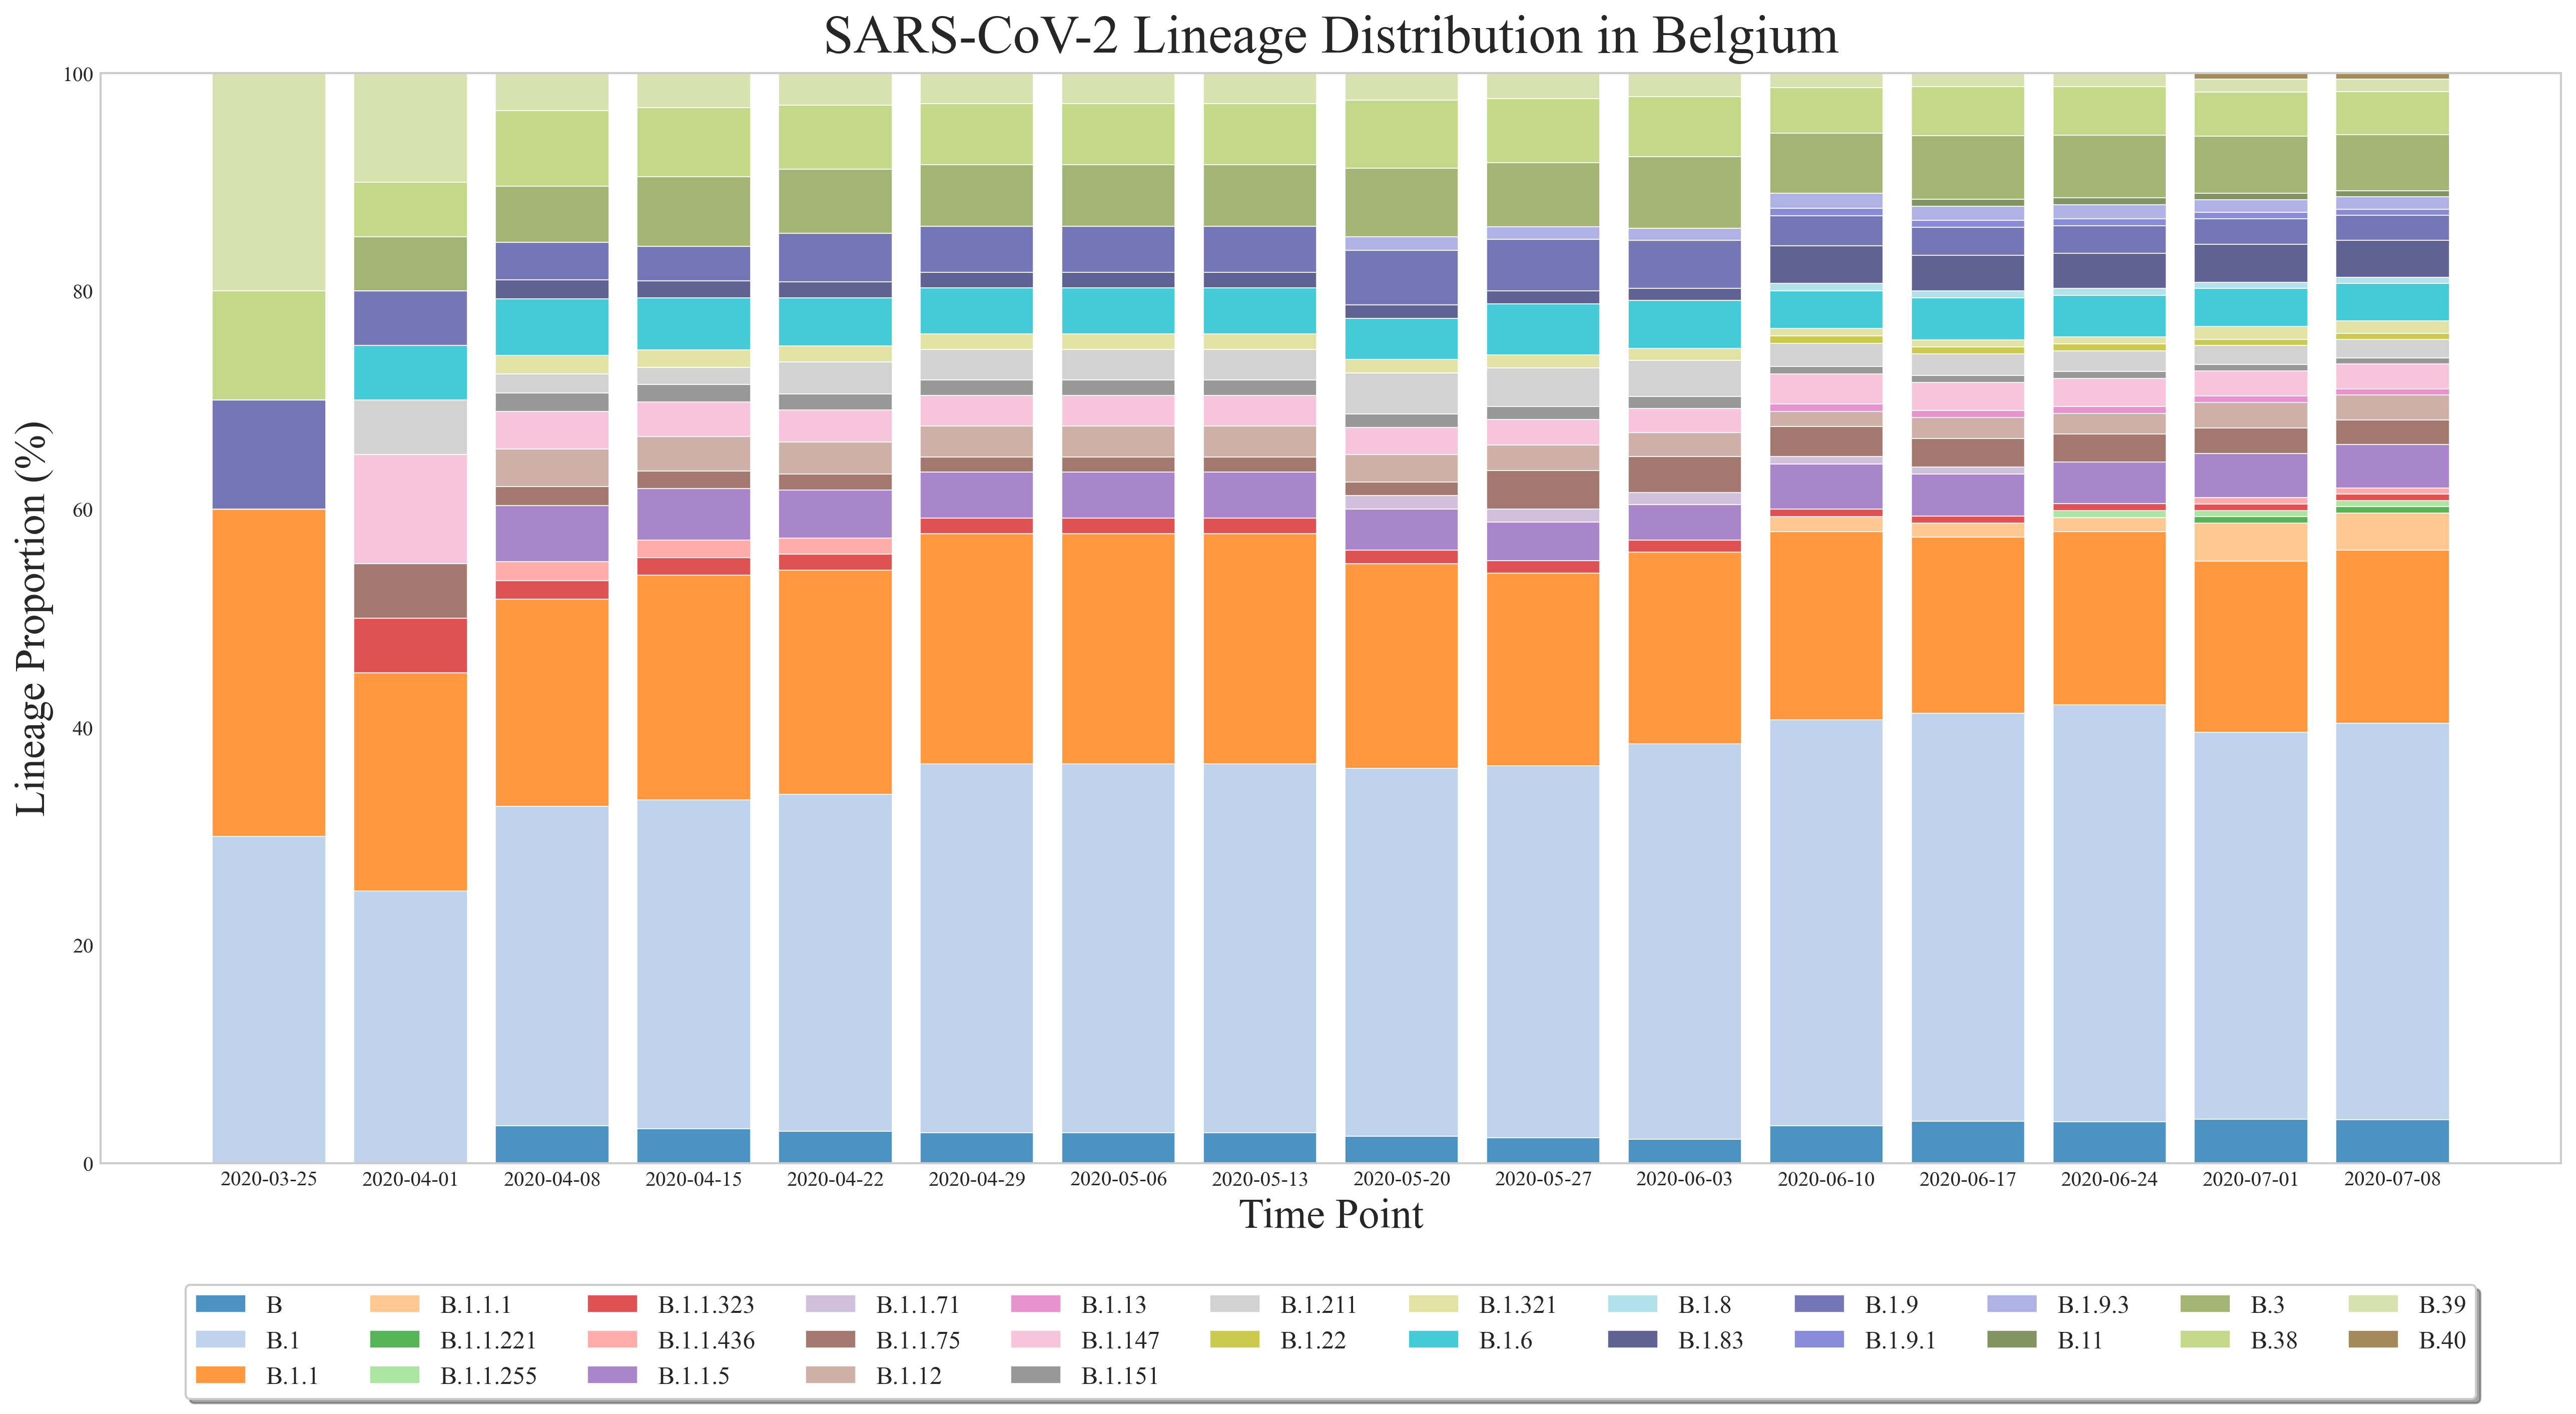

2025-06-05 22:20:45,957 - Analysis completed for 16 time snapshots
2025-06-05 22:20:45,958 - Found 29 unique Lineage categories
2025-06-05 22:20:45,959 - Total samples in 1 regions: 33181


In [70]:
# 假设你已经有了DataFrame列表
# raw_dataframes = [df1, df2, df3, ...]  # 你的DataFrame列表

# 1. 导入库
import sys
if 'TempSnap' in sys.modules:
    del sys.modules['TempSnap']
from TempSnap import TempSnap
import datetime as dt

# 2. 初始化分析器
analyzer = TempSnap(
    output_path="/home/liujiajun/projects/Hap_networks/module/04-15/0605",
    num_processes=2
)


stats_df_multi, plot_path_multi = analyzer.analyze_temporal_distribution(
    category_column='Lineage',    start_date="2020-03-04",
    end_date="2020-07-02",
    graphs_list=graphs,
    location_column='Location',
    location_filter=['Belgium'], 
    font_path='/home/liujiajun/projects/Hap_networks/TIMES.TTF',
    custom_title='SARS-CoV-2 Lineage Distribution in Belgium',
    max_categories=50,
    legend_ncol=12,
    figsize=(18, 12)
)
#['France','Italy','United Kingdom','Germany','Spain','Belgium']


In [48]:
import igraph as ig

def get_node_attributes(graph):
    """获取igraph图的节点属性名称列表"""
    if not isinstance(graph, ig.Graph):
        raise ValueError("输入的对象不是igraph.Graph类型")
    
    return graph.vs.attribute_names()


# 获取并打印节点属性名称
attributes = get_node_attributes(graphs[10])
print("节点属性:", attributes)
# 输出: 节点属性: ['name', 'age', 'type']


节点属性: ['name', 'Date', 'Location', 'ID', 'Ancestor_ID', 'Lineage', 'Ancestor', 'kshell', 'wdks']


In [2]:
import igraph as ig
import multiprocessing
from typing import List, Tuple
from contextlib import closing
import numpy as np

def detect_partition_unweighted(g: ig.Graph, t: int, trials=20) -> Tuple[List[List[str]], Tuple[float, float]]:
    """
    Community detection function using Infomap algorithm
    
    Parameters:
    - g: igraph Graph object
    - t: time index
    - trials: number of attempts for infomap algorithm
    
    Returns:
    - Tuple of (list of communities, (modularity, codelength))
    """
    # Handle empty or small graphs
    if not g or g.vcount() < 2:
        communities = [[v['name'] for v in g.vs]] if g and g.vcount() > 0 else []
        return communities, (0.0, float('nan'))
    
    # Handle empty graph
    if g.ecount() == 0:
        return [[v['name'] for v in g.vs]], (0.0, float('nan'))
    
    try:
        # Use Infomap algorithm for community detection
        infomap_partition = g.community_infomap(trials=trials)
        
        # Try to get code length
        try:
            codelength = infomap_partition.codelength
        except:
            codelength = float('nan')
        
        # Build community list
        communities = []
        for comm in infomap_partition:
            idxs = comm if isinstance(comm, list) else [comm]
            communities.append([g.vs[idx]['name'] for idx in idxs])
        
        # Calculate modularity
        modularity = g.modularity(infomap_partition)
        
        # Print results (保留关键输出)
        print(f"Slice {t}: Communities={len(communities)}, codelength={codelength:.4f}, modularity={modularity:.4f}")
        
        return communities, (modularity, codelength)
        
    except Exception as e:
        # Return the whole graph as a single community on failure
        return [[v['name'] for v in g.vs]], (0.0, float('nan'))

def detect_communities_from_datasets_unweighted(graphs: List[ig.Graph], num_workers: int = 4) -> Tuple[List[List[List[str]]], List[Tuple[float, float]]]:
    """
    Parallel unweighted community detection using Infomap
    
    Parameters:
    - graphs: List of igraph Graph objects
    - num_workers: Number of parallel workers
    
    Returns:
    - Tuple of (list of community partitions, list of (modularity, codelength) tuples)
    """
    if not graphs:
        return [], []

    # Multi-process parallel processing
    with closing(multiprocessing.Pool(processes=num_workers)) as pool:
        parallel_results = pool.starmap(detect_partition_unweighted, 
                             [(g, i) for i, g in enumerate(graphs) if g is not None and g.vcount() > 0])
    
    # Restore empty graph results
    final_results = []
    final_metrics = []
    result_idx = 0
    for i, g in enumerate(graphs):
        if g is not None and g.vcount() > 0:
            communities, metrics = parallel_results[result_idx]
            final_results.append(communities)
            final_metrics.append(metrics)  # 这里metrics是(modularity, codelength)元组
            result_idx += 1
        else:
            final_results.append([])
            final_metrics.append((0.0, float('nan')))
            
    return final_results, final_metrics


# 应用社区检测并获取结果
partitions_none, metrics_none = detect_communities_from_datasets_unweighted(graphs)


Slice 0: Communities=61, codelength=8.5291, modularity=0.7653
Slice 1: Communities=95, codelength=9.2496, modularity=0.7369
Slice 2: Communities=121, codelength=9.7016, modularity=0.7085
Slice 3: Communities=166, codelength=10.2683, modularity=0.6931
Slice 4: Communities=192, codelength=10.4964, modularity=0.6701
Slice 5: Communities=229, codelength=10.8512, modularity=0.6366


Slice 6: Communities=275, codelength=11.1274, modularity=0.7357Slice 7: Communities=363, codelength=11.4573, modularity=0.6742Slice 8: Communities=438, codelength=11.6704, modularity=0.7143
Slice 9: Communities=477, codelength=11.7651, modularity=0.7229
Slice 10: Communities=577, codelength=11.9105, modularity=0.7106
Slice 11: Communities=610, codelength=12.0367, modularity=0.7129
Slice 12: Communities=645, codelength=12.2107, modularity=0.7255
Slice 13: Communities=740, codelength=12.3376, modularity=0.7281

Slice 14: Communities=828, codelength=12.4453, modularity=0.7354Slice 15: Communities=912, codelength=12

In [6]:
IOManager.save_to_hdf5(partitions_none,'/home/liujiajun/projects/Hap_networks/module/Global_dataset/results/Community_structures_no_weights_2020-03-25-2021-03-24.h5',num_threads=8)
IOManager.save_to_hdf5(metrics_none,'/home/liujiajun/projects/Hap_networks/module/Global_dataset/results/Network_metrics_no_weights_2020-03-25-2021-03-24.h5',num_threads=8)


'/home/liujiajun/projects/Hap_networks/module/Global_dataset/results/Network_metrics_no_weights_2020-03-25-2021-03-24.h5'

Skipping LGL layout as graph is disconnected
kamada_kawai layout has 28 crossings
fruchterman_reingold layout has 0 crossings
drl layout has 2 crossings
Selected fruchterman_reingold layout with 0 crossings
Identified 15 key routing nodes
Figure saved to /home/liujiajun/projects/Hap_networks/module/09-25/09-25glob/Backbone Network Snapshot_2020-04-29.svg


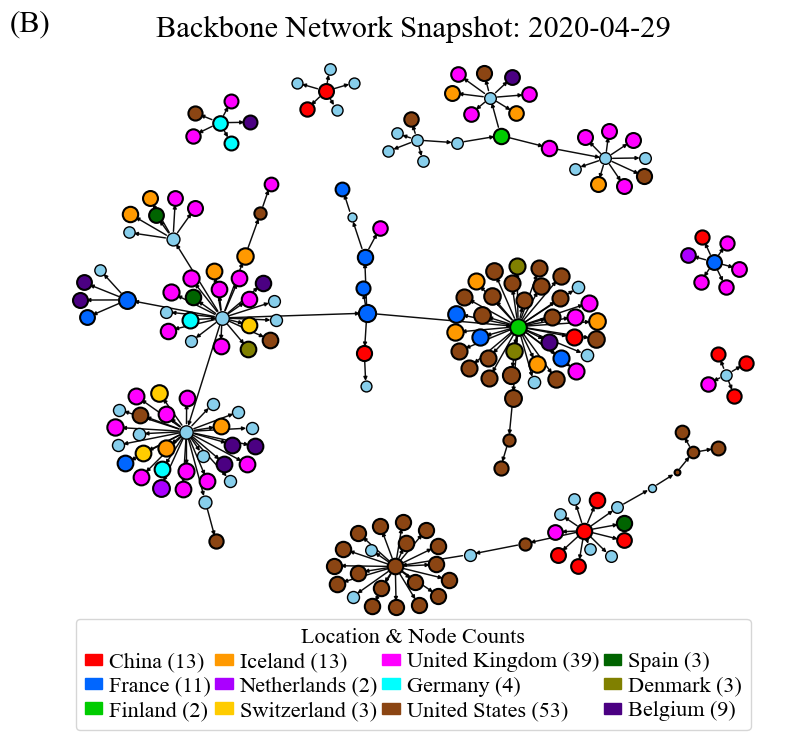

In [50]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import hex2color, rgb2hex
import numpy as np

def visualize_backbone_network(backbone_graph, title="Backbone Network", figsize=(12, 12),
                               font_prop=None, save_path=None, color_attr="Location", 
                               highlight_attrs=None, show_pango_labels=False, other_color="#87CEEB",
                               edge_length_factor=8.0, show_other_nodes=True):
    """
    Visualize backbone network with optimized layout to reduce edge crossings while maintaining straight edges
    
    Parameters:
    -----------
    backbone_graph : igraph Graph
        Input backbone graph to visualize
    title : str
        Title for the plot
    figsize : tuple
        Figure size
    font_prop : FontProperties
        Font properties for text
    save_path : str
        Path to save the figure
    color_attr : str
        Node attribute to use for coloring (default: "Location")
    highlight_attrs : list
        List of attribute values to highlight with special colors (default: None, will highlight all)
    show_pango_labels : bool
        Whether to show Pango lineage labels on key nodes (default: False)
    other_color : str
        Color for non-highlighted nodes (default: "#87CEEB", Sky blue)
    edge_length_factor : float
        Controls the spacing between nodes (default: 8.0)
    show_other_nodes : bool
        Whether to show nodes that don't have highlighted attributes (default: True)
    """
    if backbone_graph is None or backbone_graph.vcount() == 0:
        print("Empty backbone graph, nothing to visualize.")
        return

    # 检查指定的属性是否存在
    if color_attr not in backbone_graph.vs.attributes():
        print(f"Warning: Attribute '{color_attr}' not found in graph. Using default coloring.")
        color_attr = None
        
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)

    # 1. 更强大的布局算法：尝试多种布局方法并选择最佳的一个
    layout_options = []
    
    # 尝试多种布局方法
    try:
        # 方法1: Kamada-Kawai
        inverse_weights = [1 / e['evo_weight'] if e['evo_weight'] != 0 else 1 for e in backbone_graph.es]
        layout1 = backbone_graph.layout_kamada_kawai(
            weights=inverse_weights,
            maxiter=5000,  # 显著增加迭代次数
            epsilon=1e-8   # 更高精度
        )
        layout_options.append(("kamada_kawai", np.array(layout1.coords)))
    except Exception as e:
        print(f"Kamada-Kawai layout failed: {e}")
    
    try:
        # 方法2: Fruchterman-Reingold (修复参数)
        inverse_weights = [1 / e['evo_weight'] if e['evo_weight'] != 0 else 1 for e in backbone_graph.es]
        layout2 = backbone_graph.layout_fruchterman_reingold(
            weights=inverse_weights,
            niter=10000,    # 显著增加迭代次数
            start_temp=2.0  # 移除不支持的coolexp参数
        )
        layout_options.append(("fruchterman_reingold", np.array(layout2.coords)))
    except Exception as e:
        print(f"Fruchterman-Reingold layout failed: {e}")
        
    try:
        # 方法3: Large Graph Layout (只在图是连通的情况下使用)
        # 检查图是否连通
        if backbone_graph.is_connected():
            layout3 = backbone_graph.layout_lgl(
                maxiter=1000,
                maxdelta=1,
                area=backbone_graph.vcount()**2,
                coolexp=1.5,
                repulserad=backbone_graph.vcount()**2
            )
            layout_options.append(("lgl", np.array(layout3.coords)))
        else:
            print("Skipping LGL layout as graph is disconnected")
    except Exception as e:
        print(f"LGL layout failed: {e}")
        
    try:
        # 方法4: DrL layout (VxOrd)
        layout4 = backbone_graph.layout_drl(
            weights=[e['evo_weight'] for e in backbone_graph.es],
            seed=layout_options[0][1] if layout_options else None
        )
        layout_options.append(("drl", np.array(layout4.coords)))
    except Exception as e:
        print(f"DrL layout failed: {e}")
    
    # 如果所有尝试都失败，使用默认布局
    if not layout_options:
        print("All specialized layouts failed, using default layout")
        layout = backbone_graph.layout_auto()
        layout_array = np.array(layout.coords)
    else:
        # 评估每个布局的质量（边交叉数）
        best_layout = None
        min_crossings = float('inf')
        
        for layout_name, layout_coords in layout_options:
            edges = [(e.source, e.target) for e in backbone_graph.es]
            crossings = 0
            
            for i, (src1, tgt1) in enumerate(edges):
                for j, (src2, tgt2) in enumerate(edges[i+1:], i+1):
                    # 跳过共享端点的边
                    if src1 == src2 or src1 == tgt2 or tgt1 == src2 or tgt1 == tgt2:
                        continue
                        
                    # 检查交叉
                    p1 = layout_coords[src1]
                    p2 = layout_coords[tgt1]
                    p3 = layout_coords[src2]
                    p4 = layout_coords[tgt2]
                    
                    def ccw(A, B, C):
                        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                    
                    def intersect(a, b, c, d):
                        return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                    
                    if intersect(p1, p2, p3, p4):
                        crossings += 1
            
            print(f"{layout_name} layout has {crossings} crossings")
            if crossings < min_crossings:
                min_crossings = crossings
                best_layout = (layout_name, layout_coords)
        
        print(f"Selected {best_layout[0]} layout with {min_crossings} crossings")
        layout_array = best_layout[1]
    
    # 2. 扩大布局，让节点有更多空间
    center = np.mean(layout_array, axis=0)
    layout_array = center + (layout_array - center) * edge_length_factor
    
    
    # 3. 集中优化关键节点周围的布局
    edges = [(e.source, e.target) for e in backbone_graph.es]
    
    # 识别连接度高的节点
    node_connections = {}
    for i in range(backbone_graph.vcount()):
        node_connections[i] = 0
    
    for src, tgt in edges:
        node_connections[src] += 1
        node_connections[tgt] += 1
    
    # 识别网络中的关键路由节点（高连接度节点）
    key_routing_nodes = [i for i, count in node_connections.items() if count > 3]
    print(f"Identified {len(key_routing_nodes)} key routing nodes")
    
    # 4. 使用基于模拟退火的优化方法减少交叉
    # 实现改进版的模拟退火优化
    def count_crossings(layout_arr, edge_list):
        """计算布局中的边交叉数"""
        crossings = 0
        for i, (src1, tgt1) in enumerate(edge_list):
            for j, (src2, tgt2) in enumerate(edge_list[i+1:], i+1):
                if src1 == src2 or src1 == tgt2 or tgt1 == src2 or tgt1 == tgt2:
                    continue
                    
                p1 = layout_arr[src1]
                p2 = layout_arr[tgt1]
                p3 = layout_arr[src2]
                p4 = layout_arr[tgt2]
                
                def ccw(A, B, C):
                    return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                
                def intersect(a, b, c, d):
                    return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                
                if intersect(p1, p2, p3, p4):
                    crossings += 1
        return crossings

    # 使用模拟退火优化布局
    import random
    import math
    
    def simulated_annealing_optimization(layout_arr, edge_list, key_nodes, max_iterations=5000):
        """使用模拟退火算法优化布局，减少边交叉"""
        current_layout = layout_arr.copy()
        current_crossings = count_crossings(current_layout, edge_list)
        best_layout = current_layout.copy()
        best_crossings = current_crossings
        
        # 注意这里的坐标范围，用于限制节点位置
        min_coords = np.min(layout_arr, axis=0) - 1
        max_coords = np.max(layout_arr, axis=0) + 1
        
        # 优先级：保持关键节点（高连接度或用户标记为重要的节点）固定
        fixed_nodes = set()
        for i in range(backbone_graph.vcount()):
            if i in key_nodes or backbone_graph.vs[i]['is_key_node']:
                fixed_nodes.add(i)
        
        # 检查是否有可移动的节点
        movable_nodes = [i for i in range(backbone_graph.vcount()) if i not in fixed_nodes]
        if not movable_nodes:
            print("No movable nodes found, skipping simulated annealing")
            return current_layout
        
        # 温度参数
        temperature = 10.0
        cooling_rate = 0.99
        
        print(f"Starting simulated annealing with {current_crossings} crossings")
        progress_interval = max(1, max_iterations // 10)
        
        for iteration in range(max_iterations):
            # 随机选择一个非固定节点
            node_idx = random.choice(movable_nodes)
            
            # 计算该节点参与的边
            involved_edges = [(i, (src, tgt)) for i, (src, tgt) in enumerate(edge_list) 
                             if src == node_idx or tgt == node_idx]
            
            # 如果节点没有相连的边，跳过
            if not involved_edges:
                continue
                
            # 移动前的交叉数
            before_move_crossings = 0
            for edge_idx, _ in involved_edges:
                for j, (src2, tgt2) in enumerate(edge_list):
                    if edge_list[edge_idx][0] == src2 or edge_list[edge_idx][0] == tgt2 or \
                       edge_list[edge_idx][1] == src2 or edge_list[edge_idx][1] == tgt2:
                        continue
                    
                    p1 = current_layout[edge_list[edge_idx][0]]
                    p2 = current_layout[edge_list[edge_idx][1]]
                    p3 = current_layout[src2]
                    p4 = current_layout[tgt2]
                    
                    def ccw(A, B, C):
                        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                    
                    def intersect(a, b, c, d):
                        return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                    
                    if intersect(p1, p2, p3, p4):
                        before_move_crossings += 1
            
            # 保存原始位置
            original_pos = current_layout[node_idx].copy()
            
            # 决定移动方向和距离
            r = (iteration / max_iterations) * 2  # 随着迭代进行，减小移动范围
            move_distance = np.random.normal(0, 0.5 / (1 + r), 2)  # 更精细的移动
            
            # 应用移动
            current_layout[node_idx] += move_distance
            
            # 确保节点位置在合理范围内
            current_layout[node_idx] = np.clip(
                current_layout[node_idx],
                min_coords, 
                max_coords
            )
            
            # 移动后的交叉数
            after_move_crossings = 0
            for edge_idx, _ in involved_edges:
                for j, (src2, tgt2) in enumerate(edge_list):
                    if edge_list[edge_idx][0] == src2 or edge_list[edge_idx][0] == tgt2 or \
                       edge_list[edge_idx][1] == src2 or edge_list[edge_idx][1] == tgt2:
                        continue
                    
                    p1 = current_layout[edge_list[edge_idx][0]]
                    p2 = current_layout[edge_list[edge_idx][1]]
                    p3 = current_layout[src2]
                    p4 = current_layout[tgt2]
                    
                    if intersect(p1, p2, p3, p4):
                        after_move_crossings += 1
            
            # 评估移动
            delta_crossings = after_move_crossings - before_move_crossings
            
            accept_move = False
            if delta_crossings <= 0:  # 更好或相等的解
                accept_move = True
            else:
                # 以一定概率接受更差的解
                probability = math.exp(-delta_crossings / temperature)
                accept_move = random.random() < probability
            
            if not accept_move:
                # 恢复原始位置
                current_layout[node_idx] = original_pos
            else:
                # 更新总交叉数
                current_crossings = current_crossings + delta_crossings
                
                # 更新最佳解
                if current_crossings < best_crossings:
                    best_layout = current_layout.copy()
                    best_crossings = current_crossings
            
            # 降低温度
            temperature *= cooling_rate
            
            # 显示进度
            if iteration % progress_interval == 0:
                print(f"Iteration {iteration}, crossings: {current_crossings}, best: {best_crossings}, temp: {temperature:.6f}")
                
        print(f"Simulated annealing finished. Initial crossings: {count_crossings(layout_arr, edge_list)}, Final best crossings: {best_crossings}")
        return best_layout

    # 如果网络较小，应用模拟退火优化
    if backbone_graph.vcount() <= 100 and len(edges) > 0:  # 确保图至少有一条边
        print("Applying simulated annealing optimization...")
        layout_array = simulated_annealing_optimization(
            layout_array, 
            edges, 
            key_routing_nodes
        )
    
    # 5. 极端情况处理：确保节点不太接近
    min_distance = 0.8 * edge_length_factor
    for i in range(backbone_graph.vcount()):
        for j in range(i+1, backbone_graph.vcount()):
            dist = np.linalg.norm(layout_array[i] - layout_array[j])
            if dist < min_distance:
                # 计算推开方向
                direction = layout_array[i] - layout_array[j]
                if np.linalg.norm(direction) < 1e-10:
                    direction = np.random.uniform(-1, 1, 2)
                direction = direction / np.linalg.norm(direction)
                
                # 根据节点重要性决定如何移动
                if not backbone_graph.vs[i]['is_key_node'] and not backbone_graph.vs[j]['is_key_node']:
                    # 两个都不是关键节点，均等推开
                    layout_array[i] += direction * (min_distance - dist) / 2
                    layout_array[j] -= direction * (min_distance - dist) / 2
                elif not backbone_graph.vs[i]['is_key_node']:
                    # 只移动非关键节点i
                    layout_array[i] += direction * (min_distance - dist)
                elif not backbone_graph.vs[j]['is_key_node']:
                    # 只移动非关键节点j
                    layout_array[j] -= direction * (min_distance - dist)
                else:
                    # 两个都是关键节点，尝试轻微调整
                    layout_array[i] += direction * (min_distance - dist) / 4
                    layout_array[j] -= direction * (min_distance - dist) / 4

    # 创建最终布局对象
    layout = backbone_graph.layout_auto()  # 创建一个与图大小匹配的空布局
    for i in range(backbone_graph.vcount()):
        layout[i] = layout_array[i]
    
    # 节点尺寸计算
    if 'wdks' in backbone_graph.vs.attributes():
        wdks_values = [v['wdks'] for v in backbone_graph.vs]
        min_wdks = min(wdks_values)
        max_wdks = max(wdks_values)
        range_wdks = max_wdks - min_wdks if max_wdks > min_wdks else 1
        node_sizes = [3 + ((v['wdks'] - min_wdks) / range_wdks)**0.05 * 4.5 for v in backbone_graph.vs]
    else:
        node_sizes = [10] * backbone_graph.vcount()

    # 获取用于颜色映射的属性值
    attr_values = []
    if color_attr and color_attr in backbone_graph.vs.attributes():
        for v in backbone_graph.vs:
            if color_attr in v.attributes() and v[color_attr] is not None:
                attr_values.append(str(v[color_attr]))
            else:
                attr_values.append("Unknown")
    else:
        # 如果找不到指定属性，使用默认值
        attr_values = ["Default"] * backbone_graph.vcount()

    # 获取所有唯一属性值
    unique_attr_values = sorted(list(set(attr_values)))
    
    # 如果没有指定要高亮的属性值，默认全部高亮
    if highlight_attrs is None:
        highlight_attrs = unique_attr_values
    
    # 将高亮属性值列表中的所有项转换为字符串，以确保比较一致性
    highlight_attrs = [str(attr) for attr in highlight_attrs]
    
    # 修改颜色定义，使用更强烈的对比色
    high_contrast_colors = [
        '#FF0000',  # 鲜红色
        '#0066FF',  # 亮蓝色
        '#00CC00',  # 亮绿色
        '#FF9900',  # 橙色
        '#AA00FF',  # 紫色
        '#FFCC00',  # 金黄色
        '#FF00FF',  # 洋红色
        '#00FFFF',  # 青色
        '#8B4513',  # 棕色
        '#006400',  # 深绿色
        '#808000',  # 橄榄色 
        '#4B0082',  # 靛青色
        '#008080',  # 蓝绿色
        '#800080',  # 紫色
        '#000000', # 黑色
    ]

    # 创建颜色映射
    color_mapping = {}
    
    # 为每个高亮属性值分配一个独特颜色
    for i, attr in enumerate(highlight_attrs):
        if i < len(high_contrast_colors):
            color_mapping[attr] = high_contrast_colors[i]
        else:
            # 如果高亮值超过了预定义颜色的数量，则生成额外的颜色
            h = (i * 0.618033988749895) % 1.0  # 黄金比例法生成分散的色调
            color = matplotlib.colors.hsv_to_rgb([h, 0.8, 0.9])  # 高饱和度、高亮度
            color_mapping[attr] = matplotlib.colors.rgb2hex(color)
    
    # 为非高亮属性值分配默认颜色
    for attr in unique_attr_values:
        if attr not in color_mapping:
            color_mapping[attr] = other_color

    # 确定每个节点的颜色
    node_colors = []
    for i, v in enumerate(backbone_graph.vs):
        attr = attr_values[i]
        node_colors.append(color_mapping.get(attr, other_color))

    # 不显示Pango标签
    vertex_labels = {}
    if show_pango_labels:  # 只有在show_pango_labels=True时才收集标签信息
        for i, v in enumerate(backbone_graph.vs):
            if v['is_key_node']:
                if 'Pango' in v.attributes() and v['Pango'] is not None:
                    vertex_labels[i] = v['Pango']
    
    # 6. 增强边的可视化 - 使用多种策略区分交叉边
    # 重新计算每条边的交叉情况
    edge_crossings = {}
    for i, (src1, tgt1) in enumerate(edges):
        edge_crossings[i] = []
        for j, (src2, tgt2) in enumerate(edges):
            if i == j:
                continue
                
            p1 = layout_array[src1]
            p2 = layout_array[tgt1]
            p3 = layout_array[src2]
            p4 = layout_array[tgt2]
            
            def ccw(A, B, C):
                return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
            
            def intersect(a, b, c, d):
                # 跳过共享端点的边
                if (np.array_equal(a, c) or np.array_equal(a, d) or 
                    np.array_equal(b, c) or np.array_equal(b, d)):
                    return False
                return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
            
            if intersect(p1, p2, p3, p4):
                edge_crossings[i].append(j)
    
    # 7. 分层绘制策略 - 先绘制交叉较少的边，后绘制交叉较多的边
    # 按交叉次数对边进行排序
    edge_order = sorted(range(len(edges)), key=lambda i: len(edge_crossings.get(i, [])))
    
    # 交错绘制边，确保不同层次的边视觉上可分离

    # 在绘制边之前添加这个函数
    def calculate_node_visual_size(node_idx, base_size, is_highlighted, is_key_node, connection_count):
        """计算节点的实际视觉大小，用于确定边收缩参数"""
        size_boost = 1.0
        
        # 根据高亮状态和关键节点状态调整大小
        if is_highlighted:
            size_boost = 1.4
            if is_key_node or connection_count > 3:
                size_boost = 1.7
        elif is_key_node or connection_count > 3:
            size_boost = 1.3
            
        # 计算最终大小
        return (base_size * size_boost)

    # 然后修改绘制边的代码部分
    # 在分层绘制边的部分替换为以下代码:

    # 交错绘制边，确保不同层次的边视觉上可分离
    for layer, e_idx in enumerate(edge_order):
        src, tgt = edges[e_idx]
        src_coords = layout[src]
        tgt_coords = layout[tgt]
        
        edge_weight = backbone_graph.es[e_idx]['evo_weight']
        
        # 计算交叉数
        crossing_count = len(edge_crossings.get(e_idx, []))
        
        # 根据交叉数调整透明度和线宽
        alpha_base = 0.95 - min(0.45, crossing_count * 0.15)  # 交叉越多越透明，但不低于0.5
        line_width = max(0.15, 1. - crossing_count * 0.5)    # 交叉越多线越细，但不细于0.15
        
        # 计算层级 - 将所有边分成几个层级，用于视觉区分
        layer_alpha_boost = min(0.5, layer / len(edges) * 0.5)  # 层级越高越不透明
        final_alpha = min(0.95, alpha_base + layer_alpha_boost)
        
        # 应用更强的视觉区分
        arrow_style = '-|>'
        arrow_size = 5
        
        # 为交叉较少的边使用更显著的样式
        if crossing_count <= 1:
            line_width *= 1.05  # 加粗
            arrow_size *= 1.05  # 更大箭头
        
        # 为起点和终点计算适合的收缩量
        src_attr = attr_values[src]
        tgt_attr = attr_values[tgt]
        
        # 计算起点和终点节点的视觉大小
        src_size = calculate_node_visual_size(
            src, 
            node_sizes[src], 
            src_attr in highlight_attrs,
            backbone_graph.vs[src]['is_key_node'], 
            node_connections[src]
        )
        
        tgt_size = calculate_node_visual_size(
            tgt, 
            node_sizes[tgt], 
            tgt_attr in highlight_attrs,
            backbone_graph.vs[tgt]['is_key_node'], 
            node_connections[tgt]
        )
        
        # 根据节点大小计算收缩量
        # 基础收缩量 + 节点大小相关的额外收缩量
        shrink_base = 1.8
        shrink_factor = 0.4  # 控制节点大小对收缩量的影响
        
        shrink_a = shrink_base + (src_size * shrink_factor)
        shrink_b = shrink_base + (tgt_size * (shrink_factor-0.15))
        
        # 绘制边
        ax.annotate('',
                    xy=(tgt_coords[0], tgt_coords[1]),
                    xytext=(src_coords[0], src_coords[1]),
                    arrowprops=dict(
                        arrowstyle=arrow_style,
                        linewidth=line_width,
                        color='black',
                        alpha=final_alpha,
                        shrinkA=shrink_a,  # 动态调整的起点收缩量
                        shrinkB=shrink_b,  # 动态调整的终点收缩量
                        mutation_scale=arrow_size,
                        zorder=1 + layer / len(edges)  # 层级越高，zorder越高
                    ),
                    zorder=1 + layer / len(edges))

    # 8. 绘制节点 - 确保节点绘制在所有边之上
    for i, coords in enumerate(layout):
        # 获取当前节点的属性值
        attr = attr_values[i]
        
        # 如果不显示非高亮节点且当前节点不在高亮列表中，则跳过
        if not show_other_nodes and attr not in highlight_attrs:
            continue
        
        # 关键节点或高连接度节点稍大一些
        size_boost = 1.0
        linewidth = 1.0  # 默认边框宽度
        
        # 调整高亮属性节点的显示效果
        if attr in highlight_attrs:
            size_boost = 1.4  # 高亮位置的节点放大
            linewidth = 1.5   # 边框加粗
                
            # 高亮位置的关键节点进一步增大
            if backbone_graph.vs[i]['is_key_node'] or node_connections[i] > 3:
                size_boost = 1.7  # 更大
        elif backbone_graph.vs[i]['is_key_node'] or node_connections[i] > 3:
            size_boost = 1.3  # 非高亮位置的关键节点适度增大
            
        # 使用完全不透明的节点，确保颜色显示鲜明
        ax.scatter(coords[0], coords[1], 
                s=(node_sizes[i] * size_boost) ** 2, 
                c=[node_colors[i]], 
                alpha=1.0,  # 完全不透明
                edgecolors='black', 
                linewidths=linewidth,
                zorder=10)  # 极高的zorder值确保节点始终在最上层
    if show_pango_labels:  # 确保只有在show_pango_labels=True时才会添加标签
        for i, label in vertex_labels.items():
            coords = layout[i]
            plt.text(coords[0], coords[1], label, 
                    fontsize=22, fontproperties=font_prop,
                    ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'),
                    zorder=6)  # 确保标签在最上层
                    
    # 图例部分
    legend_handles = []
    
    # 为高亮属性值创建图例
    for attr in highlight_attrs:
        if attr in color_mapping:
            count = attr_values.count(attr)
            legend_handles.append(mpatches.Patch(
                color=color_mapping[attr],
                label=f"{attr} ({count})"
            ))

    # 为非高亮属性值创建单个"其他"图例项
    # other_count = sum(1 for attr in attr_values if attr not in highlight_attrs)
    # if other_count > 0:
    #     legend_handles.append(mpatches.Patch(
    #         color=other_color,
    #         label=f"Other ({other_count})"
    #     ))

    # 调整图例列数
    if len(legend_handles) <= 5:
        ncols = 2
    elif len(legend_handles) <= 10:
        ncols = 3
    elif len(legend_handles) <= 15:
        ncols = 4
    elif len(legend_handles) <= 20:
        ncols = 5
    else:
        ncols = 6

    legend = ax.legend(handles=legend_handles,
                       loc='upper center',
                       bbox_to_anchor=(0.5, 0.045),
                       ncol=ncols,
                       frameon=True,
                       framealpha=0.8,
                       handlelength=0.8,
                       handleheight=0.4,
                        handletextpad=0.3, 
                       columnspacing=0.2,
                       labelspacing=0.2,
                       title=f"{color_attr} & Node Counts",
                       prop=font_prop,                       
                       fontsize=16)

    plt.setp(legend.get_title(), fontproperties=font_prop, fontsize=16)
    ax.set_title(title, fontproperties=font_prop, fontsize=22,pad=-8000)
    ax.text(-0.05, 1.055, '(B)', transform=ax.transAxes, 
            fontproperties=font_prop, fontsize=22, fontweight='bold',
            horizontalalignment='left', verticalalignment='top')

    ax.axis('off')

    # 隐藏所有坐标轴等
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout(pad=0)  # 减小内边距
    plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.999)  # 更合理的设置

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)
        print(f"Figure saved to {save_path}")

    plt.show()

# 示例使用代码：
import matplotlib.font_manager as font_manager
# 定义字体
font_path = '/home/liujiajun/projects/Hap_networks/TIMES.TTF'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, weight='bold',size=16)

# 使用示例，添加边长控制和其他节点显示控制
visualize_backbone_network(backbone_graphs[5], 
                          title="Backbone Network Snapshot: 2020-04-29", 
                          figsize=(7.48*1, 7.48*0.8),
                          font_prop=prop,
                          save_path="/home/liujiajun/projects/Hap_networks/module/09-25/09-25glob/Backbone Network Snapshot_2020-04-29.svg",
                          color_attr="Location",  # 按地区着色
                          highlight_attrs=['China', 'France', 'Finland', 'Iceland','Netherlands','Switzerland','United Kingdom','Germany','United States',
                                           'Spain','Denmark','Belgium'],  # 高亮这些地区
                          show_pango_labels=False,
                          edge_length_factor=20,  # 增加边长因子以减少拥挤
                          show_other_nodes=True    # 不显示"其他"类别节点
                         )


Skipping LGL layout as graph is disconnected
kamada_kawai layout has 13 crossings
fruchterman_reingold layout has 0 crossings
drl layout has 0 crossings
Selected fruchterman_reingold layout with 0 crossings
Identified 16 key routing nodes
高亮属性值: ['China', 'France', 'Finland', 'Iceland', 'Netherlands', 'Switzerland', 'United Kingdom', 'Germany', 'United States', 'Spain', 'Denmark', 'Belgium']
前5个节点的属性值: ['United States', 'China', 'Luxembourg', 'United Kingdom', 'Iceland']
节点0: 属性=United States, 颜色=#8B4513
节点1: 属性=China, 颜色=#FF0000
节点2: 属性=Luxembourg, 颜色=#87CEEB
节点3: 属性=United Kingdom, 颜色=#FF00FF
节点4: 属性=Iceland, 颜色=#FF9900
Figure saved to 骨干网络快照_2020-04-29.tiff


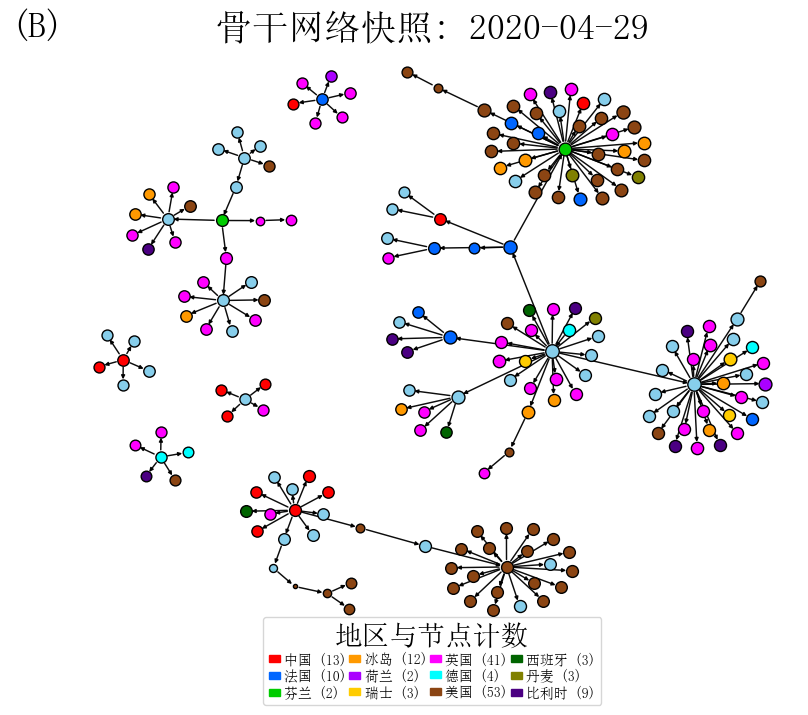

In [ ]:
cfont_path = '/home/liujiajun/projects/Hap_networks/songti.ttf'
font_manager.fontManager.addfont(cfont_path)
cprop = font_manager.FontProperties(fname=cfont_path, weight='bold',size=20)

# 使用示例，添加边长控制和其他节点显示控制
def visualize_backbone_network(backbone_graph, title="Backbone Network", figsize=(12, 12),
                               font_prop=None, save_path=None, color_attr="Location", 
                               highlight_attrs=None, show_pango_labels=False, other_color="#87CEEB",
                               edge_length_factor=8.0, show_other_nodes=True, attr_mapping=None):
    """
    Visualize backbone network with optimized layout to reduce edge crossings while maintaining straight edges
    
    Parameters:
    -----------
    attr_mapping : dict, optional
        映射属性值（如英文位置）到显示值（如中文位置）的字典
    """
    # 函数其余部分保持不变...
        
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)

    # 1. 更强大的布局算法：尝试多种布局方法并选择最佳的一个
    layout_options = []
    
    # 尝试多种布局方法
    try:
        # 方法1: Kamada-Kawai
        inverse_weights = [1 / e['evo_weight'] if e['evo_weight'] != 0 else 1 for e in backbone_graph.es]
        layout1 = backbone_graph.layout_kamada_kawai(
            weights=inverse_weights,
            maxiter=5000,  # 显著增加迭代次数
            epsilon=1e-8   # 更高精度
        )
        layout_options.append(("kamada_kawai", np.array(layout1.coords)))
    except Exception as e:
        print(f"Kamada-Kawai layout failed: {e}")
    
    try:
        # 方法2: Fruchterman-Reingold (修复参数)
        inverse_weights = [1 / e['evo_weight'] if e['evo_weight'] != 0 else 1 for e in backbone_graph.es]
        layout2 = backbone_graph.layout_fruchterman_reingold(
            weights=inverse_weights,
            niter=10000,    # 显著增加迭代次数
            start_temp=2.0  # 移除不支持的coolexp参数
        )
        layout_options.append(("fruchterman_reingold", np.array(layout2.coords)))
    except Exception as e:
        print(f"Fruchterman-Reingold layout failed: {e}")
        
    try:
        # 方法3: Large Graph Layout (只在图是连通的情况下使用)
        # 检查图是否连通
        if backbone_graph.is_connected():
            layout3 = backbone_graph.layout_lgl(
                maxiter=1000,
                maxdelta=1,
                area=backbone_graph.vcount()**2,
                coolexp=1.5,
                repulserad=backbone_graph.vcount()**2
            )
            layout_options.append(("lgl", np.array(layout3.coords)))
        else:
            print("Skipping LGL layout as graph is disconnected")
    except Exception as e:
        print(f"LGL layout failed: {e}")
        
    try:
        # 方法4: DrL layout (VxOrd)
        layout4 = backbone_graph.layout_drl(
            weights=[e['evo_weight'] for e in backbone_graph.es],
            seed=layout_options[0][1] if layout_options else None
        )
        layout_options.append(("drl", np.array(layout4.coords)))
    except Exception as e:
        print(f"DrL layout failed: {e}")
    
    # 如果所有尝试都失败，使用默认布局
    if not layout_options:
        print("All specialized layouts failed, using default layout")
        layout = backbone_graph.layout_auto()
        layout_array = np.array(layout.coords)
    else:
        # 评估每个布局的质量（边交叉数）
        best_layout = None
        min_crossings = float('inf')
        
        for layout_name, layout_coords in layout_options:
            edges = [(e.source, e.target) for e in backbone_graph.es]
            crossings = 0
            
            for i, (src1, tgt1) in enumerate(edges):
                for j, (src2, tgt2) in enumerate(edges[i+1:], i+1):
                    # 跳过共享端点的边
                    if src1 == src2 or src1 == tgt2 or tgt1 == src2 or tgt1 == tgt2:
                        continue
                        
                    # 检查交叉
                    p1 = layout_coords[src1]
                    p2 = layout_coords[tgt1]
                    p3 = layout_coords[src2]
                    p4 = layout_coords[tgt2]
                    
                    def ccw(A, B, C):
                        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                    
                    def intersect(a, b, c, d):
                        return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                    
                    if intersect(p1, p2, p3, p4):
                        crossings += 1
            
            print(f"{layout_name} layout has {crossings} crossings")
            if crossings < min_crossings:
                min_crossings = crossings
                best_layout = (layout_name, layout_coords)
        
        print(f"Selected {best_layout[0]} layout with {min_crossings} crossings")
        layout_array = best_layout[1]
    
    # 2. 扩大布局，让节点有更多空间
    center = np.mean(layout_array, axis=0)
    layout_array = center + (layout_array - center) * edge_length_factor
    
    
    # 3. 集中优化关键节点周围的布局
    edges = [(e.source, e.target) for e in backbone_graph.es]
    
    # 识别连接度高的节点
    node_connections = {}
    for i in range(backbone_graph.vcount()):
        node_connections[i] = 0
    
    for src, tgt in edges:
        node_connections[src] += 1
        node_connections[tgt] += 1
    
    # 识别网络中的关键路由节点（高连接度节点）
    key_routing_nodes = [i for i, count in node_connections.items() if count > 3]
    print(f"Identified {len(key_routing_nodes)} key routing nodes")
    
    # 4. 使用基于模拟退火的优化方法减少交叉
    # 实现改进版的模拟退火优化
    def count_crossings(layout_arr, edge_list):
        """计算布局中的边交叉数"""
        crossings = 0
        for i, (src1, tgt1) in enumerate(edge_list):
            for j, (src2, tgt2) in enumerate(edge_list[i+1:], i+1):
                if src1 == src2 or src1 == tgt2 or tgt1 == src2 or tgt1 == tgt2:
                    continue
                    
                p1 = layout_arr[src1]
                p2 = layout_arr[tgt1]
                p3 = layout_arr[src2]
                p4 = layout_arr[tgt2]
                
                def ccw(A, B, C):
                    return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                
                def intersect(a, b, c, d):
                    return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                
                if intersect(p1, p2, p3, p4):
                    crossings += 1
        return crossings

    # 使用模拟退火优化布局
    import random
    import math
    
    def simulated_annealing_optimization(layout_arr, edge_list, key_nodes, max_iterations=5000):
        """使用模拟退火算法优化布局，减少边交叉"""
        current_layout = layout_arr.copy()
        current_crossings = count_crossings(current_layout, edge_list)
        best_layout = current_layout.copy()
        best_crossings = current_crossings
        
        # 注意这里的坐标范围，用于限制节点位置
        min_coords = np.min(layout_arr, axis=0) - 1
        max_coords = np.max(layout_arr, axis=0) + 1
        
        # 优先级：保持关键节点（高连接度或用户标记为重要的节点）固定
        fixed_nodes = set()
        for i in range(backbone_graph.vcount()):
            if i in key_nodes or backbone_graph.vs[i]['is_key_node']:
                fixed_nodes.add(i)
        
        # 检查是否有可移动的节点
        movable_nodes = [i for i in range(backbone_graph.vcount()) if i not in fixed_nodes]
        if not movable_nodes:
            print("No movable nodes found, skipping simulated annealing")
            return current_layout
        
        # 温度参数
        temperature = 10.0
        cooling_rate = 0.99
        
        print(f"Starting simulated annealing with {current_crossings} crossings")
        progress_interval = max(1, max_iterations // 10)
        
        for iteration in range(max_iterations):
            # 随机选择一个非固定节点
            node_idx = random.choice(movable_nodes)
            
            # 计算该节点参与的边
            involved_edges = [(i, (src, tgt)) for i, (src, tgt) in enumerate(edge_list) 
                             if src == node_idx or tgt == node_idx]
            
            # 如果节点没有相连的边，跳过
            if not involved_edges:
                continue
                
            # 移动前的交叉数
            before_move_crossings = 0
            for edge_idx, _ in involved_edges:
                for j, (src2, tgt2) in enumerate(edge_list):
                    if edge_list[edge_idx][0] == src2 or edge_list[edge_idx][0] == tgt2 or \
                       edge_list[edge_idx][1] == src2 or edge_list[edge_idx][1] == tgt2:
                        continue
                    
                    p1 = current_layout[edge_list[edge_idx][0]]
                    p2 = current_layout[edge_list[edge_idx][1]]
                    p3 = current_layout[src2]
                    p4 = current_layout[tgt2]
                    
                    def ccw(A, B, C):
                        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                    
                    def intersect(a, b, c, d):
                        return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                    
                    if intersect(p1, p2, p3, p4):
                        before_move_crossings += 1
            
            # 保存原始位置
            original_pos = current_layout[node_idx].copy()
            
            # 决定移动方向和距离
            r = (iteration / max_iterations) * 2  # 随着迭代进行，减小移动范围
            move_distance = np.random.normal(0, 0.5 / (1 + r), 2)  # 更精细的移动
            
            # 应用移动
            current_layout[node_idx] += move_distance
            
            # 确保节点位置在合理范围内
            current_layout[node_idx] = np.clip(
                current_layout[node_idx],
                min_coords, 
                max_coords
            )
            
            # 移动后的交叉数
            after_move_crossings = 0
            for edge_idx, _ in involved_edges:
                for j, (src2, tgt2) in enumerate(edge_list):
                    if edge_list[edge_idx][0] == src2 or edge_list[edge_idx][0] == tgt2 or \
                       edge_list[edge_idx][1] == src2 or edge_list[edge_idx][1] == tgt2:
                        continue
                    
                    p1 = current_layout[edge_list[edge_idx][0]]
                    p2 = current_layout[edge_list[edge_idx][1]]
                    p3 = current_layout[src2]
                    p4 = current_layout[tgt2]
                    
                    if intersect(p1, p2, p3, p4):
                        after_move_crossings += 1
            
            # 评估移动
            delta_crossings = after_move_crossings - before_move_crossings
            
            accept_move = False
            if delta_crossings <= 0:  # 更好或相等的解
                accept_move = True
            else:
                # 以一定概率接受更差的解
                probability = math.exp(-delta_crossings / temperature)
                accept_move = random.random() < probability
            
            if not accept_move:
                # 恢复原始位置
                current_layout[node_idx] = original_pos
            else:
                # 更新总交叉数
                current_crossings = current_crossings + delta_crossings
                
                # 更新最佳解
                if current_crossings < best_crossings:
                    best_layout = current_layout.copy()
                    best_crossings = current_crossings
            
            # 降低温度
            temperature *= cooling_rate
            
            # 显示进度
            if iteration % progress_interval == 0:
                print(f"Iteration {iteration}, crossings: {current_crossings}, best: {best_crossings}, temp: {temperature:.6f}")
                
        print(f"Simulated annealing finished. Initial crossings: {count_crossings(layout_arr, edge_list)}, Final best crossings: {best_crossings}")
        return best_layout

    # 如果网络较小，应用模拟退火优化
    if backbone_graph.vcount() <= 100 and len(edges) > 0:  # 确保图至少有一条边
        print("Applying simulated annealing optimization...")
        layout_array = simulated_annealing_optimization(
            layout_array, 
            edges, 
            key_routing_nodes
        )
    
    # 5. 极端情况处理：确保节点不太接近
    min_distance = 0.8 * edge_length_factor
    for i in range(backbone_graph.vcount()):
        for j in range(i+1, backbone_graph.vcount()):
            dist = np.linalg.norm(layout_array[i] - layout_array[j])
            if dist < min_distance:
                # 计算推开方向
                direction = layout_array[i] - layout_array[j]
                if np.linalg.norm(direction) < 1e-10:
                    direction = np.random.uniform(-1, 1, 2)
                direction = direction / np.linalg.norm(direction)
                
                # 根据节点重要性决定如何移动
                if not backbone_graph.vs[i]['is_key_node'] and not backbone_graph.vs[j]['is_key_node']:
                    # 两个都不是关键节点，均等推开
                    layout_array[i] += direction * (min_distance - dist) / 2
                    layout_array[j] -= direction * (min_distance - dist) / 2
                elif not backbone_graph.vs[i]['is_key_node']:
                    # 只移动非关键节点i
                    layout_array[i] += direction * (min_distance - dist)
                elif not backbone_graph.vs[j]['is_key_node']:
                    # 只移动非关键节点j
                    layout_array[j] -= direction * (min_distance - dist)
                else:
                    # 两个都是关键节点，尝试轻微调整
                    layout_array[i] += direction * (min_distance - dist) / 4
                    layout_array[j] -= direction * (min_distance - dist) / 4

    # 创建最终布局对象
    layout = backbone_graph.layout_auto()  # 创建一个与图大小匹配的空布局
    for i in range(backbone_graph.vcount()):
        layout[i] = layout_array[i]
    
    # 节点尺寸计算
    if 'wdks' in backbone_graph.vs.attributes():
        wdks_values = [v['wdks'] for v in backbone_graph.vs]
        min_wdks = min(wdks_values)
        max_wdks = max(wdks_values)
        range_wdks = max_wdks - min_wdks if max_wdks > min_wdks else 1
        node_sizes = [3 + ((v['wdks'] - min_wdks) / range_wdks)**0.05 * 4.5 for v in backbone_graph.vs]
    else:
        node_sizes = [10] * backbone_graph.vcount()

    # 获取用于颜色映射的属性值
    # 获取用于颜色映射的属性值
    attr_values = []
    original_attr_values = []  # 存储原始属性值
    if color_attr and color_attr in backbone_graph.vs.attributes():
        for v in backbone_graph.vs:
            if color_attr in v.attributes() and v[color_attr] is not None:
                orig_value = str(v[color_attr])
                original_attr_values.append(orig_value)
                # 如果提供了映射，则使用映射后的值作为显示值，但保留原始值用于匹配
                if attr_mapping and orig_value in attr_mapping:
                    attr_values.append(attr_mapping[orig_value])  # 用于显示
                else:
                    attr_values.append(orig_value)
            else:
                original_attr_values.append("Unknown")
                attr_values.append("Unknown")
    else:
        # 如果找不到指定属性，使用默认值
        attr_values = ["Default"] * backbone_graph.vcount()
        original_attr_values = ["Default"] * backbone_graph.vcount()

    # 获取所有唯一属性值
    unique_attr_values = sorted(list(set(attr_values)))
    
    # 如果没有指定要高亮的属性值，默认全部高亮
    if highlight_attrs is None:
        highlight_attrs = unique_attr_values
    
    # 将高亮属性值列表中的所有项转换为字符串，以确保比较一致性
    highlight_attrs = [str(attr) for attr in highlight_attrs]
    print(f"高亮属性值: {highlight_attrs}")
    print(f"前5个节点的属性值: {original_attr_values[:5]}")  # 查看实际节点属性
    # 修改颜色定义，使用更强烈的对比色
    high_contrast_colors = [
        '#FF0000',  # 鲜红色
        '#0066FF',  # 亮蓝色
        '#00CC00',  # 亮绿色
        '#FF9900',  # 橙色
        '#AA00FF',  # 紫色
        '#FFCC00',  # 金黄色
        '#FF00FF',  # 洋红色
        '#00FFFF',  # 青色
        '#8B4513',  # 棕色
        '#006400',  # 深绿色
        '#808000',  # 橄榄色 
        '#4B0082',  # 靛青色
        '#008080',  # 蓝绿色
        '#800080',  # 紫色
        '#000000', # 黑色
    ]

    # 创建颜色映射
    color_mapping = {}
    
    # 为每个高亮属性值分配一个独特颜色
    for i, attr in enumerate(highlight_attrs):
        if i < len(high_contrast_colors):
            color_mapping[attr] = high_contrast_colors[i]
        else:
            # 如果高亮值超过了预定义颜色的数量，则生成额外的颜色
            h = (i * 0.618033988749895) % 1.0  # 黄金比例法生成分散的色调
            color = matplotlib.colors.hsv_to_rgb([h, 0.8, 0.9])  # 高饱和度、高亮度
            color_mapping[attr] = matplotlib.colors.rgb2hex(color)
    
    # 为非高亮属性值分配默认颜色
    for attr in unique_attr_values:
        if attr not in color_mapping:
            color_mapping[attr] = other_color

    # 确定每个节点的颜色
    # 确定每个节点的颜色 - 这里使用original_attr_values而不是attr_values
    node_colors = []
    for i, v in enumerate(backbone_graph.vs):
        attr = original_attr_values[i]  # 使用原始属性值（英文）来匹配颜色
        
        # 调试信息
        if i < 5:
            print(f"节点{i}: 属性={attr}, 颜色={color_mapping.get(attr, other_color)}")
            
        node_colors.append(color_mapping.get(attr, other_color))

    # 不显示Pango标签
    vertex_labels = {}
    if show_pango_labels:  # 只有在show_pango_labels=True时才收集标签信息
        for i, v in enumerate(backbone_graph.vs):
            if v['is_key_node']:
                if 'Pango' in v.attributes() and v['Pango'] is not None:
                    vertex_labels[i] = v['Pango']
    
    # 6. 增强边的可视化 - 使用多种策略区分交叉边
    # 重新计算每条边的交叉情况
    edge_crossings = {}
    for i, (src1, tgt1) in enumerate(edges):
        edge_crossings[i] = []
        for j, (src2, tgt2) in enumerate(edges):
            if i == j:
                continue
                
            p1 = layout_array[src1]
            p2 = layout_array[tgt1]
            p3 = layout_array[src2]
            p4 = layout_array[tgt2]
            
            def ccw(A, B, C):
                return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
            
            def intersect(a, b, c, d):
                # 跳过共享端点的边
                if (np.array_equal(a, c) or np.array_equal(a, d) or 
                    np.array_equal(b, c) or np.array_equal(b, d)):
                    return False
                return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
            
            if intersect(p1, p2, p3, p4):
                edge_crossings[i].append(j)
    
    # 7. 分层绘制策略 - 先绘制交叉较少的边，后绘制交叉较多的边
    # 按交叉次数对边进行排序
    edge_order = sorted(range(len(edges)), key=lambda i: len(edge_crossings.get(i, [])))
    
    # 交错绘制边，确保不同层次的边视觉上可分离

    # 在绘制边之前添加这个函数
    def calculate_node_visual_size(node_idx, base_size, is_highlighted, is_key_node, connection_count):
        """计算节点的实际视觉大小，用于确定边收缩参数"""
        size_boost = 1.0
        
        # 根据高亮状态和关键节点状态调整大小
        if is_highlighted:
            size_boost = 1.4
            if is_key_node or connection_count > 3:
                size_boost = 1.7
        elif is_key_node or connection_count > 3:
            size_boost = 1.3
            
        # 计算最终大小
        return (base_size * size_boost)

    # 交错绘制边，确保不同层次的边视觉上可分离
    for layer, e_idx in enumerate(edge_order):
        src, tgt = edges[e_idx]
        src_coords = layout[src]
        tgt_coords = layout[tgt]
        
        edge_weight = backbone_graph.es[e_idx]['evo_weight']
        
        # 计算交叉数
        crossing_count = len(edge_crossings.get(e_idx, []))
        
        # 根据交叉数调整透明度和线宽
        alpha_base = 0.95 - min(0.45, crossing_count * 0.15)  # 交叉越多越透明，但不低于0.5
        line_width = max(0.15, 1. - crossing_count * 0.5)    # 交叉越多线越细，但不细于0.15
        
        # 计算层级 - 将所有边分成几个层级，用于视觉区分
        layer_alpha_boost = min(0.5, layer / len(edges) * 0.5)  # 层级越高越不透明
        final_alpha = min(0.95, alpha_base + layer_alpha_boost)
        
        # 应用更强的视觉区分
        arrow_style = '-|>'
        arrow_size = 5
        
        # 为交叉较少的边使用更显著的样式
        if crossing_count <= 1:
            line_width *= 1.05  # 加粗
            arrow_size *= 1.05  # 更大箭头
        
        # 为起点和终点计算适合的收缩量
        src_attr = attr_values[src]
        tgt_attr = attr_values[tgt]
        
        # 计算起点和终点节点的视觉大小
        src_size = calculate_node_visual_size(
            src, 
            node_sizes[src], 
            src_attr in highlight_attrs,
            backbone_graph.vs[src]['is_key_node'], 
            node_connections[src]
        )
        
        tgt_size = calculate_node_visual_size(
            tgt, 
            node_sizes[tgt], 
            tgt_attr in highlight_attrs,
            backbone_graph.vs[tgt]['is_key_node'], 
            node_connections[tgt]
        )
        
        # 根据节点大小计算收缩量
        # 基础收缩量 + 节点大小相关的额外收缩量
        shrink_base = 1.95
        shrink_factor = 0.4  # 控制节点大小对收缩量的影响
        
        shrink_a = shrink_base + (src_size * shrink_factor)
        shrink_b = shrink_base + (tgt_size * (shrink_factor-0.15))
        
        # 绘制边
        ax.annotate('',
                    xy=(tgt_coords[0], tgt_coords[1]),
                    xytext=(src_coords[0], src_coords[1]),
                    arrowprops=dict(
                        arrowstyle=arrow_style,
                        linewidth=line_width,
                        color='black',
                        alpha=final_alpha,
                        shrinkA=shrink_a,  # 动态调整的起点收缩量
                        shrinkB=shrink_b,  # 动态调整的终点收缩量
                        mutation_scale=arrow_size,
                        zorder=1 + layer / len(edges)  # 层级越高，zorder越高
                    ),
                    zorder=1 + layer / len(edges))

    # 8. 绘制节点 - 确保节点绘制在所有边之上
    for i, coords in enumerate(layout):
        # 获取当前节点的属性值
        attr = attr_values[i]
        
        # 如果不显示非高亮节点且当前节点不在高亮列表中，则跳过
        if not show_other_nodes and attr not in highlight_attrs:
            continue
        
        # 关键节点或高连接度节点稍大一些
        size_boost = 1.0
        linewidth = 1.0  # 默认边框宽度
        
        # 调整高亮属性节点的显示效果
        if attr in highlight_attrs:
            size_boost = 1.4  # 高亮位置的节点放大
            linewidth = 1.5   # 边框加粗
                
            # 高亮位置的关键节点进一步增大
            if backbone_graph.vs[i]['is_key_node'] or node_connections[i] > 3:
                size_boost = 1.7  # 更大
        elif backbone_graph.vs[i]['is_key_node'] or node_connections[i] > 3:
            size_boost = 1.3  # 非高亮位置的关键节点适度增大
            
        # 使用完全不透明的节点，确保颜色显示鲜明
        ax.scatter(coords[0], coords[1], 
                s=(node_sizes[i] * size_boost) ** 2, 
                c=[node_colors[i]], 
                alpha=1.0,  # 完全不透明
                edgecolors='black', 
                linewidths=linewidth,
                zorder=10)  # 极高的zorder值确保节点始终在最上层
    if show_pango_labels:  # 确保只有在show_pango_labels=True时才会添加标签
        for i, label in vertex_labels.items():
            coords = layout[i]
            plt.text(coords[0], coords[1], label, 
                    fontsize=9, fontproperties=font_prop,
                    ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'),
                    zorder=6)  # 确保标签在最上层
                    
    # 图例部分
    legend_handles = []
    
    # 为高亮属性值创建图例
    # 为高亮属性值创建图例
    for attr_idx, attr in enumerate(highlight_attrs):  # 原始的英文属性值
        if attr in color_mapping:
            # 计算匹配此属性的原始属性值的数量
            count = original_attr_values.count(attr)
            
            # 如果提供了映射，在图例中使用中文显示
            display_attr = attr
            if attr_mapping and attr in attr_mapping:
                display_attr = attr_mapping[attr]
                
            legend_handles.append(mpatches.Patch(
                color=color_mapping[attr],
                label=f"{display_attr} ({count})"  # 使用中文显示，但颜色匹配用英文
            ))

    # 为非高亮属性值创建单个"其他"图例项
    # other_count = sum(1 for attr in attr_values if attr not in highlight_attrs)
    # if other_count > 0:
    #     legend_handles.append(mpatches.Patch(
    #         color=other_color,
    #         label=f"Other ({other_count})"
    #     ))

    # 调整图例列数
    if len(legend_handles) <= 5:
        ncols = 2
    elif len(legend_handles) <= 10:
        ncols = 3
    elif len(legend_handles) <= 15:
        ncols = 4
    elif len(legend_handles) <= 20:
        ncols = 5
    else:
        ncols = 6

    legend = ax.legend(handles=legend_handles,
                       loc='upper center',
                       bbox_to_anchor=(0.5, 0.045),
                       ncol=ncols,
                       frameon=True,
                       framealpha=0.8,
                       handlelength=0.8,
                       handleheight=0.4,
                       handletextpad=0.3, 
                       columnspacing=0.2,
                       labelspacing=0.2,
                       title=f"地区与节点计数",
                       prop=chinese_font_prop,                       
                       fontsize=20)


    plt.setp(legend.get_title(), fontproperties=chinese_font_prop, fontsize=20)
    ax.set_title(title, fontproperties=chinese_font_prop, fontsize=26,pad=-8000)
    ax.text(-0.076, 1.06, '(B)', transform=ax.transAxes, 
            fontproperties=font_prop, fontsize=26, fontweight='bold',
            horizontalalignment='left', verticalalignment='top')

    ax.axis('off')

    # 隐藏所有坐标轴等
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout(pad=0)  # 减小内边距
    plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.999)  # 更合理的设置
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)
        print(f"Figure saved to {save_path}")

    plt.show()


# 地区名称的英中对照
location_map = {
    'China': '中国', 
    'France': '法国', 
    'Finland': '芬兰', 
    'Iceland': '冰岛',
    'Netherlands': '荷兰',
    'Switzerland': '瑞士',
    'United Kingdom': '英国',
    'Germany': '德国',
    'United States': '美国',
    'Spain': '西班牙',
    'Denmark': '丹麦',
    'Belgium': '比利时'
}

# 调用可视化函数时，分别传入英文地区名和中文地区名
# 调用可视化函数时，使用英文地区名
visualize_backbone_network(backbone_graphs[5], 
                          title="骨干网络快照: 2020-04-29", 
                          figsize=(7.48*1, 7.48*0.8),
                          font_prop=chinese_font_prop,  # 确保这个变量已定义
                          save_path="骨干网络快照_2020-04-29.tiff",
                          color_attr="Location",  
                          highlight_attrs=['China', 'France', 'Finland', 'Iceland','Netherlands',
                                          'Switzerland','United Kingdom','Germany','United States',
                                          'Spain','Denmark','Belgium'],  # 使用英文原始属性
                          show_pango_labels=False,
                          edge_length_factor=20,
                          show_other_nodes=True,
                          attr_mapping=location_map  # 传入映射字典
                         )


Skipping LGL layout as graph is disconnected
kamada_kawai layout has 0 crossings
fruchterman_reingold layout has 0 crossings
drl layout has 0 crossings
Selected kamada_kawai layout with 0 crossings
Identified 5 key routing nodes
Applying simulated annealing optimization...
Starting simulated annealing with 0 crossings
Iteration 0, crossings: 0, best: 0, temp: 9.900000
Iteration 500, crossings: 0, best: 0, temp: 0.065048
Iteration 1000, crossings: 0, best: 0, temp: 0.000427
Iteration 1500, crossings: 0, best: 0, temp: 0.000003
Iteration 2000, crossings: 0, best: 0, temp: 0.000000
Iteration 2500, crossings: 0, best: 0, temp: 0.000000
Iteration 3000, crossings: 0, best: 0, temp: 0.000000
Iteration 3500, crossings: 0, best: 0, temp: 0.000000
Iteration 4000, crossings: 0, best: 0, temp: 0.000000
Iteration 4500, crossings: 0, best: 0, temp: 0.000000
Simulated annealing finished. Initial crossings: 0, Final best crossings: 0
高亮属性值: ['China', 'France', 'Finland', 'Iceland', 'Netherlands', 'Swi

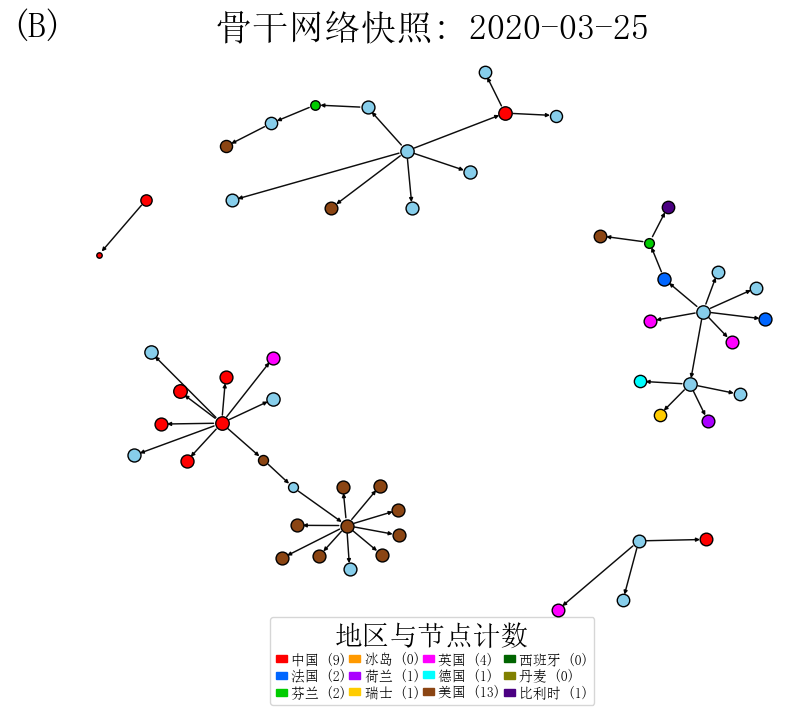

In [ ]:
visualize_backbone_network(backbone_graphs[0], 
                          title="骨干网络快照: 2020-03-25", 
                          figsize=(7.48*1, 7.48*0.8),
                          font_prop=chinese_font_prop,  # 确保这个变量已定义
                          save_path="骨干网络快照_2020-03-25.tiff",
                          color_attr="Location",  
                          highlight_attrs=['China', 'France', 'Finland', 'Iceland','Netherlands',
                                          'Switzerland','United Kingdom','Germany','United States',
                                          'Spain','Denmark','Belgium'],  # 使用英文原始属性
                          show_pango_labels=False,
                          edge_length_factor=20,
                          show_other_nodes=True,
                          attr_mapping=location_map  # 传入映射字典
                         )


Skipping LGL layout as graph is disconnected
kamada_kawai layout has 0 crossings
fruchterman_reingold layout has 0 crossings
drl layout has 0 crossings
Selected kamada_kawai layout with 0 crossings
Identified 5 key routing nodes
Applying simulated annealing optimization...
Starting simulated annealing with 0 crossings
Iteration 0, crossings: 0, best: 0, temp: 9.900000
Iteration 500, crossings: 0, best: 0, temp: 0.065048
Iteration 1000, crossings: 0, best: 0, temp: 0.000427
Iteration 1500, crossings: 0, best: 0, temp: 0.000003
Iteration 2000, crossings: 0, best: 0, temp: 0.000000
Iteration 2500, crossings: 0, best: 0, temp: 0.000000
Iteration 3000, crossings: 0, best: 0, temp: 0.000000
Iteration 3500, crossings: 0, best: 0, temp: 0.000000
Iteration 4000, crossings: 0, best: 0, temp: 0.000000
Iteration 4500, crossings: 0, best: 0, temp: 0.000000
Simulated annealing finished. Initial crossings: 0, Final best crossings: 0
Figure saved to Backbone Network Snapshot_2020-03-25.svg


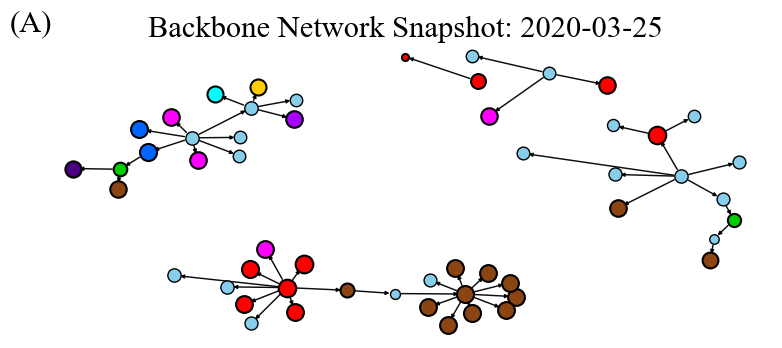

In [48]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import patheffects
from matplotlib.colors import hex2color, rgb2hex
import numpy as np
import colorsys
def visualize_backbone_network(backbone_graph, title="Backbone Network", figsize=(12, 12),
                               font_prop=None, save_path=None, color_attr="Location", 
                               highlight_attrs=None, show_pango_labels=False, other_color="#87CEEB",
                               edge_length_factor=8.0, show_other_nodes=True):
    """
    Visualize backbone network with optimized layout to reduce edge crossings while maintaining straight edges
    
    Parameters:
    -----------
    backbone_graph : igraph Graph
        Input backbone graph to visualize
    title : str
        Title for the plot
    figsize : tuple
        Figure size
    font_prop : FontProperties
        Font properties for text
    save_path : str
        Path to save the figure
    color_attr : str
        Node attribute to use for coloring (default: "Location")
    highlight_attrs : list
        List of attribute values to highlight with special colors (default: None, will highlight all)
    show_pango_labels : bool
        Whether to show Pango lineage labels on key nodes (default: False)
    other_color : str
        Color for non-highlighted nodes (default: "#87CEEB", Sky blue)
    edge_length_factor : float
        Controls the spacing between nodes (default: 8.0)
    show_other_nodes : bool
        Whether to show nodes that don't have highlighted attributes (default: True)
    """
    if backbone_graph is None or backbone_graph.vcount() == 0:
        print("Empty backbone graph, nothing to visualize.")
        return

    # 检查指定的属性是否存在
    if color_attr not in backbone_graph.vs.attributes():
        print(f"Warning: Attribute '{color_attr}' not found in graph. Using default coloring.")
        color_attr = None
        
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)

    # 1. 更强大的布局算法：尝试多种布局方法并选择最佳的一个
    layout_options = []
    
    # 尝试多种布局方法
    try:
        # 方法1: Kamada-Kawai
        inverse_weights = [1 / e['evo_weight'] if e['evo_weight'] != 0 else 1 for e in backbone_graph.es]
        layout1 = backbone_graph.layout_kamada_kawai(
            weights=inverse_weights,
            maxiter=5000,  # 显著增加迭代次数
            epsilon=1e-8   # 更高精度
        )
        layout_options.append(("kamada_kawai", np.array(layout1.coords)))
    except Exception as e:
        print(f"Kamada-Kawai layout failed: {e}")
    
    try:
        # 方法2: Fruchterman-Reingold (修复参数)
        inverse_weights = [1 / e['evo_weight'] if e['evo_weight'] != 0 else 1 for e in backbone_graph.es]
        layout2 = backbone_graph.layout_fruchterman_reingold(
            weights=inverse_weights,
            niter=10000,    # 显著增加迭代次数
            start_temp=2.0  # 移除不支持的coolexp参数
        )
        layout_options.append(("fruchterman_reingold", np.array(layout2.coords)))
    except Exception as e:
        print(f"Fruchterman-Reingold layout failed: {e}")
        
    try:
        # 方法3: Large Graph Layout (只在图是连通的情况下使用)
        # 检查图是否连通
        if backbone_graph.is_connected():
            layout3 = backbone_graph.layout_lgl(
                maxiter=1000,
                maxdelta=1,
                area=backbone_graph.vcount()**2,
                coolexp=1.5,
                repulserad=backbone_graph.vcount()**2
            )
            layout_options.append(("lgl", np.array(layout3.coords)))
        else:
            print("Skipping LGL layout as graph is disconnected")
    except Exception as e:
        print(f"LGL layout failed: {e}")
        
    try:
        # 方法4: DrL layout (VxOrd)
        layout4 = backbone_graph.layout_drl(
            weights=[e['evo_weight'] for e in backbone_graph.es],
            seed=layout_options[0][1] if layout_options else None
        )
        layout_options.append(("drl", np.array(layout4.coords)))
    except Exception as e:
        print(f"DrL layout failed: {e}")
    
    # 如果所有尝试都失败，使用默认布局
    if not layout_options:
        print("All specialized layouts failed, using default layout")
        layout = backbone_graph.layout_auto()
        layout_array = np.array(layout.coords)
    else:
        # 评估每个布局的质量（边交叉数）
        best_layout = None
        min_crossings = float('inf')
        
        for layout_name, layout_coords in layout_options:
            edges = [(e.source, e.target) for e in backbone_graph.es]
            crossings = 0
            
            for i, (src1, tgt1) in enumerate(edges):
                for j, (src2, tgt2) in enumerate(edges[i+1:], i+1):
                    # 跳过共享端点的边
                    if src1 == src2 or src1 == tgt2 or tgt1 == src2 or tgt1 == tgt2:
                        continue
                        
                    # 检查交叉
                    p1 = layout_coords[src1]
                    p2 = layout_coords[tgt1]
                    p3 = layout_coords[src2]
                    p4 = layout_coords[tgt2]
                    
                    def ccw(A, B, C):
                        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                    
                    def intersect(a, b, c, d):
                        return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                    
                    if intersect(p1, p2, p3, p4):
                        crossings += 1
            
            print(f"{layout_name} layout has {crossings} crossings")
            if crossings < min_crossings:
                min_crossings = crossings
                best_layout = (layout_name, layout_coords)
        
        print(f"Selected {best_layout[0]} layout with {min_crossings} crossings")
        layout_array = best_layout[1]
    
    # 2. 扩大布局，让节点有更多空间
    center = np.mean(layout_array, axis=0)
    layout_array = center + (layout_array - center) * edge_length_factor
    
    
    # 3. 集中优化关键节点周围的布局
    edges = [(e.source, e.target) for e in backbone_graph.es]
    
    # 识别连接度高的节点
    node_connections = {}
    for i in range(backbone_graph.vcount()):
        node_connections[i] = 0
    
    for src, tgt in edges:
        node_connections[src] += 1
        node_connections[tgt] += 1
    
    # 识别网络中的关键路由节点（高连接度节点）
    key_routing_nodes = [i for i, count in node_connections.items() if count > 3]
    print(f"Identified {len(key_routing_nodes)} key routing nodes")
    
    # 4. 使用基于模拟退火的优化方法减少交叉
    # 实现改进版的模拟退火优化
    def count_crossings(layout_arr, edge_list):
        """计算布局中的边交叉数"""
        crossings = 0
        for i, (src1, tgt1) in enumerate(edge_list):
            for j, (src2, tgt2) in enumerate(edge_list[i+1:], i+1):
                if src1 == src2 or src1 == tgt2 or tgt1 == src2 or tgt1 == tgt2:
                    continue
                    
                p1 = layout_arr[src1]
                p2 = layout_arr[tgt1]
                p3 = layout_arr[src2]
                p4 = layout_arr[tgt2]
                
                def ccw(A, B, C):
                    return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                
                def intersect(a, b, c, d):
                    return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                
                if intersect(p1, p2, p3, p4):
                    crossings += 1
        return crossings

    # 使用模拟退火优化布局
    import random
    import math
    
    def simulated_annealing_optimization(layout_arr, edge_list, key_nodes, max_iterations=5000):
        """使用模拟退火算法优化布局，减少边交叉"""
        current_layout = layout_arr.copy()
        current_crossings = count_crossings(current_layout, edge_list)
        best_layout = current_layout.copy()
        best_crossings = current_crossings
        
        # 注意这里的坐标范围，用于限制节点位置
        min_coords = np.min(layout_arr, axis=0) - 1
        max_coords = np.max(layout_arr, axis=0) + 1
        
        # 优先级：保持关键节点（高连接度或用户标记为重要的节点）固定
        fixed_nodes = set()
        for i in range(backbone_graph.vcount()):
            if i in key_nodes or backbone_graph.vs[i]['is_key_node']:
                fixed_nodes.add(i)
        
        # 检查是否有可移动的节点
        movable_nodes = [i for i in range(backbone_graph.vcount()) if i not in fixed_nodes]
        if not movable_nodes:
            print("No movable nodes found, skipping simulated annealing")
            return current_layout
        
        # 温度参数
        temperature = 10.0
        cooling_rate = 0.99
        
        print(f"Starting simulated annealing with {current_crossings} crossings")
        progress_interval = max(1, max_iterations // 10)
        
        for iteration in range(max_iterations):
            # 随机选择一个非固定节点
            node_idx = random.choice(movable_nodes)
            
            # 计算该节点参与的边
            involved_edges = [(i, (src, tgt)) for i, (src, tgt) in enumerate(edge_list) 
                             if src == node_idx or tgt == node_idx]
            
            # 如果节点没有相连的边，跳过
            if not involved_edges:
                continue
                
            # 移动前的交叉数
            before_move_crossings = 0
            for edge_idx, _ in involved_edges:
                for j, (src2, tgt2) in enumerate(edge_list):
                    if edge_list[edge_idx][0] == src2 or edge_list[edge_idx][0] == tgt2 or \
                       edge_list[edge_idx][1] == src2 or edge_list[edge_idx][1] == tgt2:
                        continue
                    
                    p1 = current_layout[edge_list[edge_idx][0]]
                    p2 = current_layout[edge_list[edge_idx][1]]
                    p3 = current_layout[src2]
                    p4 = current_layout[tgt2]
                    
                    def ccw(A, B, C):
                        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
                    
                    def intersect(a, b, c, d):
                        return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
                    
                    if intersect(p1, p2, p3, p4):
                        before_move_crossings += 1
            
            # 保存原始位置
            original_pos = current_layout[node_idx].copy()
            
            # 决定移动方向和距离
            r = (iteration / max_iterations) * 2  # 随着迭代进行，减小移动范围
            move_distance = np.random.normal(0, 0.5 / (1 + r), 2)  # 更精细的移动
            
            # 应用移动
            current_layout[node_idx] += move_distance
            
            # 确保节点位置在合理范围内
            current_layout[node_idx] = np.clip(
                current_layout[node_idx],
                min_coords, 
                max_coords
            )
            
            # 移动后的交叉数
            after_move_crossings = 0
            for edge_idx, _ in involved_edges:
                for j, (src2, tgt2) in enumerate(edge_list):
                    if edge_list[edge_idx][0] == src2 or edge_list[edge_idx][0] == tgt2 or \
                       edge_list[edge_idx][1] == src2 or edge_list[edge_idx][1] == tgt2:
                        continue
                    
                    p1 = current_layout[edge_list[edge_idx][0]]
                    p2 = current_layout[edge_list[edge_idx][1]]
                    p3 = current_layout[src2]
                    p4 = current_layout[tgt2]
                    
                    if intersect(p1, p2, p3, p4):
                        after_move_crossings += 1
            
            # 评估移动
            delta_crossings = after_move_crossings - before_move_crossings
            
            accept_move = False
            if delta_crossings <= 0:  # 更好或相等的解
                accept_move = True
            else:
                # 以一定概率接受更差的解
                probability = math.exp(-delta_crossings / temperature)
                accept_move = random.random() < probability
            
            if not accept_move:
                # 恢复原始位置
                current_layout[node_idx] = original_pos
            else:
                # 更新总交叉数
                current_crossings = current_crossings + delta_crossings
                
                # 更新最佳解
                if current_crossings < best_crossings:
                    best_layout = current_layout.copy()
                    best_crossings = current_crossings
            
            # 降低温度
            temperature *= cooling_rate
            
            # 显示进度
            if iteration % progress_interval == 0:
                print(f"Iteration {iteration}, crossings: {current_crossings}, best: {best_crossings}, temp: {temperature:.6f}")
                
        print(f"Simulated annealing finished. Initial crossings: {count_crossings(layout_arr, edge_list)}, Final best crossings: {best_crossings}")
        return best_layout

    # 如果网络较小，应用模拟退火优化
    if backbone_graph.vcount() <= 100 and len(edges) > 0:  # 确保图至少有一条边
        print("Applying simulated annealing optimization...")
        layout_array = simulated_annealing_optimization(
            layout_array, 
            edges, 
            key_routing_nodes
        )
    
    # 5. 极端情况处理：确保节点不太接近
    min_distance = 0.8 * edge_length_factor
    for i in range(backbone_graph.vcount()):
        for j in range(i+1, backbone_graph.vcount()):
            dist = np.linalg.norm(layout_array[i] - layout_array[j])
            if dist < min_distance:
                # 计算推开方向
                direction = layout_array[i] - layout_array[j]
                if np.linalg.norm(direction) < 1e-10:
                    direction = np.random.uniform(-1, 1, 2)
                direction = direction / np.linalg.norm(direction)
                
                # 根据节点重要性决定如何移动
                if not backbone_graph.vs[i]['is_key_node'] and not backbone_graph.vs[j]['is_key_node']:
                    # 两个都不是关键节点，均等推开
                    layout_array[i] += direction * (min_distance - dist) / 2
                    layout_array[j] -= direction * (min_distance - dist) / 2
                elif not backbone_graph.vs[i]['is_key_node']:
                    # 只移动非关键节点i
                    layout_array[i] += direction * (min_distance - dist)
                elif not backbone_graph.vs[j]['is_key_node']:
                    # 只移动非关键节点j
                    layout_array[j] -= direction * (min_distance - dist)
                else:
                    # 两个都是关键节点，尝试轻微调整
                    layout_array[i] += direction * (min_distance - dist) / 4
                    layout_array[j] -= direction * (min_distance - dist) / 4

    # 创建最终布局对象
    layout = backbone_graph.layout_auto()  # 创建一个与图大小匹配的空布局
    for i in range(backbone_graph.vcount()):
        layout[i] = layout_array[i]
    
    # 节点尺寸计算
    if 'wdks' in backbone_graph.vs.attributes():
        wdks_values = [v['wdks'] for v in backbone_graph.vs]
        min_wdks = min(wdks_values)
        max_wdks = max(wdks_values)
        range_wdks = max_wdks - min_wdks if max_wdks > min_wdks else 1
        node_sizes = [3 + ((v['wdks'] - min_wdks) / range_wdks)**0.05 * 4.5 for v in backbone_graph.vs]
    else:
        node_sizes = [10] * backbone_graph.vcount()

    # 获取用于颜色映射的属性值
    attr_values = []
    if color_attr and color_attr in backbone_graph.vs.attributes():
        for v in backbone_graph.vs:
            if color_attr in v.attributes() and v[color_attr] is not None:
                attr_values.append(str(v[color_attr]))
            else:
                attr_values.append("Unknown")
    else:
        # 如果找不到指定属性，使用默认值
        attr_values = ["Default"] * backbone_graph.vcount()

    # 获取所有唯一属性值
    unique_attr_values = sorted(list(set(attr_values)))
    
    # 如果没有指定要高亮的属性值，默认全部高亮
    if highlight_attrs is None:
        highlight_attrs = unique_attr_values
    
    # 将高亮属性值列表中的所有项转换为字符串，以确保比较一致性
    highlight_attrs = [str(attr) for attr in highlight_attrs]
    
    # 修改颜色定义，使用更强烈的对比色
    high_contrast_colors = [
        '#FF0000',  # 鲜红色
        '#0066FF',  # 亮蓝色
        '#00CC00',  # 亮绿色
        '#FF9900',  # 橙色
        '#AA00FF',  # 紫色
        '#FFCC00',  # 金黄色
        '#FF00FF',  # 洋红色
        '#00FFFF',  # 青色
        '#8B4513',  # 棕色
        '#006400',  # 深绿色
        '#808000',  # 橄榄色 
        '#4B0082',  # 靛青色
        '#008080',  # 蓝绿色
        '#800080',  # 紫色
        '#000000', # 黑色
    ]

    # 创建颜色映射
    color_mapping = {}
    
    # 为每个高亮属性值分配一个独特颜色
    for i, attr in enumerate(highlight_attrs):
        if i < len(high_contrast_colors):
            color_mapping[attr] = high_contrast_colors[i]
        else:
            # 如果高亮值超过了预定义颜色的数量，则生成额外的颜色
            h = (i * 0.618033988749895) % 1.0  # 黄金比例法生成分散的色调
            color = matplotlib.colors.hsv_to_rgb([h, 0.8, 0.9])  # 高饱和度、高亮度
            color_mapping[attr] = matplotlib.colors.rgb2hex(color)
    
    # 为非高亮属性值分配默认颜色
    for attr in unique_attr_values:
        if attr not in color_mapping:
            color_mapping[attr] = other_color

    # 确定每个节点的颜色
    node_colors = []
    for i, v in enumerate(backbone_graph.vs):
        attr = attr_values[i]
        node_colors.append(color_mapping.get(attr, other_color))

    # 不显示Pango标签
    vertex_labels = {}
    if show_pango_labels:  # 只有在show_pango_labels=True时才收集标签信息
        for i, v in enumerate(backbone_graph.vs):
            if v['is_key_node']:
                if 'Pango' in v.attributes() and v['Pango'] is not None:
                    vertex_labels[i] = v['Pango']
    
    # 6. 增强边的可视化 - 使用多种策略区分交叉边
    # 重新计算每条边的交叉情况
    edge_crossings = {}
    for i, (src1, tgt1) in enumerate(edges):
        edge_crossings[i] = []
        for j, (src2, tgt2) in enumerate(edges):
            if i == j:
                continue
                
            p1 = layout_array[src1]
            p2 = layout_array[tgt1]
            p3 = layout_array[src2]
            p4 = layout_array[tgt2]
            
            def ccw(A, B, C):
                return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])
            
            def intersect(a, b, c, d):
                # 跳过共享端点的边
                if (np.array_equal(a, c) or np.array_equal(a, d) or 
                    np.array_equal(b, c) or np.array_equal(b, d)):
                    return False
                return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)
            
            if intersect(p1, p2, p3, p4):
                edge_crossings[i].append(j)
    
    # 7. 分层绘制策略 - 先绘制交叉较少的边，后绘制交叉较多的边
    # 按交叉次数对边进行排序
    edge_order = sorted(range(len(edges)), key=lambda i: len(edge_crossings.get(i, [])))
    
    # 交错绘制边，确保不同层次的边视觉上可分离

    # 在绘制边之前添加这个函数
    def calculate_node_visual_size(node_idx, base_size, is_highlighted, is_key_node, connection_count):
        """计算节点的实际视觉大小，用于确定边收缩参数"""
        size_boost = 1.0
        
        # 根据高亮状态和关键节点状态调整大小
        if is_highlighted:
            size_boost = 1.4
            if is_key_node or connection_count > 3:
                size_boost = 1.7
        elif is_key_node or connection_count > 3:
            size_boost = 1.3
            
        # 计算最终大小
        return (base_size * size_boost)

    # 然后修改绘制边的代码部分
    # 在分层绘制边的部分替换为以下代码:

    # 交错绘制边，确保不同层次的边视觉上可分离
    for layer, e_idx in enumerate(edge_order):
        src, tgt = edges[e_idx]
        src_coords = layout[src]
        tgt_coords = layout[tgt]
        
        edge_weight = backbone_graph.es[e_idx]['evo_weight']
        
        # 计算交叉数
        crossing_count = len(edge_crossings.get(e_idx, []))
        
        # 根据交叉数调整透明度和线宽
        alpha_base = 0.95 - min(0.45, crossing_count * 0.15)  # 交叉越多越透明，但不低于0.5
        line_width = max(0.15, 1 - crossing_count * 0.5)    # 交叉越多线越细，但不细于0.15
        
        # 计算层级 - 将所有边分成几个层级，用于视觉区分
        layer_alpha_boost = min(0.5, layer / len(edges) * 0.5)  # 层级越高越不透明
        final_alpha = min(0.95, alpha_base + layer_alpha_boost)
        
        # 应用更强的视觉区分
        arrow_style = '-|>'
        arrow_size = 5
        
        # 为交叉较少的边使用更显著的样式
        if crossing_count <= 1:
            line_width *= 1.05  # 加粗
            arrow_size *= 1.05  # 更大箭头
        
        # 为起点和终点计算适合的收缩量
        src_attr = attr_values[src]
        tgt_attr = attr_values[tgt]
        
        # 计算起点和终点节点的视觉大小
        src_size = calculate_node_visual_size(
            src, 
            node_sizes[src], 
            src_attr in highlight_attrs,
            backbone_graph.vs[src]['is_key_node'], 
            node_connections[src]
        )
        
        tgt_size = calculate_node_visual_size(
            tgt, 
            node_sizes[tgt], 
            tgt_attr in highlight_attrs,
            backbone_graph.vs[tgt]['is_key_node'], 
            node_connections[tgt]
        )
        
        # 根据节点大小计算收缩量
        # 基础收缩量 + 节点大小相关的额外收缩量
        shrink_base = 1.8
        shrink_factor = 0.4  # 控制节点大小对收缩量的影响
        
        shrink_a = shrink_base + (src_size * shrink_factor)
        shrink_b = shrink_base + (tgt_size * (shrink_factor-0.15))
        
        # 绘制边
        ax.annotate('',
                    xy=(tgt_coords[0], tgt_coords[1]),
                    xytext=(src_coords[0], src_coords[1]),
                    arrowprops=dict(
                        arrowstyle=arrow_style,
                        linewidth=line_width,
                        color='black',
                        alpha=final_alpha,
                        shrinkA=shrink_a,  # 动态调整的起点收缩量
                        shrinkB=shrink_b,  # 动态调整的终点收缩量
                        mutation_scale=arrow_size,
                        zorder=1 + layer / len(edges)  # 层级越高，zorder越高
                    ),
                    zorder=1 + layer / len(edges))

    # 8. 绘制节点 - 确保节点绘制在所有边之上
    for i, coords in enumerate(layout):
        # 获取当前节点的属性值
        attr = attr_values[i]
        
        # 如果不显示非高亮节点且当前节点不在高亮列表中，则跳过
        if not show_other_nodes and attr not in highlight_attrs:
            continue
        
        # 关键节点或高连接度节点稍大一些
        size_boost = 1.0
        linewidth = 1.0  # 默认边框宽度
        
        # 调整高亮属性节点的显示效果
        if attr in highlight_attrs:
            size_boost = 1.4  # 高亮位置的节点放大
            linewidth = 1.5   # 边框加粗
                
            # 高亮位置的关键节点进一步增大
            if backbone_graph.vs[i]['is_key_node'] or node_connections[i] > 3:
                size_boost = 1.7  # 更大
        elif backbone_graph.vs[i]['is_key_node'] or node_connections[i] > 3:
            size_boost = 1.3  # 非高亮位置的关键节点适度增大
            
        # 使用完全不透明的节点，确保颜色显示鲜明
        ax.scatter(coords[0], coords[1], 
                s=(node_sizes[i] * size_boost) ** 2, 
                c=[node_colors[i]], 
                alpha=1.0,  # 完全不透明
                edgecolors='black', 
                linewidths=linewidth,
                zorder=10)  # 极高的zorder值确保节点始终在最上层
    if show_pango_labels:  # 确保只有在show_pango_labels=True时才会添加标签
        for i, label in vertex_labels.items():
            coords = layout[i]
            plt.text(coords[0], coords[1], label, 
                    fontsize=9, fontproperties=font_prop,
                    ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'),
                    zorder=6)  # 确保标签在最上层
                    
    # 图例部分
    legend_handles = []
    
    # 为高亮属性值创建图例
    for attr in highlight_attrs:
        if attr in color_mapping:
            count = attr_values.count(attr)
            legend_handles.append(mpatches.Patch(
                color=color_mapping[attr],
                label=f"{attr} ({count})"
            ))

    # 为非高亮属性值创建单个"其他"图例项
    # other_count = sum(1 for attr in attr_values if attr not in highlight_attrs)
    # if other_count > 0:
    #     legend_handles.append(mpatches.Patch(
    #         color=other_color,
    #         label=f"Other ({other_count})"
    #     ))

    # 调整图例列数
    if len(legend_handles) <= 5:
        ncols = 2
    elif len(legend_handles) <= 10:
        ncols = 3
    elif len(legend_handles) <= 15:
        ncols = 4
    elif len(legend_handles) <= 20:
        ncols = 5
    else:
        ncols = 6

    # legend = ax.legend(handles=legend_handles,
    #                    loc='upper center',
    #                    bbox_to_anchor=(0.5, 0.045),
    #                    ncol=ncols,
    #                    frameon=True,
    #                    framealpha=0.8,
    #                    handlelength=0.8,
    #                    handleheight=0.4,
    #                    columnspacing=0.6,
    #                    labelspacing=0.4,
    #                    title=f"{color_attr} & Node Counts",
    #                    prop=font_prop,                       
    #                    fontsize=20)

    # plt.setp(legend.get_title(), fontproperties=font_prop, fontsize=20)
    ax.set_title(title, fontproperties=font_prop, fontsize=22,pad=-800)
    ax.text(-0.04, 1.11, '(A)', transform=ax.transAxes, 
        fontproperties=font_prop, fontsize=22, fontweight='bold',
        horizontalalignment='left', verticalalignment='top')
    ax.axis('off')

    # 隐藏所有坐标轴等
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout(pad=0)  # 减小内边距
    plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.999)  # 更合理的设置

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)
        print(f"Figure saved to {save_path}")

    plt.show()

# 示例使用代码：
import matplotlib.font_manager as font_manager
# 定义字体
font_path = '/home/liujiajun/projects/Hap_networks/TIMES.TTF'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, weight='bold',size=16)
# 使用该字体绘图
# 使用示例，添加边长控制和其他节点显示控制
visualize_backbone_network(backbone_graphs[0], 
                          title="Backbone Network Snapshot: 2020-03-25", 
                          figsize=(7.48*1, 7.48*0.4),
                          font_prop=prop,
                          save_path="Backbone Network Snapshot_2020-03-25.svg",
                          color_attr="Location",  # 按地区着色
                          highlight_attrs=['China', 'France', 'Finland', 'Iceland','Netherlands','Switzerland','United Kingdom','Germany','United States',
                                           'Spain','Denmark','Belgium'],  # 高亮这些地区
                          show_pango_labels=False,
                          edge_length_factor=30,  # 增加边长因子以减少拥挤
                          show_other_nodes=True    # 不显示"其他"类别节点
                         )


Modularity - 样本数: 53
Unweighted 均值: 0.7486, 中位数: 0.7393
Weighted 均值: 0.8769, 中位数: 0.8796
Wilcoxon检验结果: 统计量=0.0000, p值=0.0000000002386485
显著性: ***
Codelength - 样本数: 53
Unweighted 均值: 13.1398, 中位数: 13.2341
Weighted 均值: 9.1201, 中位数: 9.1684
Wilcoxon检验结果: 统计量=0.0000, p值=0.0000000002386485
显著性: ***


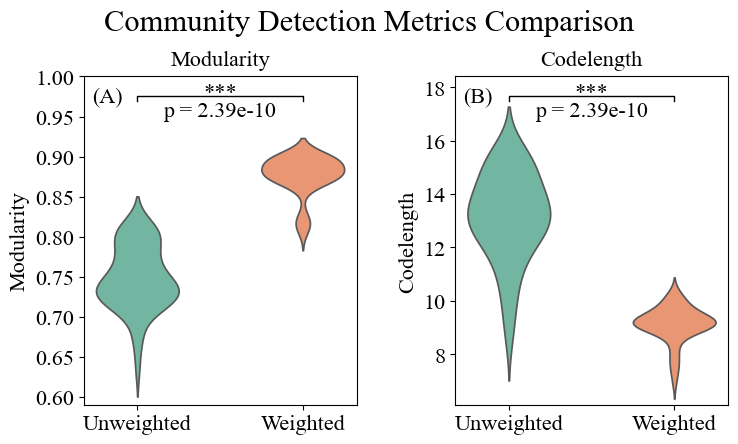

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from scipy import stats
import pandas as pd
font_path = '/home/liujiajun/projects/Hap_networks/TIMES.TTF'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, weight='bold',size=20)

def compare_metrics(mod1, mod2, cl1, cl2, labels=['Unweighted', 'Weighted'], 
                   title=None, figsize=(7.48, 3.74), font_prop=prop,
                   title_fontsize=22, label_fontsize=16, tick_fontsize=16, 
                   annotation_fontsize=16,
                   modularity_ylim=None, codelength_ylim=None,
                   significance_position=0.9,
                   bar_height_factor=0.02,         # 标记横线高度因子
                   significance_text_offset=0.01,  # 显著性标记与横线的距离
                   p_value_offset=0.02,            # p值与横线的距离
                   x_tick_pad=10,                  # X轴刻度与轴的距离
                   y_tick_pad=10):                 # Y轴刻度与轴的距离
    """
    同时比较两组模块度和编码长度，进行Wilcoxon符号秩检验，绘制带显著性标记的小提琴图
    
    参数:
    - mod1, mod2: 两个模块度列表
    - cl1, cl2: 两个编码长度列表
    - labels: 两个列表的标签
    - title: 图表标题
    - figsize: 图表大小
    - font_prop: 字体属性对象
    - modularity_ylim: 模块度y轴范围，格式为(ymin, ymax)
    - codelength_ylim: 编码长度y轴范围，格式为(ymin, ymax)
    - significance_position: 显著性标记的相对位置(0-1之间，0是底部，1是顶部)
    - bar_height_factor: 标记横线高度因子(相对于y轴范围的比例)
    - significance_text_offset: 显著性标记与横线的距离(相对于y轴范围的比例)
    - p_value_offset: p值与横线的距离(相对于y轴范围的比例)
    - x_tick_pad: X轴刻度标签与轴的距离，单位为点
    - y_tick_pad: Y轴刻度标签与轴的距离，单位为点
    """
    # 确保数据是numpy数组
    mod1 = np.array(mod1)
    mod2 = np.array(mod2)
    cl1 = np.array(cl1)
    cl2 = np.array(cl2)
    
    # 创建图形和子图
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # 创建定制字体对象，用于不同元素
    title_font = font_manager.FontProperties(fname=font_prop.get_file(), size=title_fontsize, weight='bold')
    label_font = font_manager.FontProperties(fname=font_prop.get_file(), size=label_fontsize, weight='bold')
    tick_font = font_manager.FontProperties(fname=font_prop.get_file(), size=tick_fontsize, weight='bold')
    annot_font = font_manager.FontProperties(fname=font_prop.get_file(), size=annotation_fontsize, weight='bold')
    
    # 在两个子图中分别绘制模块度和编码长度
    metrics = [(mod1, mod2, "Modularity", modularity_ylim), (cl1, cl2, "Codelength", codelength_ylim)]
    
    # 存储计算出的显著性信息，以便统一处理
    significance_info = []
    
    # 第一次循环：分析数据和计算统计量
    for i, (metric1, metric2, metric_name, ylim) in enumerate(metrics):
        # 过滤掉无效值
        if metric_name == "Modularity":
            valid_indices = (metric1 > 0) & (metric2 > 0)
        else:  # Codelength
            valid_indices = ~np.isnan(metric1) & ~np.isnan(metric2)
            
        metric1_valid = metric1[valid_indices]
        metric2_valid = metric2[valid_indices]
        
        if len(metric1_valid) == 0 or len(metric2_valid) == 0:
            significance_info.append({
                'has_significance': False,
                'metric1_valid': metric1_valid,
                'metric2_valid': metric2_valid,
                'ylim': ylim
            })
            continue
            
        # 打印基本统计量
        print(f"{metric_name} - 样本数: {len(metric1_valid)}")
        print(f"{labels[0]} 均值: {np.mean(metric1_valid):.4f}, 中位数: {np.median(metric1_valid):.4f}")
        print(f"{labels[1]} 均值: {np.mean(metric2_valid):.4f}, 中位数: {np.median(metric2_valid):.4f}")
        
        # 执行Wilcoxon符号秩检验
        try:
            stat, p_value = stats.wilcoxon(metric1_valid, metric2_valid)
            print(f"Wilcoxon检验结果: 统计量={stat:.4f}, p值={p_value:.16f}")
            
            # 确定显著性标记
            if p_value < 0.001:
                significance = '***'
            elif p_value < 0.01:
                significance = '**'
            elif p_value < 0.05:
                significance = '*'
            else:
                significance = 'ns'
                
            print(f"显著性: {significance}")
            
            significance_info.append({
                'has_significance': True,
                'metric1_valid': metric1_valid,
                'metric2_valid': metric2_valid,
                'p_value': p_value,
                'significance': significance,
                'ylim': ylim
            })
            
        except Exception as e:
            print(f"统计检验错误: {str(e)}")
            significance_info.append({
                'has_significance': False,
                'metric1_valid': metric1_valid,
                'metric2_valid': metric2_valid,
                'ylim': ylim
            })
    
    # 第二次循环：绘制图形
    for i, (metric1, metric2, metric_name, ylim) in enumerate(metrics):
        ax = axes[i]
        info = significance_info[i]
        
        if not info.get('has_significance', False) or len(info['metric1_valid']) == 0:
            ax.text(0.5, 0.5, "No valid data", ha='center', va='center', fontproperties=label_font)
            continue
        
        metric1_valid = info['metric1_valid']
        metric2_valid = info['metric2_valid']
        
        # 准备绘图数据
        df = pd.DataFrame({
            'Algorithm': [labels[0] for _ in range(len(metric1_valid))] + [labels[1] for _ in range(len(metric2_valid))],
            metric_name: np.concatenate([metric1_valid, metric2_valid])
        })
        
        # 使用小提琴图
        sns.violinplot(x='Algorithm', y=metric_name, hue='Algorithm', data=df, 
                       palette="Set2", legend=False, width=0.5, inner=None, ax=ax)
        subplot_label = ['(A)', '(B)'][i]
    # 在子图左上方添加文本，用相对坐标定位，字体与轴标签统一
        ax.text(
            x=0.03, y=0.97,          # 相对坐标：左上方（可微调x/y值）
            s=subplot_label,         # 标注文本
            fontproperties=label_font,  # 与轴标签字体一致（粗细、大小统一）
            ha='left', va='top',     # 对齐方式：左对齐、顶对齐
            transform=ax.transAxes   # 关键：使用子图的相对坐标系统
        )
        # 设置y轴范围
        if ylim is not None:
            ax.set_ylim(ylim)
            y_min, y_max = ylim
        else:
            y_min = min(np.min(metric1_valid), np.min(metric2_valid))
            y_max = max(np.max(metric1_valid), np.max(metric2_valid))
        
        y_range = y_max - y_min
        
        # 设置标题和标签
        ax.set_title(metric_name, fontproperties=label_font, pad=8)
        ax.set_ylabel(metric_name, fontproperties=label_font)
        ax.set_xlabel('', fontproperties=label_font)
        
        # 取消网格线
        ax.grid(False)
        
        # 设置刻度标签字体和与轴的距离
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(tick_font)
        
        # 设置刻度与轴的距离
        ax.tick_params(axis='x', pad=x_tick_pad)  # 设置X轴刻度标签与轴的距离
        ax.tick_params(axis='y', pad=y_tick_pad)  # 设置Y轴刻度标签与轴的距离
        
        
        # 设置刻度标签字体
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(tick_font)
    
    # 确定两个子图都的显著性标记位置
    for i, ax in enumerate(axes):
        # 获取当前y轴范围
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        # 计算标记位置（相对于y轴范围的固定比例位置）
        y_pos = y_min + y_range * significance_position
        bar_height = y_range * bar_height_factor
        
        # 只为有显著性的图添加标记
        if i < len(significance_info) and significance_info[i].get('has_significance', False):
            # 添加显著性标记线
            x1, x2 = 0, 1
            ax.plot([x1, x1, x2, x2], [y_pos, y_pos + bar_height*0.5, y_pos + bar_height*0.5, y_pos], lw=1.0, c='black')
            
            # 添加显著性文本 - 减小与横线的距离
            ax.text((x1 + x2) / 2, y_pos + bar_height + y_range * significance_text_offset, 
                   significance_info[i]['significance'], 
                   ha='center', va='bottom', fontproperties=annot_font)
            
            # 添加p值 - 调整与横线的距离
            ax.text((x1 + x2) / 2, y_pos - y_range * p_value_offset, 
                   f'p = {significance_info[i]["p_value"]:.2e}', 
                   ha='center', va='top', fontproperties=annot_font)
    
    # 设置整体标题
    if title:
        fig.suptitle(title, fontproperties=title_font)
    
    # 调整布局
    plt.tight_layout(w_pad=3)
    if title:
        plt.subplots_adjust(top=0.83)
    
    # 保存和显示
    if title:
        plt.savefig(f'{title}.svg', dpi=300, bbox_inches='tight', pad_inches=0.05)
    
    return fig
# 使用示例 - 从metrics中获取模块度和编码长度并可视化
modularities_none = [m[0] for m in metrics_none]  # 从元组中获取模块度
codelengths_none = [m[1] for m in metrics_none]   # 从元组中获取编码长度
modularities_evo = [m[0] for m in metrics_evo]    # 从元组中获取模块度
codelengths_evo = [m[1] for m in metrics_evo]     # 从元组中获取编码长度

# 运行比较

fig = compare_metrics(
    modularities_none, modularities_evo,
    codelengths_none, codelengths_evo,
    labels=['Unweighted', 'Weighted'],
    title="Community Detection Metrics Comparison",
    figsize=(7.48, 7.48*0.6),
    modularity_ylim=(0.59, 1.0),
    codelength_ylim=(6.1, 18.4),
    significance_position=0.925,      # 提高标记整体位置
    bar_height_factor=0.03,         # 减小横线高度
    significance_text_offset=-0.035,  # 减小***与横线距离
    p_value_offset=0.0001,           # 减小p值与横线距离
    x_tick_pad=3,                   # X轴刻度与轴的距离更小
    y_tick_pad=3                  # Y轴刻度与轴的距离更大
)


模块度 - 样本数: 53
无权重 均值: 0.7486, 中位数: 0.7393
加权 均值: 0.8773, 中位数: 0.8795
Wilcoxon检验结果: 统计量=0.0000, p值=0.0000000002386485
显著性: ***
编码长度 - 样本数: 53
无权重 均值: 13.1398, 中位数: 13.2341
加权 均值: 9.1207, 中位数: 9.1691
Wilcoxon检验结果: 统计量=0.0000, p值=0.0000000002386485
显著性: ***


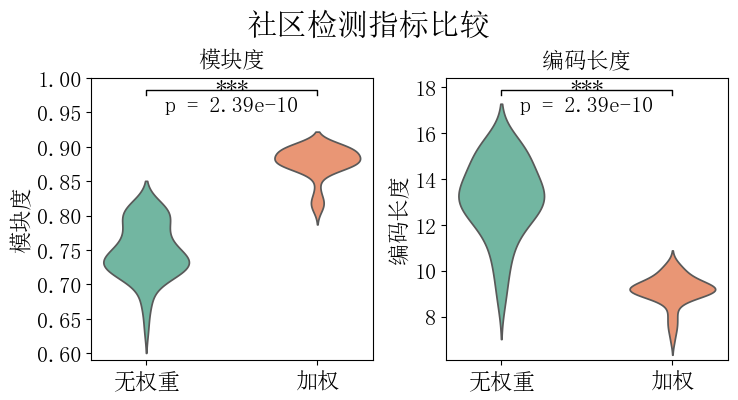

In [74]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import pandas as pd
import seaborn as sns
from scipy import stats  # 添加这一行导入stats模块
cprop = font_manager.FontProperties(fname='/home/liujiajun/projects/Hap_networks/songti.ttf', size=20)
def compare_metrics(mod1, mod2, cl1, cl2, labels=['无权重', '加权'], 
                   title=None, figsize=(7.48, 3.74), font_prop=None,  # 修改默认参数
                   title_fontsize=22, label_fontsize=16, tick_fontsize=16, 
                   annotation_fontsize=16,
                   modularity_ylim=None, codelength_ylim=None,
                   significance_position=0.9,
                   bar_height_factor=0.02,         # 标记横线高度因子
                   significance_text_offset=0.01,  # 显著性标记与横线的距离
                   p_value_offset=0.02,            # p值与横线的距离
                   x_tick_pad=10,                  # X轴刻度与轴的距离
                   y_tick_pad=10):                 # Y轴刻度与轴的距离
    """
    同时比较两组模块度和编码长度，进行Wilcoxon符号秩检验，绘制带显著性标记的小提琴图
    
    参数:
    - mod1, mod2: 两个模块度列表
    - cl1, cl2: 两个编码长度列表
    - labels: 两个列表的标签
    - title: 图表标题
    - figsize: 图表大小
    - font_prop: 字体属性对象
    - modularity_ylim: 模块度y轴范围，格式为(ymin, ymax)
    - codelength_ylim: 编码长度y轴范围，格式为(ymin, ymax)
    - significance_position: 显著性标记的相对位置(0-1之间，0是底部，1是顶部)
    - bar_height_factor: 标记横线高度因子(相对于y轴范围的比例)
    - significance_text_offset: 显著性标记与横线的距离(相对于y轴范围的比例)
    - p_value_offset: p值与横线的距离(相对于y轴范围的比例)
    - x_tick_pad: X轴刻度标签与轴的距离，单位为点
    - y_tick_pad: Y轴刻度标签与轴的距离，单位为点
    """
    # 确保数据是numpy数组
    mod1 = np.array(mod1)
    mod2 = np.array(mod2)
    cl1 = np.array(cl1)
    cl2 = np.array(cl2)
    
    # 创建图形和子图
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # 创建定制字体对象，用于不同元素
    if font_prop is not None:
        title_font = font_manager.FontProperties(fname=font_prop.get_file(), size=title_fontsize, weight='bold')
        label_font = font_manager.FontProperties(fname=font_prop.get_file(), size=label_fontsize, weight='bold')
        tick_font = font_manager.FontProperties(fname=font_prop.get_file(), size=tick_fontsize, weight='bold')
        annot_font = font_manager.FontProperties(fname=font_prop.get_file(), size=annotation_fontsize, weight='bold')
    else:
        # 如果未提供字体，使用默认字体
        title_font = font_manager.FontProperties(size=title_fontsize, weight='bold')
        label_font = font_manager.FontProperties(size=label_fontsize, weight='bold')
        tick_font = font_manager.FontProperties(size=tick_fontsize, weight='bold')
        annot_font = font_manager.FontProperties(size=annotation_fontsize, weight='bold')
    
    # 在两个子图中分别绘制模块度和编码长度
    metrics = [(mod1, mod2, "模块度", modularity_ylim), (cl1, cl2, "编码长度", codelength_ylim)]
    
    # 存储计算出的显著性信息，以便统一处理
    significance_info = []
    
    # 第一次循环：分析数据和计算统计量
    for i, (metric1, metric2, metric_name, ylim) in enumerate(metrics):
        # 过滤掉无效值
        if metric_name == "模块度":
            valid_indices = (metric1 > 0) & (metric2 > 0)
        else:  # 编码长度
            valid_indices = ~np.isnan(metric1) & ~np.isnan(metric2)
            
        metric1_valid = metric1[valid_indices]
        metric2_valid = metric2[valid_indices]
        
        if len(metric1_valid) == 0 or len(metric2_valid) == 0:
            significance_info.append({
                'has_significance': False,
                'metric1_valid': metric1_valid,
                'metric2_valid': metric2_valid,
                'ylim': ylim
            })
            continue
            
        # 打印基本统计量
        print(f"{metric_name} - 样本数: {len(metric1_valid)}")
        print(f"{labels[0]} 均值: {np.mean(metric1_valid):.4f}, 中位数: {np.median(metric1_valid):.4f}")
        print(f"{labels[1]} 均值: {np.mean(metric2_valid):.4f}, 中位数: {np.median(metric2_valid):.4f}")
        
        # 执行Wilcoxon符号秩检验
        try:
            stat, p_value = stats.wilcoxon(metric1_valid, metric2_valid)
            print(f"Wilcoxon检验结果: 统计量={stat:.4f}, p值={p_value:.16f}")
            
            # 确定显著性标记
            if p_value < 0.001:
                significance = '***'
            elif p_value < 0.01:
                significance = '**'
            elif p_value < 0.05:
                significance = '*'
            else:
                significance = 'ns'
                
            print(f"显著性: {significance}")
            
            significance_info.append({
                'has_significance': True,
                'metric1_valid': metric1_valid,
                'metric2_valid': metric2_valid,
                'p_value': p_value,
                'significance': significance,
                'ylim': ylim
            })
            
        except Exception as e:
            print(f"统计检验错误: {str(e)}")
            significance_info.append({
                'has_significance': False,
                'metric1_valid': metric1_valid,
                'metric2_valid': metric2_valid,
                'ylim': ylim
            })
    
    # 第二次循环：绘制图形
    for i, (metric1, metric2, metric_name, ylim) in enumerate(metrics):
        ax = axes[i]
        info = significance_info[i]
        
        if not info.get('has_significance', False) or len(info['metric1_valid']) == 0:
            ax.text(0.5, 0.5, "无有效数据", ha='center', va='center', fontproperties=label_font)
            continue
        
        metric1_valid = info['metric1_valid']
        metric2_valid = info['metric2_valid']
        
        # 准备绘图数据
        df = pd.DataFrame({
            '算法': [labels[0] for _ in range(len(metric1_valid))] + [labels[1] for _ in range(len(metric2_valid))],
            metric_name: np.concatenate([metric1_valid, metric2_valid])
        })
        
        # 使用小提琴图
        sns.violinplot(x='算法', y=metric_name, hue='算法', data=df, 
                       palette="Set2", legend=False, width=0.5, inner=None, ax=ax)
        
        # 设置y轴范围
        if ylim is not None:
            ax.set_ylim(ylim)
            y_min, y_max = ylim
        else:
            y_min = min(np.min(metric1_valid), np.min(metric2_valid))
            y_max = max(np.max(metric1_valid), np.max(metric2_valid))
        
        y_range = y_max - y_min
        
        # 设置标题和标签
        ax.set_title(metric_name, fontproperties=label_font, pad=8)
        ax.set_ylabel(metric_name, fontproperties=label_font)
        ax.set_xlabel('', fontproperties=label_font)
        
        # 取消网格线
        ax.grid(False)
        
        # 设置刻度标签字体和与轴的距离
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(tick_font)
        
        # 设置刻度与轴的距离
        ax.tick_params(axis='x', pad=x_tick_pad)  # 设置X轴刻度标签与轴的距离
        ax.tick_params(axis='y', pad=y_tick_pad)  # 设置Y轴刻度标签与轴的距离
        
        
        # 设置刻度标签字体
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(tick_font)
    
    # 确定两个子图都的显著性标记位置
    for i, ax in enumerate(axes):
        # 获取当前y轴范围
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        # 计算标记位置（相对于y轴范围的固定比例位置）
        y_pos = y_min + y_range * significance_position
        bar_height = y_range * bar_height_factor
        
        # 只为有显著性的图添加标记
        if i < len(significance_info) and significance_info[i].get('has_significance', False):
            # 添加显著性标记线
            x1, x2 = 0, 1
            ax.plot([x1, x1, x2, x2], [y_pos, y_pos + bar_height*0.5, y_pos + bar_height*0.5, y_pos], lw=1.0, c='black')
            
            # 添加显著性文本 - 减小与横线的距离
            ax.text((x1 + x2) / 2, y_pos + bar_height + y_range * significance_text_offset, 
                   significance_info[i]['significance'], 
                   ha='center', va='bottom', fontproperties=annot_font)
            
            # 添加p值 - 调整与横线的距离
            ax.text((x1 + x2) / 2, y_pos - y_range * p_value_offset, 
                   f'p = {significance_info[i]["p_value"]:.2e}', 
                   ha='center', va='top', fontproperties=annot_font)
    
    # 设置整体标题
    if title:
        fig.suptitle(title, fontproperties=title_font)
    
    # 调整布局
    plt.tight_layout()
    if title:
        plt.subplots_adjust(top=0.81)
    
    # 保存和显示
    if title:
        plt.savefig(f'{title}.tiff', dpi=300, bbox_inches='tight')
    
    return fig
# 使用示例 - 从metrics中获取模块度和编码长度并可视化
modularities_none = [m[0] for m in metrics_none]  # 从元组中获取模块度
codelengths_none = [m[1] for m in metrics_none]   # 从元组中获取编码长度
modularities_evo = [m[0] for m in metrics_evo]    # 从元组中获取模块度
codelengths_evo = [m[1] for m in metrics_evo]     # 从元组中获取编码长度

# 运行比较
fig = compare_metrics(
    modularities_none, modularities_evo,
    codelengths_none, codelengths_evo,font_prop=cprop,
    labels=['无权重', '加权'],
    title="社区检测指标比较",
    figsize=(7.48, 7.48*0.54),
    modularity_ylim=(0.59, 1.0),
    codelength_ylim=(6.1, 18.4),
    significance_position=0.94,      # 提高标记整体位置
    bar_height_factor=0.035,         # 减小横线高度
    significance_text_offset=-0.035,  # 减小***与横线距离
    p_value_offset=0.0001,           # 减小p值与横线距离
    x_tick_pad=3,                   # X轴刻度与轴的距离更小
    y_tick_pad=3             # Y轴刻度与轴的距离更大
)


=== 模块度改进百分比分析 ===
平均改进率: 17.34%
中位数改进率: 18.07%
最大改进率: 28.59%
最小改进率: 6.29%

=== 编码长度改进百分比分析 ===
平均改进率: -30.06%
中位数改进率: -30.72%
最大改进率: -18.61%
最小改进率: -35.19%

=== 改进分布 ===
模块度提高的样本比例: 100.0%
编码长度改进的样本比例: 0.0%


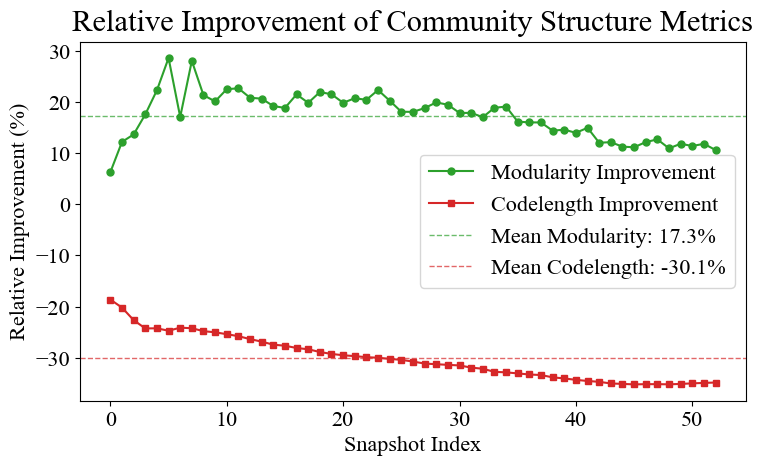

In [42]:
import numpy as np
import pandas as pd
from matplotlib import font_manager
import matplotlib.pyplot as plt
font_path = '/home/liujiajun/projects/Hap_networks/TIMES.TTF'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, weight='bold',size=20)
def analyze_metrics_improvement(mod_unweighted, mod_weighted, cl_unweighted, cl_weighted,
                              labels=['Unweighted', 'Weighted'],
                              title=None, figsize=(7.48, 3.74), font_prop=prop,
                              title_fontsize=22, label_fontsize=16, 
                              tick_fontsize=16, legend_fontsize=16):
    """
    分析并可视化加权前后社区检测两项指标（模块度和编码长度）的改进百分比
    
    参数:
    - mod_unweighted, mod_weighted: 两组模块度数据
    - cl_unweighted, cl_weighted: 两组编码长度数据
    - labels: 数据标签
    - title: 图表标题
    - figsize: 图表尺寸
    - font_prop: 字体属性
    """
    # 确保数据是numpy数组
    mod1 = np.array(mod_unweighted)
    mod2 = np.array(mod_weighted)
    cl1 = np.array(cl_unweighted)
    cl2 = np.array(cl_weighted)
    
    # 过滤掉无效数据
    # 对模块度：过滤掉模块度为0的情况
    mod_valid_indices = (mod1 > 0) & (mod2 > 0)
    mod1_valid = mod1[mod_valid_indices]
    mod2_valid = mod2[mod_valid_indices]
    
    # 对编码长度：过滤掉NaN值
    cl_valid_indices = ~np.isnan(cl1) & ~np.isnan(cl2)
    cl1_valid = cl1[cl_valid_indices]
    cl2_valid = cl2[cl_valid_indices]
    
    # 计算每个时间点的改进百分比
    # 对模块度：增加是改进
    mod_improvement_percent = (mod2_valid - mod1_valid) / mod1_valid * 100
    
    # 对编码长度：减少是改进，所以用负号
    cl_improvement_percent = 1 * (cl2_valid - cl1_valid) / cl1_valid * 100
    
    # 打印两种指标的改进统计
    print(f"=== 模块度改进百分比分析 ===")
    print(f"平均改进率: {np.mean(mod_improvement_percent):.2f}%")
    print(f"中位数改进率: {np.median(mod_improvement_percent):.2f}%")
    print(f"最大改进率: {np.max(mod_improvement_percent):.2f}%")
    print(f"最小改进率: {np.min(mod_improvement_percent):.2f}%")
    
    print(f"\n=== 编码长度改进百分比分析 ===")
    print(f"平均改进率: {np.mean(cl_improvement_percent):.2f}%")
    print(f"中位数改进率: {np.median(cl_improvement_percent):.2f}%")
    print(f"最大改进率: {np.max(cl_improvement_percent):.2f}%")
    print(f"最小改进率: {np.min(cl_improvement_percent):.2f}%")
    
    # 改进的分布情况
    mod_improved_count = np.sum(mod_improvement_percent > 0)
    cl_improved_count = np.sum(cl_improvement_percent > 0)
    
    print(f"\n=== 改进分布 ===")
    print(f"模块度提高的样本比例: {mod_improved_count/len(mod_improvement_percent)*100:.1f}%")
    print(f"编码长度改进的样本比例: {cl_improved_count/len(cl_improvement_percent)*100:.1f}%")
    
    # 绘制改进百分比分布图
    fig, ax = plt.subplots(figsize=figsize)
    
    # 创建字体对象
    title_font = font_manager.FontProperties(fname=font_prop.get_file(), size=title_fontsize, weight='bold')
    label_font = font_manager.FontProperties(fname=font_prop.get_file(), size=label_fontsize, weight='bold')
    legend_font = font_manager.FontProperties(fname=font_prop.get_file(), size=legend_fontsize, weight='bold')
    tick_font = font_manager.FontProperties(fname=font_prop.get_file(), size=tick_fontsize, weight='bold')
    
    # 绘制两条折线
    time_points_mod = np.arange(len(mod_improvement_percent))
    time_points_cl = np.arange(len(cl_improvement_percent))
    
    # 模块度折线 - 蓝色
    line1, = ax.plot(time_points_mod, mod_improvement_percent, 'o-', markersize=5, linewidth=1.5, 
                   color='#2ca02c', label='Modularity Improvement') 
    
    # 编码长度折线 - 红色，注意编码长度是降低为好
    line2, = ax.plot(time_points_cl, cl_improvement_percent, 's-', markersize=5, linewidth=1.5, 
                   color='#d62728', label='Codelength Improvement')
    
    # 添加均值参考线
    mod_mean = np.mean(mod_improvement_percent)
    cl_mean = np.mean(cl_improvement_percent)
    
    ax.axhline(y=mod_mean, color='#2ca02c', linestyle='--', alpha=0.7, linewidth=1.0,
              label=f'Mean Modularity: {mod_mean:.1f}%')  # 使用绿色 #2ca02c
    
    ax.axhline(y=cl_mean, color='#d62728', linestyle='--', alpha=0.7, linewidth=1.0,
              label=f'Mean Codelength: {cl_mean:.1f}%')
    
    # 设置轴标签和标题
    ax.set_xlabel('Snapshot Index', fontproperties=label_font)
    ax.set_ylabel('Relative Improvement (%)', fontproperties=label_font)
    
    if title:
        ax.set_title(f"{title}", fontproperties=title_font, pad=8)
    else:
        ax.set_title("Effect of Edge Weighting on Community Detection", fontproperties=title_font)
    
    # 删除网格线
    ax.grid(False)
    
    # 添加图例，使用自定义字体和字体大小
    ax.legend(loc='best', prop=legend_font)
    
    # 优化布局
    plt.tight_layout(pad=0.2, w_pad=0.5, h_pad=1.0)
    plt.subplots_adjust(left=0.10, right=0.99, top=0.92, bottom=0.12)
    
    # 设置刻度标签字体
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(tick_font)
    
    # 保存图表
    if title:
        plt.savefig(f'{title}.svg', dpi=300, bbox_inches='tight', pad_inches=0.05)
    
    plt.show()
    
    # 创建详细的结果表格
    results_df = pd.DataFrame({
        'Original_Modularity': mod1_valid,
        'Weighted_Modularity': mod2_valid,
        'Modularity_Improvement(%)': mod_improvement_percent,
        'Original_Codelength': cl1_valid, 
        'Weighted_Codelength': cl2_valid,
        'Codelength_Improvement(%)': cl_improvement_percent
    })
    
    # 按模块度改进排序
    results_sorted = results_df.sort_values('Modularity_Improvement(%)', ascending=False)
    
    return results_sorted, {
        'mod_mean_improvement': mod_mean,
        'mod_improved_ratio': mod_improved_count/len(mod_improvement_percent)*100,
        'cl_mean_improvement': cl_mean,
        'cl_improved_ratio': cl_improved_count/len(cl_improvement_percent)*100
    }

# 从metrics中获取数据
modularities_none = [m[0] for m in metrics_none]
codelengths_none = [m[1] for m in metrics_none]
modularities_evo = [m[0] for m in metrics_evo]
codelengths_evo = [m[1] for m in metrics_evo]

# 运行改进分析
results, stats = analyze_metrics_improvement(
    modularities_none, modularities_evo,
    codelengths_none, codelengths_evo,
    title="Relative Improvement of Community Structure Metrics",
    figsize=(7.48, 7.48*0.6)
)


=== 模块度改进百分比分析 ===
平均改进率: 17.40%
中位数改进率: 18.62%
最大改进率: 28.57%
最小改进率: 6.29%

=== 编码长度改进百分比分析 ===
平均改进率: -30.05%
中位数改进率: -30.72%
最大改进率: -18.61%
最小改进率: -35.18%

=== 改进分布 ===
模块度提高的样本比例: 100.0%
编码长度改进的样本比例: 0.0%


/picb/bigdata/project/liujiajun/ljjtmp/ipykernel_8931/1954454609.py:121: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) ????.
  plt.savefig(f'{title}.tiff', dpi=300, bbox_inches='tight', pad_inches=0.05)
/home/liujiajun/anaconda3/envs/ljj/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) ????.
  fig.canvas.print_figure(bytes_io, **kw)


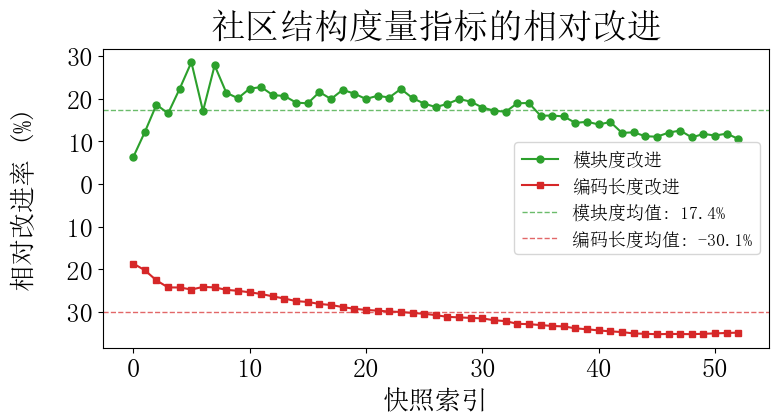

In [75]:
from matplotlib import font_manager
import matplotlib.pyplot as plt

def analyze_metrics_improvement(mod_unweighted, mod_weighted, cl_unweighted, cl_weighted,
                              labels=['无权重', '加权'],
                              title=None, figsize=(7.48, 3.74), font_prop=prop,
                              title_fontsize=25, label_fontsize=19, 
                              tick_fontsize=19, legend_fontsize=13):
    """
    分析并可视化加权前后社区检测两项指标（模块度和编码长度）的改进百分比
    
    参数:
    - mod_unweighted, mod_weighted: 两组模块度数据
    - cl_unweighted, cl_weighted: 两组编码长度数据
    - labels: 数据标签
    - title: 图表标题
    - figsize: 图表尺寸
    - font_prop: 字体属性
    """
    # 确保数据是numpy数组
    mod1 = np.array(mod_unweighted)
    mod2 = np.array(mod_weighted)
    cl1 = np.array(cl_unweighted)
    cl2 = np.array(cl_weighted)
    
    # 过滤掉无效数据
    # 对模块度：过滤掉模块度为0的情况
    mod_valid_indices = (mod1 > 0) & (mod2 > 0)
    mod1_valid = mod1[mod_valid_indices]
    mod2_valid = mod2[mod_valid_indices]
    
    # 对编码长度：过滤掉NaN值
    cl_valid_indices = ~np.isnan(cl1) & ~np.isnan(cl2)
    cl1_valid = cl1[cl_valid_indices]
    cl2_valid = cl2[cl_valid_indices]
    
    # 计算每个时间点的改进百分比
    # 对模块度：增加是改进
    mod_improvement_percent = (mod2_valid - mod1_valid) / mod1_valid * 100
    
    # 对编码长度：减少是改进，所以用负号
    cl_improvement_percent = 1 * (cl2_valid - cl1_valid) / cl1_valid * 100
    
    # 打印两种指标的改进统计
    print(f"=== 模块度改进百分比分析 ===")
    print(f"平均改进率: {np.mean(mod_improvement_percent):.2f}%")
    print(f"中位数改进率: {np.median(mod_improvement_percent):.2f}%")
    print(f"最大改进率: {np.max(mod_improvement_percent):.2f}%")
    print(f"最小改进率: {np.min(mod_improvement_percent):.2f}%")
    
    print(f"\n=== 编码长度改进百分比分析 ===")
    print(f"平均改进率: {np.mean(cl_improvement_percent):.2f}%")
    print(f"中位数改进率: {np.median(cl_improvement_percent):.2f}%")
    print(f"最大改进率: {np.max(cl_improvement_percent):.2f}%")
    print(f"最小改进率: {np.min(cl_improvement_percent):.2f}%")
    
    # 改进的分布情况
    mod_improved_count = np.sum(mod_improvement_percent > 0)
    cl_improved_count = np.sum(cl_improvement_percent > 0)
    
    print(f"\n=== 改进分布 ===")
    print(f"模块度提高的样本比例: {mod_improved_count/len(mod_improvement_percent)*100:.1f}%")
    print(f"编码长度改进的样本比例: {cl_improved_count/len(cl_improvement_percent)*100:.1f}%")
    
    # 绘制改进百分比分布图
    fig, ax = plt.subplots(figsize=figsize)
    
    # 创建字体对象
    title_font = font_manager.FontProperties(fname=font_prop.get_file(), size=title_fontsize, weight='bold')
    label_font = font_manager.FontProperties(fname=font_prop.get_file(), size=label_fontsize, weight='bold')
    legend_font = font_manager.FontProperties(fname=font_prop.get_file(), size=legend_fontsize, weight='bold')
    tick_font = font_manager.FontProperties(fname=font_prop.get_file(), size=tick_fontsize, weight='bold')
    
    # 绘制两条折线
    time_points_mod = np.arange(len(mod_improvement_percent))
    time_points_cl = np.arange(len(cl_improvement_percent))
    
    # 模块度折线 - 绿色
    line1, = ax.plot(time_points_mod, mod_improvement_percent, 'o-', markersize=5, linewidth=1.5, 
                   color='#2ca02c', label='模块度改进') 
    
    # 编码长度折线 - 红色，注意编码长度是降低为好
    line2, = ax.plot(time_points_cl, cl_improvement_percent, 's-', markersize=5, linewidth=1.5, 
                   color='#d62728', label='编码长度改进')
    
    # 添加均值参考线
    mod_mean = np.mean(mod_improvement_percent)
    cl_mean = np.mean(cl_improvement_percent)
    
    ax.axhline(y=mod_mean, color='#2ca02c', linestyle='--', alpha=0.7, linewidth=1.0,
              label=f'模块度均值: {mod_mean:.1f}%')  # 使用绿色 #2ca02c
    
    ax.axhline(y=cl_mean, color='#d62728', linestyle='--', alpha=0.7, linewidth=1.0,
              label=f'编码长度均值: {cl_mean:.1f}%')
    
    # 设置轴标签和标题
    ax.set_xlabel('快照索引', fontproperties=label_font)
    ax.set_ylabel('相对改进率 (%)', fontproperties=label_font)
    
    if title:
        ax.set_title(f"{title}", fontproperties=title_font, pad=8)
    else:
        ax.set_title("边权重对社区检测的影响", fontproperties=title_font)
    
    # 删除网格线
    ax.grid(False)
    
    # 添加图例，使用自定义字体和字体大小
    ax.legend(loc='best', prop=legend_font)
    
    # 优化布局
    plt.tight_layout(pad=0.2, w_pad=0.5, h_pad=1.0)
    plt.subplots_adjust(left=0.10, right=0.99, top=0.92, bottom=0.12)
    
    # 设置刻度标签字体
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(tick_font)
    
    # 保存图表
    if title:
        plt.savefig(f'{title}.tiff', dpi=300, bbox_inches='tight', pad_inches=0.05)
    
    plt.show()
    
    # 创建详细的结果表格
    results_df = pd.DataFrame({
        '原始模块度': mod1_valid,
        '加权模块度': mod2_valid,
        '模块度改进率(%)': mod_improvement_percent,
        '原始编码长度': cl1_valid, 
        '加权编码长度': cl2_valid,
        '编码长度改进率(%)': cl_improvement_percent
    })
    
    # 按模块度改进排序
    results_sorted = results_df.sort_values('模块度改进率(%)', ascending=False)
    
    return results_sorted, {
        'mod_mean_improvement': mod_mean,
        'mod_improved_ratio': mod_improved_count/len(mod_improvement_percent)*100,
        'cl_mean_improvement': cl_mean,
        'cl_improved_ratio': cl_improved_count/len(cl_improvement_percent)*100
    }

# 从metrics中获取数据
modularities_none = [m[0] for m in metrics_none]
codelengths_none = [m[1] for m in metrics_none]
modularities_evo = [m[0] for m in metrics_evo]
codelengths_evo = [m[1] for m in metrics_evo]

# 运行改进分析
results, stats = analyze_metrics_improvement(
    modularities_none, modularities_evo,
    codelengths_none, codelengths_evo,font_prop=cprop,
    title="社区结构度量指标的相对改进",
    figsize=(7.48, 3.74)
)


In [ ]:

tracking_chains_fran1, df_track_fran1 = track_community_evolution(
    partitions=partitions_evo_wdks,
    extended_graphs=wdks_graphs_n,
    label_of_interest='3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G);25563(SNP:G->T)',
    tracking_label='Mutations_str',  # 用于追踪社区的标签
    recording_label='Pango',         # 用于记录分析结果的标签
    start_date='2020-03-25',
    end_date='2020-11-04',
    time_interval=7,
    similarity_threshold=0.4
)


In [68]:
tracking_chains_fran1[1]


In [69]:
tracking_chains_fran2, df_track_fran2 = track_community_evolution(
    partitions=partitions_evo_wdks,
    extended_graphs=wdks_graphs_n,
    label_of_interest='1059(SNP:C->T);3037(SNP:C->T);10582(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G);25563(SNP:G->T)',
    tracking_label='Mutations_str',  # 用于追踪社区的标签
    recording_label='Pango',         # 用于记录分析结果的标签
    start_date='2020-03-25',
    end_date='2020-11-04',
    time_interval=7,
    similarity_threshold=0.4
)


In [70]:
tracking_chains_fran2[0]


In [21]:
if 'Trace' in sys.modules:
    del sys.modules['Trace']
from Trace import track_community_evolution


In [73]:
tracking_chains_fran3= track_community_evolution(
    partitions=communities,
    extended_graphs=graphs,
    label_of_interest='3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);23403(SNP:A->G)',
    tracking_label='name',  # 用于追踪社区的标签
    recording_label='Lineage',         # 用于记录分析结果的标签
    start_date='2020-03-25',
    end_date='2020-11-04',
    time_interval=7,
    similarity_threshold=0.4,output_path='/home/liujiajun/projects/Hap_networks/module/04-15/0605/B_1_1_tracking_chains_Key_France.h5'
)


Processing graphs from index 0 to 32, corresponding to approx. date range: 2020-03-25 to 2020-11-04
Using GPU similarity calculator.
Starting tracking from 33 target communities...
Identified 33 communities in the evolution chain (33 targets + 0 tracked predecessors). Tracking took 2.20s.
Generated tracking DataFrame with 33 rows.
Identified 1 root nodes and 33 labeled nodes. Total 33 unique start points for chain building.
Building chains in parallel using 4 processes...


2025-06-05 23:14:33,464 - Saving data to B_1_1_tracking_chains_Key_France.h5 (CompLevel:3, Threads:4)


Constructed 33 raw chains containing the label.
Reduced to 1 unique chains after deduplication. Chain construction took 6.51s.
Tracking results successfully saved to /home/liujiajun/projects/Hap_networks/module/04-15/0605/B_1_1_tracking_chains_Key_France.h5.
Total processing time: 14.39s


In [14]:
tracking_chains_fran3[0]


,Community ID,Contains Label,Similarity,Lineage Counts,Matched From Date,Matched From Community ID,Core Node,Mutations_of_core_node,Matched From Time Index,Alternative Matched From
Date,,,,,,,,,,
2020-03-25,37,True,0.000,"{""B.1"": 2, ""B.1.147"": 1, ""B.1.212"": 1, ""B.1.38...",<NA>,<NA>,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,<NA>,[]
2020-04-01,54,True,0.913,"{""B.1"": 6, ""B.1.147"": 5, ""B.1.208"": 1, ""B.1.21...",2020-03-25,37,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,0,[]
2020-04-08,86,True,0.861,"{""B.1"": 17, ""B.1.151"": 1, ""B.1.178"": 1, ""B.1.2...",2020-04-01,54,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,1,[]
2020-04-15,113,True,0.989,"{""B.1"": 19, ""B.1.151"": 1, ""B.1.178"": 1, ""B.1.2...",2020-04-08,86,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,2,[]
2020-04-22,126,True,0.970,"{""B.1"": 27, ""B.1.151"": 1, ""B.1.178"": 2, ""B.1.2...",2020-04-15,113,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,3,[]
2020-04-29,131,True,0.964,"{""B.1"": 31, ""B.1.143"": 1, ""B.1.147"": 5, ""B.1.1...",2020-04-22,126,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,4,[]
2020-05-06,182,True,0.978,"{""B.1"": 33, ""B.1.143"": 1, ""B.1.151"": 1, ""B.1.1...",2020-04-29,131,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,5,[]
2020-05-13,229,True,0.968,"{""B.1"": 41, ""B.1.143"": 1, ""B.1.149"": 1, ""B.1.1...",2020-05-06,182,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,6,[]
2020-05-20,265,True,0.995,"{""B.1"": 43, ""B.1.143"": 1, ""B.1.149"": 1, ""B.1.1...",2020-05-13,229,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,7,[]


In [13]:
tracking_chains_fran3=IOManager.load_from_hdf5('/home/liujiajun/projects/Hap_networks/module/09-25/0605/B_1_1_tracking_chains_Key_France.h5')


In [42]:
import sys
import importlib

# 确保模块已被导入（如果未导入，先导入）
try:
    from Trace import extract_community_nodes
except ImportError:
    import Trace
    importlib.reload(Trace)
    extract_community_nodes = Trace.extract_community_nodes
else:
    # 如果已导入，重新加载模块
    import Trace
    importlib.reload(Trace)
    # 重新获取函数
    extract_community_nodes = Trace.extract_community_nodes


In [13]:

nodes_df2 = extract_community_nodes(
    community_id=317,
    date_str='2020-06-03',
    graphs=graphs,
    communities=communities,
    chains=tracking_chains_fran3,
    debug=True
)


Extracted 80 nodes in 4.8688s


In [14]:
nodes_df2


,Date,ID,Lineage,Location,Ancestor_ID,wdks
Mutations_str,,,,,,
3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);23403(SNP:A->G);25433(SNP:C->T);29546(SNP:C->T),2020-03-30,"[EPI_ISL_429776, EPI_ISL_418418, EPI_ISL_418419]",B.1.147,France,"[EPI_ISL_418663, EPI_ISL_418811, EPI_ISL_42040...",0.000005
3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);21724(SNP:G->T);23403(SNP:A->G);25433(SNP:C->T),2020-03-23,[EPI_ISL_416757],B.1.147,France,"[EPI_ISL_418663, EPI_ISL_418811, EPI_ISL_42040...",0.000005
3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);18656(SNP:C->T);23403(SNP:A->G);25433(SNP:C->T),2020-03-29,[EPI_ISL_418222],B.1.147,France,"[EPI_ISL_418663, EPI_ISL_418811, EPI_ISL_42040...",0.000005
3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);23403(SNP:A->G);25433(SNP:C->T);26313(SNP:C->T),2020-03-30,[EPI_ISL_418653],B.1.147,Belgium,"[EPI_ISL_418663, EPI_ISL_418811, EPI_ISL_42040...",0.000005
3037(SNP:C->T);11083(SNP:G->T);14408(SNP:C->T);15324(SNP:C->T);18828(SNP:C->T);23403(SNP:A->G),2020-04-29,[EPI_ISL_434502],B.1,Luxembourg,"[EPI_ISL_420381, EPI_ISL_437352, MT506893.1]",0.000005
...,...,...,...,...,...,...
3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);15654(SNP:C->T);23403(SNP:A->G),2020-06-01,[NMDC60013157],B.1,China,"[EPI_ISL_416493, EPI_ISL_417946, EPI_ISL_41794...",0.001328
3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);21058(SNP:C->T);23403(SNP:A->G),2020-06-01,[NMDC60013241],B.1,China,"[EPI_ISL_416493, EPI_ISL_417946, EPI_ISL_41794...",0.001328
3037(SNP:C->T);6101(SNP:G->A);14408(SNP:C->T);15324(SNP:C->T);23403(SNP:A->G),2020-06-01,[NMDC60013161],B.1,China,"[EPI_ISL_416493, EPI_ISL_417946, EPI_ISL_41794...",0.001328


In [30]:
tracking_chains_fran3[0]


,Community ID,Contains Label,Similarity,Lineage Counts,Matched From Date,Matched From Community ID,Core Node,Mutations_of_core_node,Matched From Time Index,Alternative Matched From
Date,,,,,,,,,,
2020-03-25,37,True,0.000,"{""B.1"": 2, ""B.1.147"": 1, ""B.1.212"": 1, ""B.1.38...",<NA>,<NA>,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,<NA>,[]
2020-04-01,54,True,0.913,"{""B.1"": 6, ""B.1.147"": 5, ""B.1.208"": 1, ""B.1.21...",2020-03-25,37,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,0,[]
2020-04-08,86,True,0.861,"{""B.1"": 17, ""B.1.151"": 1, ""B.1.178"": 1, ""B.1.2...",2020-04-01,54,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,1,[]
2020-04-15,113,True,0.989,"{""B.1"": 19, ""B.1.151"": 1, ""B.1.178"": 1, ""B.1.2...",2020-04-08,86,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,2,[]
2020-04-22,126,True,0.970,"{""B.1"": 27, ""B.1.151"": 1, ""B.1.178"": 2, ""B.1.2...",2020-04-15,113,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,3,[]
2020-04-29,131,True,0.964,"{""B.1"": 31, ""B.1.143"": 1, ""B.1.147"": 5, ""B.1.1...",2020-04-22,126,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,4,[]
2020-05-06,182,True,0.978,"{""B.1"": 33, ""B.1.143"": 1, ""B.1.151"": 1, ""B.1.1...",2020-04-29,131,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,5,[]
2020-05-13,229,True,0.968,"{""B.1"": 41, ""B.1.143"": 1, ""B.1.149"": 1, ""B.1.1...",2020-05-06,182,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,6,[]
2020-05-20,265,True,0.995,"{""B.1"": 43, ""B.1.143"": 1, ""B.1.149"": 1, ""B.1.1...",2020-05-13,229,B.1,3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T)...,7,[]


In [49]:
tracking_chains_B_1_1= track_community_evolution(
    partitions=communities,
    extended_graphs=graphs,
    label_of_interest='3037(SNP:C->T);14408(SNP:C->T);16887(SNP:C->T);23403(SNP:A->G);28881(SNP:G->A);28882(SNP:G->A);28883(SNP:G->C)',
    tracking_label='name',  # 用于追踪社区的标签
    recording_label='Lineage',         # 用于记录分析结果的标签
    start_date='2020-03-25',
    end_date='2020-07-08',
    time_interval=7,
    similarity_threshold=0.4,output_path='/home/liujiajun/projects/Hap_networks/module/04-15/0605/B_1_1_tracking_chains_0329_France.h5'
)


Processing graphs from index 0 to 15, corresponding to approx. date range: 2020-03-25 to 2020-07-08
Using GPU similarity calculator.
Starting tracking from 15 target communities...
Identified 32 communities in the evolution chain (15 targets + 17 tracked predecessors). Tracking took 2.94s.
Generated tracking DataFrame with 32 rows.
Identified 3 root nodes and 15 labeled nodes. Total 17 unique start points for chain building.
Building chains in parallel using 4 processes...


2025-06-05 21:51:32,697 - Saving data to B_1_1_tracking_chains_0329_France.h5 (CompLevel:3, Threads:4)


Constructed 17 raw chains containing the label.
Reduced to 4 unique chains after deduplication. Chain construction took 7.82s.
Tracking results successfully saved to /home/liujiajun/projects/Hap_networks/module/04-15/0605/B_1_1_tracking_chains_0329_France.h5.
Total processing time: 16.10s


In [53]:
nodes_df_B_1_1 = extract_community_nodes(
    community_id=25,
    date_str='2020-06-03',
    graphs=graphs,
    communities=communities,
    chains=tracking_chains_B_1_1,
    debug=True
)


Extracted 238 nodes in 4.8985s


In [54]:
tracking_chains_B_1_1[0]


,Community ID,Contains Label,Similarity,Lineage Counts,Matched From Date,Matched From Community ID,Core Node,Mutations_of_core_node,Matched From Time Index,Alternative Matched From
Date,,,,,,,,,,
2020-03-25,11,False,0.000,"{""B.1.1"": 2}",<NA>,<NA>,B.1.1,3037(SNP:C->T);10265(SNP:G->A);14408(SNP:C->T)...,<NA>,[]
2020-04-01,16,False,1.000,"{""B.1.1"": 2}",2020-03-25,11,B.1.1,3037(SNP:C->T);10265(SNP:G->A);14408(SNP:C->T)...,0,[]
2020-04-08,21,False,1.000,"{""B.1.1"": 2}",2020-04-01,16,B.1.1,3037(SNP:C->T);10265(SNP:G->A);14408(SNP:C->T)...,1,[]
2020-04-15,26,False,0.764,"{""B.1.1"": 2}",2020-04-08,21,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,2,[]
2020-04-22,33,False,1.000,"{""B.1.1"": 2}",2020-04-15,26,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,3,[]
2020-04-29,41,False,1.000,"{""B.1.1"": 2}",2020-04-22,33,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,4,[]
2020-05-06,88,False,0.708,"{""B.1.1"": 2}",2020-04-29,41,B.1.1,1170(SNP:C->T);3037(SNP:C->T);14408(SNP:C->T);...,5,"[[5, 44], [5, 47], [5, 52], [5, 55], [5, 57], ..."
2020-05-13,70,False,1.000,"{""B.1.1"": 2}",2020-05-06,88,B.1.1,1170(SNP:C->T);3037(SNP:C->T);14408(SNP:C->T);...,6,[]
2020-05-20,89,False,0.708,"{""B.1.1"": 2}",2020-05-13,70,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,7,"[[7, 78], [7, 79], [7, 84], [7, 88], [7, 90], ..."


In [50]:
tracking_chains_B_1_1[1]


,Community ID,Contains Label,Similarity,Lineage Counts,Matched From Date,Matched From Community ID,Core Node,Mutations_of_core_node,Matched From Time Index,Alternative Matched From
Date,,,,,,,,,,
2020-03-25,11,False,0.000,"{""B.1.1"": 2}",<NA>,<NA>,B.1.1,3037(SNP:C->T);10265(SNP:G->A);14408(SNP:C->T)...,<NA>,[]
2020-04-01,16,False,1.000,"{""B.1.1"": 2}",2020-03-25,11,B.1.1,3037(SNP:C->T);10265(SNP:G->A);14408(SNP:C->T)...,0,[]
2020-04-08,21,False,1.000,"{""B.1.1"": 2}",2020-04-01,16,B.1.1,3037(SNP:C->T);10265(SNP:G->A);14408(SNP:C->T)...,1,[]
2020-04-15,26,False,0.764,"{""B.1.1"": 2}",2020-04-08,21,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,2,[]
2020-04-22,33,False,1.000,"{""B.1.1"": 2}",2020-04-15,26,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,3,[]
2020-04-29,14,True,0.677,"{""B.1.1"": 2}",2020-04-22,33,B.1.1,3037(SNP:C->T);14408(SNP:C->T);16887(SNP:C->T)...,4,"[[4, 37], [4, 43], [4, 45], [4, 47], [4, 54], ..."
2020-05-06,16,True,1.000,"{""B.1.1"": 2}",2020-04-29,14,B.1.1,3037(SNP:C->T);14408(SNP:C->T);16887(SNP:C->T)...,5,[]
2020-05-13,24,True,1.000,"{""B.1.1"": 2}",2020-05-06,16,B.1.1,3037(SNP:C->T);14408(SNP:C->T);16887(SNP:C->T)...,6,[]
2020-05-20,26,True,1.000,"{""B.1.1"": 2}",2020-05-13,24,B.1.1,3037(SNP:C->T);14408(SNP:C->T);16887(SNP:C->T)...,7,[]


In [51]:
tracking_chains_B_1_1[2]


,Community ID,Contains Label,Similarity,Lineage Counts,Matched From Date,Matched From Community ID,Core Node,Mutations_of_core_node,Matched From Time Index,Alternative Matched From
Date,,,,,,,,,,
2020-04-08,12,True,0.000,"{""B.1"": 82, ""B.1.1"": 30, ""B.1.1.137"": 1, ""B.1....",<NA>,<NA>,B.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G),<NA>,[]
2020-04-15,19,True,0.941,"{""B.1"": 135, ""B.1.1"": 50, ""B.1.1.137"": 1, ""B.1...",2020-04-08,12,B.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G),2,[]
2020-04-22,8,True,0.974,"{""B.1"": 176, ""B.1.1"": 55, ""B.1.1.137"": 1, ""B.1...",2020-04-15,19,B.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G),3,[]
2020-04-29,29,False,0.963,"{""B.1"": 226, ""B.1.1"": 90, ""B.1.1.129"": 1, ""B.1...",2020-04-22,8,B.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G),4,[]
2020-05-06,18,False,0.709,"{""B.1.1"": 104, ""B.1.1.1"": 1, ""B.1.1.129"": 1, ""...",2020-04-29,29,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,5,[]
2020-05-13,25,False,0.959,"{""B.1.1"": 146, ""B.1.1.1"": 1, ""B.1.1.129"": 1, ""...",2020-05-06,18,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,6,[]
2020-05-20,27,False,0.975,"{""B.1.1"": 173, ""B.1.1.1"": 1, ""B.1.1.129"": 2, ""...",2020-05-13,25,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,7,[]
2020-05-27,31,False,0.989,"{""B.1.1"": 180, ""B.1.1.1"": 1, ""B.1.1.129"": 2, ""...",2020-05-20,27,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,8,[]
2020-06-03,25,True,0.982,"{""B.1"": 1, ""B.1.1"": 204, ""B.1.1.1"": 2, ""B.1.1....",2020-05-27,31,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,9,[]


In [52]:
tracking_chains_B_1_1[3]


,Community ID,Contains Label,Similarity,Lineage Counts,Matched From Date,Matched From Community ID,Core Node,Mutations_of_core_node,Matched From Time Index,Alternative Matched From
Date,,,,,,,,,,
2020-03-25,1,False,0.000,"{""B.1.1"": 7, ""B.1.1.1"": 1, ""B.1.1.10"": 1, ""B.1...",<NA>,<NA>,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,<NA>,[]
2020-04-01,24,True,0.898,"{""B.1.1"": 12, ""B.1.1.28"": 1}",2020-03-25,1,B.1.1,3037(SNP:C->T);14408(SNP:C->T);23403(SNP:A->G)...,0,[]


Visualizing community evolution chain...
Custom font loaded from /home/liujiajun/projects/Hap_networks/TIMES.TTF
Converted index to DatetimeIndex.
Filtered from 33 to 9 communities based on date index.
Searching for first target node ID with label '3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);23403(SNP:A->G)'...
Found first target node ID: EPI_ISL_416493 on date 2020-04-08
Figure saved to: Evolutionary_path_04-08-06-03_n_0425.svg


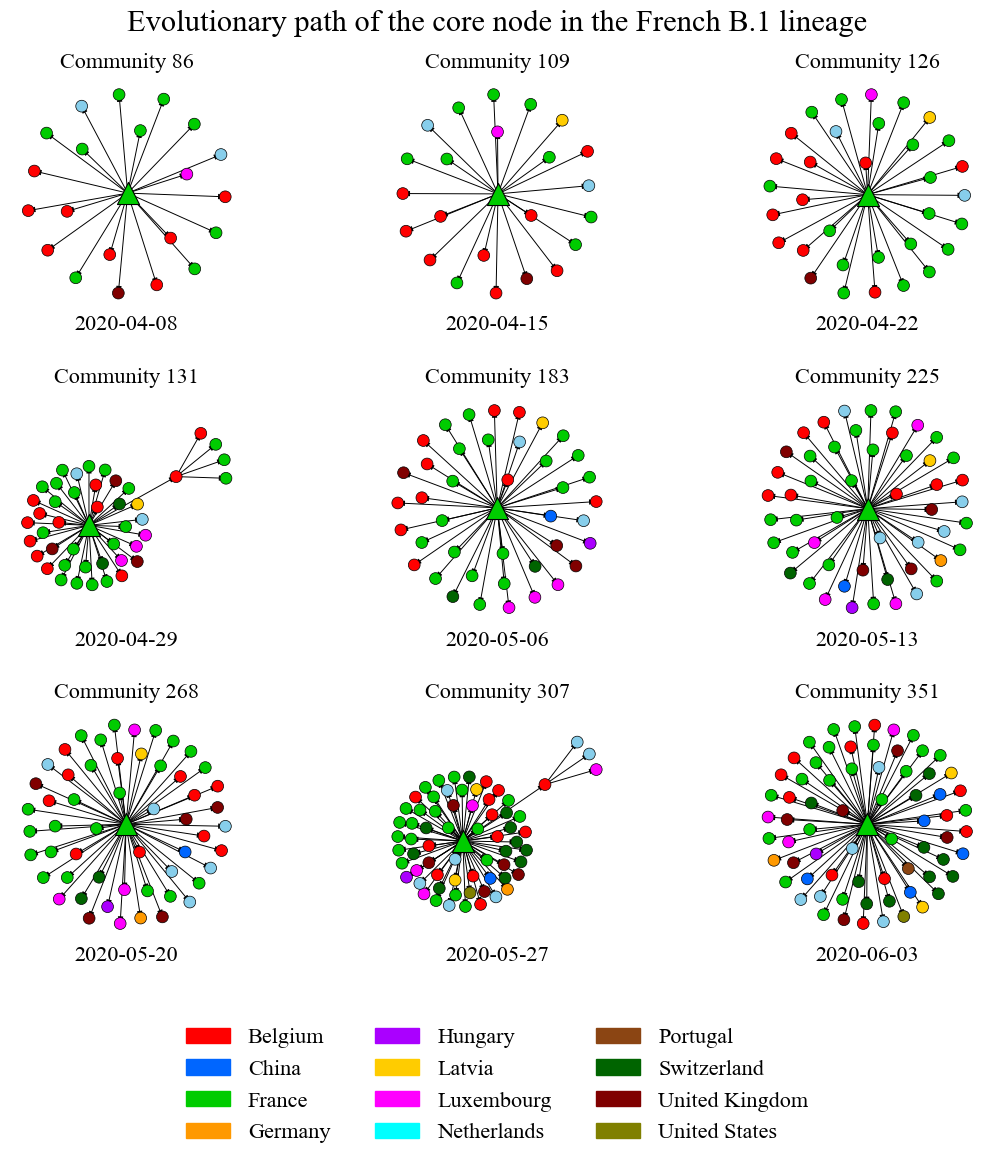

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as font_manager
import igraph as ig
from typing import List, Tuple

def find_first_target_node_id(
    df: pd.DataFrame,
    graphs: List[ig.Graph],
    date_indices: dict,
    partitions: List[List[List[str]]],
    tracking_label: str,
    label_of_interest: str,
    id_attribute: str = 'ID' # 假设节点ID存储在'ID'属性中
) -> str:
    """Helper function to find the ID of the first target node encountered."""
    print(f"Searching for first target node ID with label '{label_of_interest}'...")
    for date_obj, row in df.iterrows():
        if isinstance(date_obj, pd.Timestamp):
            date_str = date_obj.strftime('%Y-%m-%d')
        else:
            try: date_str = pd.to_datetime(date_obj).strftime('%Y-%m-%d')
            except: continue # Skip if date cannot be parsed

        time_idx = date_indices.get(date_str)
        community_id = row.get('Community ID') # Use .get for safety

        if time_idx is None or community_id is None or time_idx >= len(graphs) or time_idx >= len(partitions):
            continue

        try:
            community_id = int(community_id)
            if not (0 <= community_id < len(partitions[time_idx])):
                 continue # Invalid community ID for this time index

            community_members = partitions[time_idx][community_id]
            orig_graph = graphs[time_idx]

            if not orig_graph or orig_graph.vcount() == 0:
                continue

            name_to_idx = {v['name']: v.index for v in orig_graph.vs if 'name' in v.attributes()}
            member_indices = [name_to_idx[m] for m in community_members if m in name_to_idx]

            if not member_indices:
                continue

            subgraph = orig_graph.subgraph(member_indices)

            for v in subgraph.vs:
                if tracking_label not in v.attributes() or id_attribute not in v.attributes():
                    continue

                track_val = v[tracking_label]
                is_target = False
                # Simplified target check
                try:
                    if isinstance(track_val, str) and track_val == label_of_interest: is_target = True
                    elif isinstance(track_val, (list, tuple, np.ndarray)) and label_of_interest in map(str, track_val): is_target = True
                    elif str(track_val) == label_of_interest: is_target = True
                except: pass # Ignore comparison errors

                if is_target:
                    id_val = v[id_attribute]
                    if id_val is not None:
                        # Return the first ID found (handle potential list/array)
                        first_id = str(id_val[0]) if isinstance(id_val, (list, tuple, np.ndarray)) and len(id_val)>0 else str(id_val)
                        print(f"Found first target node ID: {first_id} on date {date_str}")
                        return first_id # Return the first ID found

        except Exception as e:
            # Log error during search but continue searching
            print(f"Minor error during target ID search for {date_str}, community {community_id}: {e}")
            continue

    print("Target node ID not found in the provided chain data.")
    return "Unknown" # Return default if not found


def visualize_community_chain(
    chain_df: pd.DataFrame,
    partitions: List[List[List[str]]],
    graphs: List[ig.Graph],
    label_of_interest: str,
    tracking_label: str = "name", # Changed default to 'name' as used in call
    color_attr: str = "Location",
    highlight_attrs: List[str] = None,
    figsize: Tuple[float, float] = (10, 10), # Use float for figsize
    max_cols: int = 4,
    base_node_size: float = 30,
    save_path: str = None,
    fig_title: str = None,
    save_dpi: int = 300,
    start_date: str = None,
    end_date: str = None,
    other_color: str = "#87CEEB",
    font_path: str = '/home/liujiajun/projects/Hap_networks/TIMES.TTF'
):
    """Simplified community evolution visualization function with custom font support."""
    print(f"Visualizing community evolution chain...")

    # --- Font Configuration ---
    try:
        font_manager.fontManager.addfont(font_path)
        title_prop = font_manager.FontProperties(fname=font_path, weight='bold', size=22)
        community_prop = font_manager.FontProperties(fname=font_path, weight='bold', size=16)
        date_prop = font_manager.FontProperties(fname=font_path, size=16)
        legend_prop = font_manager.FontProperties(fname=font_path, size=16)
        print(f"Custom font loaded from {font_path}")
    except Exception as e:
        print(f"Error loading custom font: {e}. Using default fonts.")
        # Fallback to default properties if font loading fails
        title_prop = font_manager.FontProperties(weight='bold', size=26)
        community_prop = font_manager.FontProperties(weight='bold', size=20)
        date_prop = font_manager.FontProperties(size=20)
        legend_prop = font_manager.FontProperties(size=20)

    # --- Color Definitions ---
    colors = ['#FF0000', '#0066FF', '#00CC00', '#FF9900', '#AA00FF', '#FFCC00',
              '#FF00FF', '#00FFFF', '#8B4513', '#006400', '#800000', '#808000',
              '#4B0082', '#008080', '#800080', '#000000']

    # --- Data Filtering (Date Index) ---
    filtered_df = chain_df.copy()
    if start_date is not None or end_date is not None:
        if not isinstance(filtered_df.index, pd.DatetimeIndex):
            try:
                filtered_df.index = pd.to_datetime(filtered_df.index)
                print("Converted index to DatetimeIndex.")
            except Exception as e:
                print(f"Error converting index to DatetimeIndex: {e}. Cannot filter by date.")
                return # Stop if conversion fails

        if isinstance(filtered_df.index, pd.DatetimeIndex):
            original_count = len(filtered_df)
            if start_date: filtered_df = filtered_df[filtered_df.index >= pd.to_datetime(start_date)]
            if end_date: filtered_df = filtered_df[filtered_df.index <= pd.to_datetime(end_date)]

            if len(filtered_df) < original_count:
                print(f"Filtered from {original_count} to {len(filtered_df)} communities based on date index.")
            elif original_count > 0 and len(filtered_df) == 0:
                 print(f"Warning: No data found in date range {start_date} to {end_date}")
                 # Decide whether to return or draw empty plot (currently draws empty)
            # else: print("No date filtering applied or all data within range.") # Optional print

    if filtered_df.empty:
        print("No communities to visualize after filtering.")
        # Create an empty plot if no data
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No data to display", ha='center', va='center', fontproperties=date_prop)
        ax.axis('off')
        if fig_title: plt.suptitle(fig_title, y=0.98, fontproperties=title_prop)
        if save_path:
            plt.savefig(save_path, dpi=save_dpi, bbox_inches='tight', pad_inches=0.2)
            print(f"Empty figure saved to: {save_path}")
        plt.show()
        plt.close(fig)
        return

    # --- Date to Graph Index Mapping ---
    date_indices = {}
    graph_date_map = {} # Store graph index -> max date string
    for idx, g in enumerate(graphs):
        if not g or g.vcount() == 0 or 'Date' not in g.vs.attributes():
            continue
        dates = [v['Date'] for v in g.vs if 'Date' in v.attributes() and v['Date']]
        if dates:
            try:
                valid_dates = pd.to_datetime(np.unique(dates), errors='coerce').dropna()
                if not valid_dates.empty:
                    max_date_str = max(valid_dates).strftime('%Y-%m-%d')
                    date_indices[max_date_str] = idx
                    graph_date_map[idx] = max_date_str
            except Exception as e:
                print(f"Warning: Could not parse dates in graph {idx}: {e}")

    # Map filtered DataFrame dates to closest graph index
    available_graph_dates_dt = pd.to_datetime(list(date_indices.keys()), errors='coerce').dropna()
    filtered_date_indices = {} # Store mapping for filtered dates
    for date_obj in filtered_df.index.unique():
        try:
            current_dt = pd.to_datetime(date_obj)
            date_str_fmt = current_dt.strftime('%Y-%m-%d')
            if date_str_fmt in date_indices:
                filtered_date_indices[date_str_fmt] = date_indices[date_str_fmt]
            elif not available_graph_dates_dt.empty:
                # Find closest date
                closest_date_dt = min(available_graph_dates_dt, key=lambda x: abs(current_dt - x))
                closest_date_str = closest_date_dt.strftime('%Y-%m-%d')
                if closest_date_str in date_indices:
                     filtered_date_indices[date_str_fmt] = date_indices[closest_date_str]
                # else: print(f"Warning: Closest date {closest_date_str} not in date_indices map.") # Should not happen
            # else: print(f"Warning: No available graph dates to map {date_str_fmt}.") # Should not happen if graphs exist
        except Exception as e:
            print(f"Warning: Could not process or map date index {date_obj}: {e}")

    # --- Find Target Node ID (Optimized) ---
    # Pass the filtered_date_indices map to the helper function
    acc_value = find_first_target_node_id(
        filtered_df, graphs, filtered_date_indices, partitions,
        tracking_label, label_of_interest
    )

    # --- Layout and Subplot Setup ---
    num_communities = len(filtered_df)
    aspect_ratio = figsize[0] / figsize[1]
    max_cols = min(max_cols, max(1, int(np.ceil(np.sqrt(num_communities * aspect_ratio)))))
    num_rows = int(np.ceil(num_communities / max_cols))

    fig = plt.figure(figsize=figsize)
    grid = plt.GridSpec(num_rows, max_cols, left=0.02, right=0.98, bottom=0.15, # Increased bottom margin
                        top=0.92 if fig_title else 0.96, wspace=0.10, hspace=0.35) # Increased hspace
    axes = np.array([fig.add_subplot(grid[i, j]) for i in range(num_rows) for j in range(max_cols)]).reshape(num_rows, max_cols)

    fixed_range = 4
    uniform_x_range = [-fixed_range, fixed_range]
    uniform_y_range = [-fixed_range, fixed_range]

    # --- Color Mapping Setup ---
    color_mapping = {}
    if highlight_attrs is None and color_attr is not None:
        # Auto-detect highlight attributes if not provided
        all_attrs = set()
        for g in graphs:
            if g and g.vcount() > 0 and color_attr in g.vs.attributes():
                all_attrs.update(str(v[color_attr]) for v in g.vs if color_attr in v.attributes() and v[color_attr] is not None)
        highlight_attrs = sorted(list(all_attrs))

    if highlight_attrs:
        for i, attr in enumerate(highlight_attrs):
            color_mapping[attr] = colors[i % len(colors)]

    # --- Plotting Each Community Subgraph ---
    for i, idx_val in enumerate(filtered_df.index):
        row = filtered_df.loc[idx_val]
        row_idx, col_idx = i // max_cols, i % max_cols
        ax = axes[row_idx, col_idx]
        ax.clear()

        date_obj = idx_val
        try: date_str = pd.to_datetime(date_obj).strftime('%Y-%m-%d')
        except: date_str = str(date_obj)

        community_id = row.get('Community ID')
        time_idx = filtered_date_indices.get(date_str) # Use the pre-calculated map

        # --- Validate Indices and Data ---
        if community_id is None:
            print(f"Warning: 'Community ID' missing for index {date_obj}. Skipping subplot.")
            ax.text(0.5, 0.5, "Missing ID", ha='center', va='center', fontproperties=date_prop, fontsize=8)
            ax.axis('off'); continue
        try: community_id = int(community_id)
        except ValueError:
             print(f"Warning: Invalid 'Community ID' {community_id} for index {date_obj}. Skipping subplot.")
             ax.text(0.5, 0.5, "Invalid ID", ha='center', va='center', fontproperties=date_prop, fontsize=8)
             ax.axis('off'); continue

        if time_idx is None:
            print(f"Warning: No graph index mapped for date {date_str}. Skipping subplot.")
            ax.text(0.5, 0.5, f"No graph data\nfor {date_str}", ha='center', va='center', fontproperties=date_prop, fontsize=8)
            ax.axis('off'); continue

        if not (0 <= time_idx < len(partitions) and 0 <= time_idx < len(graphs)):
             print(f"Warning: Time index {time_idx} out of bounds for date {date_str}. Skipping subplot.")
             ax.text(0.5, 0.5, "Index Error", ha='center', va='center', fontproperties=date_prop, fontsize=8)
             ax.axis('off'); continue

        if not (0 <= community_id < len(partitions[time_idx])):
             print(f"Warning: Community ID {community_id} out of bounds for time index {time_idx} (date {date_str}). Skipping subplot.")
             ax.text(0.5, 0.5, f"Comm ID {community_id}\nOut of Bounds", ha='center', va='center', fontproperties=date_prop, fontsize=8)
             ax.axis('off'); continue

        # --- Process and Plot Subgraph ---
        try:
            community_members = partitions[time_idx][community_id]
            orig_graph = graphs[time_idx]

            if not orig_graph or orig_graph.vcount() == 0:
                 ax.text(0.5, 0.5, "Empty Graph", ha='center', va='center', fontproperties=date_prop, fontsize=8); ax.axis('off'); continue

            name_to_idx = {v['name']: v.index for v in orig_graph.vs if 'name' in v.attributes()}
            member_indices = [name_to_idx[m] for m in community_members if m in name_to_idx]

            if not member_indices:
                ax.text(0.5, 0.5, "No Nodes Found", ha='center', va='center', fontproperties=date_prop, fontsize=8); ax.axis('off'); continue

            subgraph = orig_graph.subgraph(member_indices)
            # print(f"Subgraph for {date_str}, community {community_id}: {subgraph.vcount()} nodes, {subgraph.ecount()} edges") # Optional debug print

            if subgraph.vcount() == 0:
                ax.text(0.5, 0.5, "Empty Subgraph", ha='center', va='center', fontproperties=date_prop, fontsize=8); ax.axis('off'); continue

            # --- Node Size Calculation ---
            vertex_sizes = [base_node_size] * subgraph.vcount()
            if 'wdks' in subgraph.vs.attributes():
                wdks_values = [v['wdks'] if 'wdks' in v.attributes() and v['wdks'] is not None else 0.0 for v in subgraph.vs]
                if wdks_values:
                    min_wdks, max_wdks = min(wdks_values), max(wdks_values)
                    if max_wdks > min_wdks: # Avoid division by zero
                        vertex_sizes = [base_node_size * (0.2 + 4**((w - min_wdks) / (max_wdks - min_wdks))) for w in wdks_values]

            # --- Edge Weight Calculation (Simplified) ---
            # Note: FR layout uses weights, but effect might vary. Keep for potential use.
            edge_weights = [1.0] * subgraph.ecount() # Default weight
            if 'evo_weight' in subgraph.es.attributes():
                 weights = [e['evo_weight'] for e in subgraph.es if 'evo_weight' in e.attributes() and e['evo_weight'] is not None]
                 if weights:
                     min_w, max_w = min(weights), max(weights)
                     if max_w > min_w: # Avoid division by zero
                         # Normalize weights (e.g., inverse relationship: higher evo_weight -> stronger attraction -> shorter visual edge)
                         edge_weights = [1.0 + (max_w - w) / (max_w - min_w) for w in weights] # Example: higher weight = stronger pull
                     # else: edge_weights = [1.0] * subgraph.ecount() # All weights are the same

            # --- Target Node Identification ---
            target_nodes_names = set()
            for v in subgraph.vs:
                if tracking_label not in v.attributes(): continue
                track_val = v[tracking_label]
                is_target = False
                try:
                    if isinstance(track_val, str) and track_val == label_of_interest: is_target = True
                    elif isinstance(track_val, (list, tuple, np.ndarray)) and label_of_interest in map(str, track_val): is_target = True
                    elif str(track_val) == label_of_interest: is_target = True
                except: pass
                if is_target and 'name' in v.attributes():
                    target_nodes_names.add(v['name'])

            # --- Node Color Setup ---
            vertex_colors = []
            for v in subgraph.vs:
                attr_val = "Unknown"
                if color_attr and color_attr in v.attributes() and v[color_attr] is not None:
                    attr_val = str(v[color_attr])
                vertex_colors.append(color_mapping.get(attr_val, other_color))

            # --- Layout Calculation ---
            coords = None
            try:
                if subgraph.vcount() > 1:
                    init_layout = subgraph.layout_circle()
                    layout = subgraph.layout_fruchterman_reingold(weights=edge_weights, niter=500, seed=init_layout) # Reduced iterations slightly
                    coords = np.array(layout.coords)
                elif subgraph.vcount() == 1:
                     coords = np.array([[0.0, 0.0]]) # Center single node
                # else: pass # No nodes, coords remains None

            except Exception as e:
                print(f"Layout failed for {date_str}, comm {community_id}, using circle: {e}")
                if subgraph.vcount() > 0:
                    layout = subgraph.layout_circle()
                    coords = np.array(layout.coords)

            # --- Plotting Nodes and Edges ---
            if coords is not None and coords.size > 0:
                ax.set_xlim(uniform_x_range); ax.set_ylim(uniform_y_range)

                # Scale coordinates to fit uniform range
                if len(coords) > 1:
                    min_c, max_c = np.min(coords, axis=0), np.max(coords, axis=0)
                    center_c = (min_c + max_c) / 2
                    range_c = np.max(max_c - min_c)
                    if range_c > 1e-6: # Avoid division by zero if all points coincide
                        scale_factor = min((uniform_x_range[1]-uniform_x_range[0]) / range_c * 0.85,
                                           (uniform_y_range[1]-uniform_y_range[0]) / range_c * 0.85)
                        coords = (coords - center_c) * scale_factor
                elif len(coords) == 1:
                     coords = np.array([[0.0, 0.0]]) # Ensure single node is centered

                # Plot Edges
                if subgraph.ecount() > 0:
                    for e in subgraph.es:
                        source_idx, target_idx = e.source, e.target
                        if 0 <= source_idx < len(coords) and 0 <= target_idx < len(coords):
                            src_coords, tgt_coords = coords[source_idx], coords[target_idx]
                            # Simple edge plotting with arrow
                            ax.annotate('', xy=tgt_coords, xytext=src_coords,
                                        arrowprops=dict(arrowstyle='-|>', linewidth=0.7, color='black',  # Lighter edge color
                                                        shrinkA=np.sqrt(vertex_sizes[source_idx])*0.1, # Adjust shrink based on size
                                                        shrinkB=np.sqrt(vertex_sizes[target_idx])*0.1,
                                                        mutation_scale=8, zorder=1), zorder=1)

                # Plot Nodes (Separating target/non-target)
                target_x, target_y, target_sizes, target_colors = [], [], [], []
                non_target_x, non_target_y, non_target_sizes, non_target_colors = [], [], [], []
                for idx, v in enumerate(subgraph.vs):
                     if idx < len(coords): # Ensure coord exists
                         is_target = v['name'] in target_nodes_names
                         size = vertex_sizes[idx] if idx < len(vertex_sizes) else base_node_size
                         color = vertex_colors[idx] if idx < len(vertex_colors) else other_color
                         if is_target:
                             target_x.append(coords[idx, 0]); target_y.append(coords[idx, 1])
                             target_sizes.append(size); target_colors.append(color)
                         else:
                             non_target_x.append(coords[idx, 0]); non_target_y.append(coords[idx, 1])
                             non_target_sizes.append(size); non_target_colors.append(color)

                if non_target_x: ax.scatter(non_target_x, non_target_y, s=non_target_sizes, c=non_target_colors, marker='o', edgecolor='black', linewidth=0.5, zorder=2)
                if target_x: ax.scatter(target_x, target_y, s=target_sizes, c=target_colors, marker='^', edgecolor='black', linewidth=0.8, zorder=3)

            else: # Handle case where coords could not be generated
                 ax.text(0.5, 0.5, "Layout Error", ha='center', va='center', fontproperties=date_prop, fontsize=8)

        except Exception as e:
            print(f"Error processing/plotting community {community_id} on {date_str}: {e}")
            import traceback; traceback.print_exc() # Print full traceback for debugging
            ax.text(0.5, 0.5, "Plotting Error", ha='center', va='center', fontproperties=date_prop, fontsize=8)

        # --- Add Subplot Titles ---
        ax.text(0.5, 1.02, f"Community {community_id}", transform=ax.transAxes, ha='center', va='bottom', fontproperties=community_prop) # Adjusted y position
        ax.text(0.5, -0.02, date_str, transform=ax.transAxes, ha='center', va='top', fontproperties=date_prop) # Adjusted y position
        ax.set_aspect('equal')
        ax.axis('off')

    # --- Final Touches (Hide unused axes, Legend, Title, Save) ---
    for i in range(num_communities, num_rows * max_cols):
        axes.flat[i].axis('off') # Flatten axes array for easier indexing

    # Legend
    # legend_elements = [mlines.Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='k', linestyle='', label=f'Target Node ({acc_value})')] # <-- REMOVE THIS LINE
    legend_elements = [] # <-- START WITH AN EMPTY LIST
    if highlight_attrs:
        legend_elements.extend([mpatches.Patch(color=color_mapping[attr], label=attr) for attr in highlight_attrs if attr in color_mapping])

    # Adjust legend columns dynamically only if there are elements
    if legend_elements: # Only create legend if there are elements to show
        ncols_legend = min(len(legend_elements), max(1, int(len(legend_elements)**0.5))) # Heuristic for columns
        fig.legend(handles=legend_elements, loc='lower center', ncol=ncols_legend, prop=legend_prop,
                   frameon=False, bbox_to_anchor=(0.5, -0.04), borderaxespad=0.1) # Adjusted bbox_to_anchor and padding
    # else: print("No legend elements to display.") # Optional: message if legend is empty

    if fig_title:
        plt.suptitle(fig_title, y=0.98, fontproperties=title_prop)

    if save_path:
        try:
            plt.savefig(save_path, dpi=save_dpi, bbox_inches='tight', pad_inches=0.2)
            print(f"Figure saved to: {save_path}")
        except Exception as e:
            print(f"Error saving figure: {e}")

    plt.show()
    plt.close(fig)


# --- Function Call (Ensure parameters match the updated definition) ---
visualize_community_chain(
    chain_df=tracking_chains_fran3[0],
    partitions=communities,
    graphs=graphs,
    label_of_interest='3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);23403(SNP:A->G)',
    tracking_label='name', # Matches the default change
    color_attr='Location',
highlight_attrs = ['Belgium', 'China', 'France', 'Germany', 'Hungary','Latvia', 'Luxembourg', 'Netherlands', 'Portugal', 'Switzerland', 'United Kingdom', 'United States'],
    figsize=(7.48*1.5, 7.48*1.5),
    max_cols=4,
    base_node_size=60,
    fig_title='Evolutionary path of the core node in the French B.1 lineage',
    save_path="Evolutionary_path_04-08-06-03_n_0425.svg",
    save_dpi=300,
    start_date='2020-04-08',
    end_date='2020-06-03',
    font_path='/home/liujiajun/projects/Hap_networks/TIMES.TTF'
)


正在可视化社区演化链...
已加载自定义字体: /home/liujiajun/projects/Hap_networks/songti.ttf
已过滤为 9 个社区
2020-04-08，社区 85 的子图：22 个节点, 21 条边
发现数组ID: ['EPI_ISL_416493' 'EPI_ISL_417946' 'EPI_ISL_417947' 'EPI_ISL_418024'
 'EPI_ISL_418230' 'EPI_ISL_418231' 'EPI_ISL_418234' 'EPI_ISL_418628'
 'EPI_ISL_418632' 'EPI_ISL_418634' 'EPI_ISL_418635' 'EPI_ISL_418648'
 'EPI_ISL_418657' 'EPI_ISL_418659' 'EPI_ISL_418795' 'EPI_ISL_419593'
 'EPI_ISL_420035' 'EPI_ISL_420039' 'EPI_ISL_420083' 'EPI_ISL_420365'
 'EPI_ISL_420368' 'EPI_ISL_420373' 'EPI_ISL_420380' 'EPI_ISL_420382'
 'EPI_ISL_420384' 'EPI_ISL_420389' 'EPI_ISL_420390' 'EPI_ISL_420395'
 'EPI_ISL_420396' 'EPI_ISL_420397' 'EPI_ISL_420427' 'EPI_ISL_420432'
 'EPI_ISL_420434' 'EPI_ISL_420440' 'EPI_ISL_420452' 'EPI_ISL_421508'
 'EPI_ISL_420624' 'EPI_ISL_420620' 'EPI_ISL_420609' 'EPI_ISL_420611'
 'EPI_ISL_420619' 'EPI_ISL_420598' 'EPI_ISL_420605' 'EPI_ISL_421204'
 'EPI_ISL_421512' 'EPI_ISL_419182' 'EPI_ISL_419185' 'EPI_ISL_419186'
 'EPI_ISL_420063' 'EPI_ISL_419170' 'EPI_ISL_4

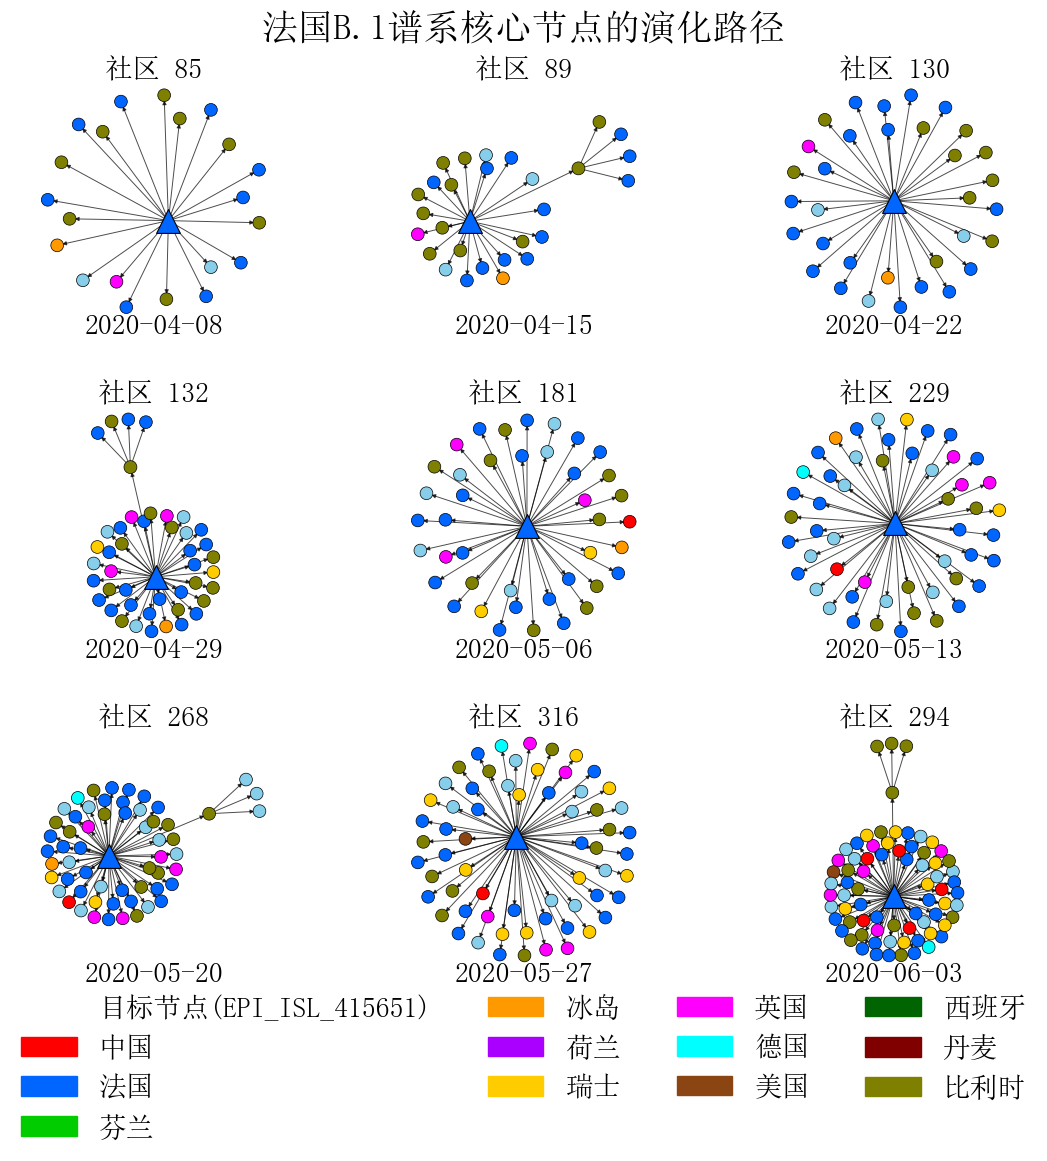

In [ ]:
import matplotlib.colors
import matplotlib.lines as mlines  # 为图例中的三角形标记

def _evaluate_layout_spread(coords):
    """评估布局的空间利用效率
    
    计算节点分布的均匀性，值越小表示分布越均匀
    """
    if len(coords) <= 1:
        return 0
        
    # 计算中心点
    center = np.mean(coords, axis=0)
    
    # 计算到中心的距离
    dists = np.array([np.linalg.norm(coord - center) for coord in coords])
    
    # 计算距离的标准差与均值的比值 (变异系数)
    cv = np.std(dists) / (np.mean(dists) + 1e-10)
    
    # 计算角度分布的均匀性
    angles = np.arctan2(coords[:, 1] - center[1], coords[:, 0] - center[0])
    hist, _ = np.histogram(angles, bins=8, range=(-np.pi, np.pi))
    angle_cv = np.std(hist) / (np.mean(hist) + 1e-10)
    
    # 综合评分 (均匀性越好，分数越低)
    return cv + angle_cv * 1.5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.font_manager as font_manager  # 添加字体管理器导入
import os
import igraph as ig
from typing import List, Tuple

def visualize_community_chain(
    chain_df: pd.DataFrame,
    partitions: List[List[List[str]]],
    graphs: List[ig.Graph],
    label_of_interest: str,
    tracking_label: str = "Mutations_str", 
    recording_label: str = "Pango",
    color_attr: str = "Location",
    highlight_attrs: List[str] = None,
    attr_mapping: dict = None,  # 添加属性映射字典参数
    figsize: Tuple[int, int] = (10, 10),
    max_cols: int = 4,
    base_node_size: float = 30,
    base_edge_length: float = 0.2,
    edge_separation: float = 0.8,
    save_path: str = None,
    fig_title: str = None,
    save_dpi: int = 300,
    start_date: str = None,
    end_date: str = None,
    other_color: str = "#87CEEB",
    font_path: str = '/home/liujiajun/projects/Hap_networks/TIMES.TTF'  # 添加字体路径参数
):
    """简化版社区演化可视化函数 - 支持自定义字体"""
    print(f"正在可视化社区演化链...")
    
    # 配置自定义字体
    try:
        font_manager.fontManager.addfont(font_path)
        title_prop = font_manager.FontProperties(fname=font_path, weight='bold', size=26)
        community_prop = font_manager.FontProperties(fname=font_path, weight='bold', size=20)
        date_prop = font_manager.FontProperties(fname=font_path, size=20)
        legend_prop = font_manager.FontProperties(fname=font_path, size=20)
        print(f"已加载自定义字体: {font_path}")
    except Exception as e:
        print(f"加载自定义字体错误: {e}。使用默认字体。")
        title_prop = None
        community_prop = None
        date_prop = None
        legend_prop = None
    
    # 定义颜色列表
    colors = [
        '#FF0000',  # 鲜红色
        '#0066FF',  # 亮蓝色
        '#00CC00',  # 亮绿色
        '#FF9900',  # 橙色
        '#AA00FF',  # 紫色
        '#FFCC00',  # 金黄色
        '#FF00FF',  # 洋红色
        '#00FFFF',  # 青色
        '#8B4513',  # 棕色
        '#006400',  # 深绿色
        '#800000',  # 栗色
        '#808000',  # 橄榄色 
        '#4B0082',  # 靛青色
        '#008080',  # 蓝绿色
        '#800080',  # 紫色
        '#000000', # 黑色
    ]
    
    # 日期过滤
    filtered_df = chain_df.copy()
    if start_date is not None or end_date is not None:
        if 'Date' in filtered_df.columns:
            if not pd.api.types.is_datetime64_any_dtype(filtered_df['Date']):
                filtered_df['Date'] = pd.to_datetime(filtered_df['Date'])
                
            if start_date is not None:
                filtered_df = filtered_df[filtered_df['Date'] >= pd.to_datetime(start_date)]
            if end_date is not None:
                filtered_df = filtered_df[filtered_df['Date'] <= pd.to_datetime(end_date)]
            
            filtered_df = filtered_df.reset_index(drop=True)
            if len(filtered_df) == 0:
                print(f"警告: 日期范围 {start_date} 到 {end_date} 内没有找到数据")
                return
            
            print(f"已过滤为 {len(filtered_df)} 个社区")
    
    # 映射日期到图索引
    date_indices = {}
    for idx, g in enumerate(graphs):
        if not g or g.vcount() == 0:
            continue
            
        if g.vs and 'Date' in g.vs.attributes():
            dates = np.array([v['Date'] for v in g.vs if 'Date' in v.attributes() and v['Date']])
            if len(dates) > 0:
                try:
                    valid_dates = pd.to_datetime(np.unique(dates))
                    max_date = max(valid_dates).strftime('%Y-%m-%d')
                    date_indices[max_date] = idx
                except:
                    pass
    
    # 为每个日期分配最近的图索引
    for date_str in filtered_df['Date'].unique():
        if isinstance(date_str, pd.Timestamp):
            date_str_fmt = date_str.strftime('%Y-%m-%d')
        else:
            date_str_fmt = date_str
            
        if date_str_fmt not in date_indices:
            date_obj = pd.to_datetime(date_str_fmt)
            closest_date = min(date_indices.keys(), key=lambda x: abs((date_obj - pd.to_datetime(x)).days))
            date_indices[date_str_fmt] = date_indices[closest_date]
    
    # 优化布局
    num_communities = len(filtered_df)
    aspect_ratio = figsize[0] / figsize[1]
    max_cols = min(max_cols, max(1, int(np.ceil(np.sqrt(num_communities * aspect_ratio)))))
    num_rows = int(np.ceil(num_communities / max_cols))
    
    # 创建子图
    fig = plt.figure(figsize=figsize)
    
    # 创建网格，适当调整间距避免文本重叠
    grid = plt.GridSpec(
        num_rows, max_cols,
        left=0.02, right=0.98, 
        bottom=0.12,  # 增加底部边距为图例留出更多空间
        top=0.92 if fig_title else 0.96,
        wspace=0.10,  # 适当增加水平间距
        hspace=0.30   # 适当增加垂直间距
    )
    
    axes = []
    for i in range(num_rows):
        row_axes = []
        for j in range(max_cols):
            ax = fig.add_subplot(grid[i, j])
            row_axes.append(ax)
        axes.append(row_axes)
    axes = np.array(axes)
    
    # 获取目标序列号
    acc_value = "未知"
    fixed_range = 4  # 固定坐标范围
    uniform_x_range = [-fixed_range, fixed_range]
    uniform_y_range = [-fixed_range, fixed_range]
    
    # 创建颜色映射
    color_mapping = {}
    # 创建反向映射（中文->英文）
    reverse_mapping = {}
    if attr_mapping:
        for eng, chn in attr_mapping.items():
            if chn in highlight_attrs:
                reverse_mapping[chn] = eng
    
    if highlight_attrs:
        for i, attr in enumerate(highlight_attrs):
            color_mapping[attr] = colors[i % len(colors)]
            # 如果有反向映射，也添加英文属性到颜色映射
            if attr in reverse_mapping:
                color_mapping[reverse_mapping[attr]] = colors[i % len(colors)]
    
    # 绘制子图
    for i, (_, row) in enumerate(filtered_df.iterrows()):
        row_idx = i // max_cols
        col_idx = i % max_cols
        ax = axes[row_idx, col_idx]
        ax.clear()
        
        # 获取行信息
        date_str = row['Date']
        if isinstance(date_str, pd.Timestamp):
            date_str = date_str.strftime('%Y-%m-%d')
        community_id = int(row['Community ID'])
        
        # 获取时间索引
        time_idx = date_indices.get(date_str)
        if time_idx is None or time_idx >= len(partitions) or time_idx >= len(graphs):
            ax.text(0.5, 0.5, f"无 {date_str} 的数据", ha='center', fontsize=8)
            ax.axis('off')
            continue
            
        # 绘制社区
        if time_idx < len(partitions) and 0 <= community_id < len(partitions[time_idx]):
            try:
                # 获取社区成员
                community_members = partitions[time_idx][community_id]
                orig_graph = graphs[time_idx]
                
                # 准备子图
                name_to_idx = {v['name']: v.index for v in orig_graph.vs if 'name' in v.attributes()}
                member_indices = [name_to_idx[m] for m in community_members if m in name_to_idx]
                
                if not member_indices:
                    ax.text(0.5, 0.5, "未找到节点", ha='center', fontsize=8)
                    ax.axis('off')
                    continue
                
                # 创建子图
                subgraph = orig_graph.subgraph(member_indices)
                print(f"{date_str}，社区 {community_id} 的子图：{subgraph.vcount()} 个节点, {subgraph.ecount()} 条边")
                
                if subgraph.vcount() == 0:
                    ax.text(0.5, 0.5, "空子图", ha='center', fontsize=8)
                    ax.axis('off')
                    continue
                
                # 获取目标信息
                if acc_value == "未知":
                    all_acc_values = []
                    
                    # 收集所有目标节点的ID值
                    for v in orig_graph.vs:
                        try:
                            # 先检查tracking_label在属性中
                            if tracking_label not in v.attributes():
                                continue
                            
                            track_val = v[tracking_label]
                            is_target = False
                            
                            # 安全地检查节点是否是目标节点
                            if isinstance(track_val, str) and track_val == label_of_interest:
                                is_target = True
                            elif isinstance(track_val, (list, tuple)) and label_of_interest in track_val:
                                is_target = True
                            elif isinstance(track_val, np.ndarray):
                                for item in track_val:
                                    if str(item) == str(label_of_interest):
                                        is_target = True
                                        break
                            else:
                                # 尝试字符串比较
                                try:
                                    if str(track_val) == str(label_of_interest):
                                        is_target = True
                                except:
                                    pass
                            
                            # 只有在确认是目标节点后再处理ID
                            if is_target and 'ID' in v.attributes() and v['ID'] is not None:
                                id_val = v['ID']
                                
                                # 安全地处理ID值，可能是数组
                                if isinstance(id_val, (list, tuple, np.ndarray)):
                                    # 打印调试信息
                                    print(f"发现数组ID: {id_val}, 类型: {type(id_val)}")
                                    # 将所有数组元素作为字符串添加
                                    for item in id_val:
                                        all_acc_values.append(str(item))
                                else:
                                    # 单个值直接添加
                                    all_acc_values.append(str(id_val))
                        except Exception as e:
                            print(f"处理节点ID时出错: {e}")
                            continue
                    
                    # 如果找到了ID值，选择最小的
                    if all_acc_values:
                        # 打印收集到的所有ID值以便调试
                        print(f"收集到的ID: {all_acc_values}")
                        # 尝试数值排序，失败则按字符串排序
                        try:
                            min_acc = str(min([float(a) for a in all_acc_values if a.replace('.', '', 1).isdigit()]))
                        except:
                            min_acc = min(all_acc_values)
                            
                        acc_value = min_acc
                        print(f"已从 {len(all_acc_values)} 个值中选择最小ID值: {acc_value}")
                
                # 节点大小计算
                vertex_sizes = []
                if 'wdks' in subgraph.vs.attributes():
                    wdks_values = [v['wdks'] if 'wdks' in v.attributes() else 0.0 for v in subgraph.vs]
                    if wdks_values and max(wdks_values) > min(wdks_values):
                        min_wdks = min(wdks_values)
                        max_wdks = max(wdks_values)
                        vertex_sizes = [base_node_size * (0.2 + 4** ((w - min_wdks) / (max_wdks - min_wdks))) for w in wdks_values]
                    else:
                        vertex_sizes = [base_node_size] * subgraph.vcount()
                else:
                    vertex_sizes = [base_node_size] * subgraph.vcount()
                
                # 边权重计算 - 简化版
                edge_weights = [base_edge_length + edge_separation * 0.5] * subgraph.ecount()
                if 'evo_weight' in subgraph.es.attributes():
                    weights = [e['evo_weight'] for e in subgraph.es if e['evo_weight'] is not None]
                    if weights and max(weights) > min(weights):
                        min_weight = min(weights)
                        max_weight = max(weights)
                        edge_weights = [base_edge_length + (1 - ((w - min_weight) / (max_weight - min_weight))) * edge_separation 
                                        for idx, w in enumerate(weights)]
                
                # 目标节点识别
                # 目标节点识别部分
                target_nodes = set()
                for v in subgraph.vs:
                    try:
                        if tracking_label not in v.attributes():
                            continue
                            
                        track_val = v[tracking_label]
                        found_match = False
                        
                        # 字符串直接比较
                        if isinstance(track_val, str):
                            if track_val == label_of_interest:
                                found_match = True
                        
                        # 处理列表类型
                        elif isinstance(track_val, (list, tuple)):
                            for item in track_val:
                                if str(item) == str(label_of_interest):
                                    found_match = True
                                    break
                        
                        # 处理numpy数组 - 逐元素比较
                        elif isinstance(track_val, np.ndarray):
                            for item in track_val:
                                if str(item) == str(label_of_interest):
                                    found_match = True
                                    break
                        
                        # 尝试字符串转换比较
                        else:
                            try:
                                if str(track_val) == str(label_of_interest):
                                    found_match = True
                            except:
                                pass
                        
                        if found_match:
                            target_nodes.add(v['name'])
                            
                    except Exception as e:
                        print(f"目标节点检测错误: {e}")
                        continue
                
                # 节点颜色设置
                vertex_colors = []
                target_node_indices = []
                
                for idx, v in enumerate(subgraph.vs):
                    # 记录目标节点
                    if v['name'] in target_nodes:
                        target_node_indices.append(idx)
                    
                    # 节点颜色
                    attr_val = "未知"
                    if color_attr and color_attr in v.attributes() and v[color_attr] is not None:
                        attr_val = str(v[color_attr])
                    
                    # 添加调试信息
                    if idx < 5:  # 只打印前5个节点的信息，避免输出过多
                        print(f"节点{idx} 属性值: {attr_val}")
                    
                    # 首先检查原始属性值是否在映射中
                    if attr_val in color_mapping:
                        vertex_colors.append(color_mapping[attr_val])
                    # 如果有映射字典，检查映射后的值是否在颜色映射中
                    elif attr_mapping and attr_val in attr_mapping and attr_mapping[attr_val] in color_mapping:
                        vertex_colors.append(color_mapping[attr_mapping[attr_val]])
                    else:
                        vertex_colors.append(other_color)
                
                # 计算布局 - 简化版
                try:
                    # 使用圆形布局作为种子，确保360度分布
                    init_layout = subgraph.layout_circle()
                    
                    # FR布局优化
                    layout = subgraph.layout_fruchterman_reingold(
                        weights=edge_weights,
                        niter=1000,
                        seed=init_layout,
                        start_temp=2.0
                    )
                    coords = np.array(layout.coords)
                    
                    # 确保节点不会太靠近
                    center = np.mean(coords, axis=0)
                    for i in range(len(coords)):
                        vec = coords[i] - center
                        dist = np.linalg.norm(vec)
                        if dist < 0.001:
                            vec = np.random.rand(2) - 0.5
                            dist = np.linalg.norm(vec)
                        
                        # 适当向外推动节点
                        if dist < 0.5:
                            push = (0.5 - dist) / 0.5
                            coords[i] = coords[i] + vec * push
                except Exception as e:
                    print(f"布局失败，使用圆形布局: {e}")
                    layout = subgraph.layout_circle()
                    coords = np.array(layout.coords)
                
                # 绘制节点和边
                if coords.size > 0:
                    # 设置坐标范围
                    ax.set_xlim(uniform_x_range)
                    ax.set_ylim(uniform_y_range)
                    
                    # 缩放坐标 - 确保不超出范围
                    if len(coords) > 1:
                        min_x, max_x = np.min(coords[:, 0]), np.max(coords[:, 0])
                        min_y, max_y = np.min(coords[:, 1]), np.max(coords[:, 1])
                        
                        # 计算中心和范围
                        x_center = (min_x + max_x) / 2
                        y_center = (min_y + max_y) / 2
                        x_range = max(0.001, max_x - min_x)
                        y_range = max(0.001, max_y - min_y)
                        
                        # 计算缩放因子，确保充分利用空间
                        scale_factor = min(
                            (uniform_x_range[1] - uniform_x_range[0]) / x_range * 0.85,
                            (uniform_y_range[1] - uniform_y_range[0]) / y_range * 0.85
                        )
                        
                        # 缩放并居中
                        coords[:, 0] = (coords[:, 0] - x_center) * scale_factor
                        coords[:, 1] = (coords[:, 1] - y_center) * scale_factor
                    
                    # 绘制边 - 先绘制以确保在节点下方
                    if subgraph.ecount() > 0:
                        for e in subgraph.es:
                            source_idx, target_idx = e.source, e.target
                            if 0 <= source_idx < len(coords) and 0 <= target_idx < len(coords):
                                # 限制边的长度
                                src_coords = coords[source_idx]
                                tgt_coords = coords[target_idx]
                                edge_length = np.linalg.norm(tgt_coords - src_coords)
                                
                                # 如果边太长，缩短它
                                if edge_length > 5.0:
                                    direction = (tgt_coords - src_coords) / edge_length
                                    mid_point = (src_coords + tgt_coords) / 2
                                    src_coords = mid_point - direction * 2.0
                                    tgt_coords = mid_point + direction * 2.0
                                
                                # 计算节点半径以避免边与节点重叠
                                src_radius = np.sqrt(vertex_sizes[source_idx]) * 0.04
                                tgt_radius = np.sqrt(vertex_sizes[target_idx]) * 0.04
                                
                                # 绘制边
                                ax.annotate('',
                                            xy=(tgt_coords[0], tgt_coords[1]),
                                            xytext=(src_coords[0], src_coords[1]),
                                            arrowprops=dict(
                                                arrowstyle='-|>',
                                                linewidth=0.7,
                                                color='black',
                                                alpha=0.7,
                                                shrinkA=src_radius * 5,
                                                shrinkB=tgt_radius * 10,
                                                mutation_scale=6,
                                                zorder=1
                                            ),
                                            zorder=1)
                    
                    # 创建目标节点和非目标节点的掩码
                    # 绘制节点部分
                    target_x, target_y, target_sizes, target_colors = [], [], [], []
                    non_target_x, non_target_y, non_target_sizes, non_target_colors = [], [], [], []

                    try:
                        # 明确地构建绘图数据
                        for idx, v in enumerate(subgraph.vs):
                            if idx < len(coords):  # 确保索引有效
                                is_target_node = v['name'] in target_nodes
                                
                                if is_target_node:
                                    target_x.append(coords[idx][0])
                                    target_y.append(coords[idx][1])
                                    # 处理大小和颜色索引边界
                                    size = vertex_sizes[idx] if idx < len(vertex_sizes) else base_node_size
                                    color = vertex_colors[idx] if idx < len(vertex_colors) else other_color
                                    target_sizes.append(size)
                                    target_colors.append(color)
                                else:
                                    non_target_x.append(coords[idx][0])
                                    non_target_y.append(coords[idx][1])
                                    # 处理大小和颜色索引边界
                                    size = vertex_sizes[idx] if idx < len(vertex_sizes) else base_node_size
                                    color = vertex_colors[idx] if idx < len(vertex_colors) else other_color
                                    non_target_sizes.append(size)
                                    non_target_colors.append(color)
                        
                        # 绘制非目标节点(圆形)
                        if non_target_x:
                            ax.scatter(
                                non_target_x, non_target_y, 
                                s=non_target_sizes,
                                c=non_target_colors,
                                marker='o',
                                edgecolor='black', 
                                linewidth=0.5,
                                zorder=2
                            )
                        
                        # 绘制目标节点(三角形)
                        if target_x:
                            ax.scatter(
                                target_x, target_y, 
                                s=target_sizes,
                                c=target_colors,
                                marker='^',
                                edgecolor='black',
                                linewidth=0.8,
                                zorder=3
                            )
                    except Exception as e:
                        print(f"绘制节点错误: {e}")
                        import traceback
                        traceback.print_exc()  # 打印完整堆栈以便调试
                        ax.text(0.5, 0.5, "节点绘制错误", ha='center', transform=ax.transAxes)
                
            except Exception as e:
                print(f"处理 {date_str} 上的社区 {community_id} 时出错: {str(e)}")
                ax.text(0.5, 0.5, "错误", ha='center', fontsize=8)
        else:
            ax.text(0.5, 0.1, f"未找到社区 {community_id}", ha='center', fontsize=8)
            ax.axis('off')
        

        # 添加标题和日期 - 使用自定义字体
        ax.text(0.5, 0.98, f"社区 {community_id}", 
                transform=ax.transAxes, 
                ha='center', va='bottom', 
                fontproperties=community_prop)  # 使用自定义字体属性
                
        ax.text(0.5, 0.05, date_str, 
                transform=ax.transAxes, 
                ha='center', va='top', 
                fontproperties=date_prop)  # 使用自定义字体属性
        ax.set_aspect('equal')
        ax.axis('off')
    
    # 隐藏未使用的子图
    for i in range(num_communities, num_rows * max_cols):
        row_idx, col_idx = i // max_cols, i % max_cols
        if row_idx < len(axes) and col_idx < len(axes[0]):
            axes[row_idx, col_idx].axis('off')
    
    # 准备图例
    legend_elements = []
    
    # 添加目标节点到图例
    target_marker = mlines.Line2D(
        [0], [0],
        marker='',
        color='white',
        markerfacecolor='gray',
        markersize=12,
        markeredgecolor='black',
        linestyle='',
        label=f'目标节点({acc_value})'
    )
    legend_elements.append(target_marker)
    
    # 添加属性颜色到图例
    if highlight_attrs:
        for attr in highlight_attrs:
            if attr in color_mapping:
                legend_elements.append(mpatches.Patch(
                    color=color_mapping[attr],
                    label=attr
                ))
    
    # 图例布局 - 使用自定义字体
    ncols = min(5, max(2, len(legend_elements) // 2 + 1))
    fig.legend(
        handles=legend_elements, 
        loc='lower center', 
        ncol=ncols-1,
        prop=legend_prop,  # 使用自定义字体属性
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )
    
    # 主标题也使用自定义字体
    plt.suptitle(fig_title, y=0.98, fontproperties=title_prop)
    
    plt.savefig(save_path, dpi=save_dpi, bbox_inches='tight', pad_inches=0.2)
    print(f"图形已保存至: {save_path}")
    
    plt.show()
    plt.close(fig)

import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

# 使用自定义字体的可视化函数
# 创建英文到中文的映射字典
location_mapping = {
    'China': '中国',
    'France': '法国',
    'Finland': '芬兰',
    'Iceland': '冰岛',
    'Netherlands': '荷兰',
    'Switzerland': '瑞士',
    'United Kingdom': '英国',
    'Germany': '德国',
    'United States': '美国',
    'Spain': '西班牙',
    'Denmark': '丹麦',
    'Belgium': '比利时'
}

# 使用自定义字体的可视化函数
visualize_community_chain(
    chain_df=tracking_chains_fran3[0],
    partitions=communities,
    graphs=graphs,
    label_of_interest='3037(SNP:C->T);14408(SNP:C->T);15324(SNP:C->T);23403(SNP:A->G)',
    tracking_label='name',
    recording_label='Lineage',
    color_attr='Location',
    highlight_attrs=['中国', '法国', '芬兰', '冰岛', '荷兰', '瑞士', '英国', '德国', '美国',
                     '西班牙', '丹麦', '比利时'],
    attr_mapping=location_mapping,  # 添加映射字典
    figsize=(7.48*1.5, 7.48*1.5),
    max_cols=4,
    base_node_size=70,
    base_edge_length=80,
    edge_separation=0.005,
    fig_title='法国B.1谱系核心节点的演化路径',
    save_path="演化路径_04-08-06-03.tiff",
    save_dpi=500,
    start_date='2020-04-08',
    end_date='2020-06-03',
    font_path='/home/liujiajun/projects/Hap_networks/songti.ttf'
)
